## Configuration and Reset Utilities - RQ1
This cell sets up the project paths, utility functions for resetting checkpoints, embeddings, and results, and provides a quick start guide for managing the pipeline state. Run this cell before starting any processing to ensure all paths and utilities are initialized.

In [4]:
# =============================================================================
# CONFIGURATION & RESET UTILITIES — ITERATION 4
# =============================================================================
# Cross-platform path resolution (consistent with Iteration 0).
# Uses find_project_root_with_datasets() to locate project root automatically.

import os
import json
import glob
import shutil
from pathlib import Path

def find_project_root_with_datasets(start_path: Path, max_levels: int = 10) -> Path:
    """Search upward from start_path for directory containing 'Datasets' folder."""
    cur = start_path.resolve()
    for _ in range(max_levels):
        if (cur / 'Datasets').exists():
            return cur
        cur = cur.parent
    raise FileNotFoundError(
        f"Could not find project root with 'Datasets' folder within {max_levels} levels. "
        f"Set THESIS_BASE_DIR environment variable or ensure Datasets folder exists."
    )

env_base = os.environ.get('THESIS_BASE_DIR')
if env_base:
    BASE_DIR = Path(env_base)
    print(f"Using THESIS_BASE_DIR from environment: {BASE_DIR}")
else:
    BASE_DIR = find_project_root_with_datasets(Path.cwd())
    print(f"Found project root: {BASE_DIR}")

PATHS = {
    'master_dataset': BASE_DIR / "Master Dataset 34k",
    'embeddings':     BASE_DIR / "Embeddings" / "_iteration_4",
    'results':        BASE_DIR / "Results" / "_iteration_4"
}

for k, p in list(PATHS.items()):
    PATHS[k] = Path(p).resolve()
    PATHS[k].mkdir(parents=True, exist_ok=True)

DATA_DIR = str(PATHS['master_dataset'])
EMBEDDINGS_BASE_DIR = str(PATHS['embeddings'])
RESULTS_DIR = str(PATHS['results'])
CHECKPOINT_FILE = str(PATHS['results'] / "checkpoint_iteration_4.json")  # or "checkpoint.json" for consistency

print(f"BASE_DIR:            {BASE_DIR}")
print(f"DATA_DIR:            {DATA_DIR}")
print(f"EMBEDDINGS_BASE_DIR: {EMBEDDINGS_BASE_DIR}")
print(f"RESULTS_DIR:         {RESULTS_DIR}")
print(f"CHECKPOINT_FILE:     {CHECKPOINT_FILE}")

# Language code mapping (consistent with Iteration 0)
LANGUAGE_CODE_MAP = {
    'English': 'EN', 'German': 'DE', 'Swedish': 'SV',
    'Dutch':   'NL', 'Hungarian': 'HU', 'Unknown': 'UN',
}


def reset_checkpoint():
    """Delete checkpoint to restart from beginning"""
    if os.path.exists(CHECKPOINT_FILE):
        os.remove(CHECKPOINT_FILE)
        print(" Checkpoint cleared - will restart from beginning")
    else:
        print(" No checkpoint found - already clean")

def view_progress():
    """View current progress"""
    if os.path.exists(CHECKPOINT_FILE):
        with open(CHECKPOINT_FILE, 'r') as f:
            data = json.load(f)
            processed = data['processed']
            print(f"\n{'='*60}")
            print(f"ITERATION 4 PROGRESS: {len(processed)} combinations processed")
            print(f"{'='*60}")
            print("\nCompleted:")
            for item in processed:
                if isinstance(item, (list, tuple)) and len(item) >= 2:
                    model, dataset = item[0], item[1]
                    print(f"   {model:45s} → {dataset}")
                else:
                    print(f"   {item}")
    else:
        print(" No checkpoint found - no progress yet")

def reset_embeddings():
    """Delete all generated embeddings for iteration 4"""
    if os.path.exists(EMBEDDINGS_BASE_DIR):
        response = input(f" Delete ALL embeddings in {EMBEDDINGS_BASE_DIR}? (yes/no): ")
        if response.lower() == 'yes':
            shutil.rmtree(EMBEDDINGS_BASE_DIR)
            os.makedirs(EMBEDDINGS_BASE_DIR)
            print(" All iteration 4 embeddings deleted")
        else:
            print(" Cancelled")
    else:
        print(" Embeddings directory doesn't exist")

def reset_results():
    """Delete all results for iteration 4"""
    if os.path.exists(RESULTS_DIR):
        response = input(f" Delete ALL results in {RESULTS_DIR}? (yes/no): ")
        if response.lower() == 'yes':
            for file in glob.glob(os.path.join(RESULTS_DIR, '*')):
                os.remove(file)
            print(" All iteration 4 results deleted")
        else:
            print(" Cancelled")
    else:
        print(" Results directory doesn't exist")

def full_reset():
    """Complete reset - checkpoint, embeddings, and results"""
    print("\n" + "="*60)
    print(" FULL RESET WARNING - ITERATION 4")
    print("="*60)
    response = input("This will delete EVERYTHING (checkpoint, embeddings, results). Continue? (yes/no): ")
    if response.lower() == 'yes':
        reset_checkpoint()
        if os.path.exists(EMBEDDINGS_BASE_DIR):
            shutil.rmtree(EMBEDDINGS_BASE_DIR)
            os.makedirs(EMBEDDINGS_BASE_DIR)
            print(" Embeddings deleted")
        if os.path.exists(RESULTS_DIR):
            for file in glob.glob(os.path.join(RESULTS_DIR, '*')):
                os.remove(file)
            print(" Results deleted")
        print("\n Full reset complete - Ready for fresh start")
    else:
        print(" Cancelled")

def remove_specific_model(model_key):
    """Remove specific model from checkpoint to reprocess it"""
    if os.path.exists(CHECKPOINT_FILE):
        with open(CHECKPOINT_FILE, 'r') as f:
            data = json.load(f)
            processed = data['processed']
        original_count = len(processed)
        processed = [item for item in processed if item[0] != model_key]
        removed_count = original_count - len(processed)
        with open(CHECKPOINT_FILE, 'w') as f:
            json.dump({'processed': processed}, f)
        print(f" Removed {removed_count} combinations for model: {model_key}")
        print(f"Remaining: {len(processed)} combinations")
    else:
        print(" No checkpoint found")

def remove_specific_dataset(dataset_name):
    """Remove specific dataset from checkpoint to reprocess it"""
    if os.path.exists(CHECKPOINT_FILE):
        with open(CHECKPOINT_FILE, 'r') as f:
            data = json.load(f)
            processed = data['processed']
        original_count = len(processed)
        processed = [item for item in processed if item[1] != dataset_name]
        removed_count = original_count - len(processed)
        with open(CHECKPOINT_FILE, 'w') as f:
            json.dump({'processed': processed}, f)
        print(f" Removed {removed_count} combinations for dataset: {dataset_name}")
        print(f"Remaining: {len(processed)} combinations")
    else:
        print(" No checkpoint found")

def complete_rerun():
    """Simple one-command complete restart for iteration 4"""
    print("\n" + "="*60)
    print(" COMPLETE RERUN - ITERATION 4")
    print("="*60)
    print("This will:")
    print("  1. Clear checkpoint file")
    print("  2. Delete all embeddings")
    print("  3. Delete all results")
    print("  4. Start fresh from beginning")
    print("="*60)
    response = input("\nProceed with complete rerun? (yes/no): ")
    if response.lower() == 'yes':
        if os.path.exists(CHECKPOINT_FILE):
            os.remove(CHECKPOINT_FILE)
            print(" Checkpoint cleared")
        if os.path.exists(EMBEDDINGS_BASE_DIR):
            shutil.rmtree(EMBEDDINGS_BASE_DIR)
            os.makedirs(EMBEDDINGS_BASE_DIR)
            print(" Embeddings cleared")
        if os.path.exists(RESULTS_DIR):
            for file in glob.glob(os.path.join(RESULTS_DIR, '*')):
                os.remove(file)
            print(" Results cleared")
        print("\n Ready for complete rerun!")
        print("Run the main processing cell to start fresh.")
    else:
        print(" Cancelled")

# =============================================================================
# QUICK START GUIDE
# =============================================================================
print("""
============================================================
ITERATION 4 - RESET UTILITIES
============================================================
Available functions:
  view_progress()           - See what's been processed
  reset_checkpoint()        - Clear checkpoint to restart
  reset_embeddings()        - Delete all embeddings
  reset_results()           - Delete all results
  full_reset()              - Complete reset (all of above)
  complete_rerun()          - One-command complete restart
  remove_specific_model('model_name')   - Remove specific model
  remove_specific_dataset('dataset')    - Remove specific dataset

Run the next cell to start processing.
============================================================
""")

Found project root: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026
BASE_DIR:            /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026
DATA_DIR:            /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Master Dataset 34k
EMBEDDINGS_BASE_DIR: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_4
RESULTS_DIR:         /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_4
CHECKPOINT_FILE:     /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_4/checkpoint_iteration_4.json

ITERATION 4 - RESET UTILITIES
Available functions:
  view_progress()           - See what's been processed
  reset_checkpoint()        - Clear checkpoint to restart
  reset_embeddings()        - Delete all embeddings
  reset_results()           - Delete all results
  full_reset()              - Complete reset (all of above)
  complete_rerun()          - One-command complete restart
  remove_specific_mode

## (Optional) Complete Rerun Utility
This cell allows you to perform a complete reset of the pipeline, clearing all checkpoints, embeddings, and results. Uncomment and run the code if you want to start the entire iteration from scratch.

In [5]:
#complete_rerun()

## Multi-Model Pipeline Setup
This cell imports all required libraries, sets up advanced configuration for the multi-model pipeline, and defines functions for text preprocessing, embedding generation, checkpointing, and classifier training. Run this cell to initialize the main pipeline logic and supporting utilities.


################################################################################
ITERATION 4: ENHANCED MULTI-MODEL PIPELINE
Advanced Techniques: SMOTE, Mean Pooling, Ensemble Methods, Hyperparameter Tuning
################################################################################

Using paths from Cell 2 (standardized):
   DATA_DIR:            /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Master Dataset 34k
   EMBEDDINGS_BASE_DIR: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_4
   RESULTS_DIR:         /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_4
   CHECKPOINT_FILE:     /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_4/checkpoint_iteration_4.json

 Configuration:
   Pooling Strategy: mean
   Use SMOTE: True
   Hyperparameter Tuning: True
   Ensemble Methods: True
   Models: ['bert-base-multilingual-uncased', 'xlm-roberta-base', 'paraphrase-multilingual-mpnet-base-v2', 

Generating embeddings: 100%|██████████| 1019/1019 [01:08<00:00, 14.85it/s]



Training set: (9779, 768)
Test set: (2445, 768)

 Applying SMOTE for class balancing...
   Strategy: Oversample minority to 70.0% of majority
   Original training size: 9779
   Balanced training size: 15573
   Original class distribution: [9161  618]
   Balanced class distribution: [9161 6412]

 Training set too large (15573 samples)
   Subsampling to 6000 for SVM efficiency...
   Subsampled training set: (6000, 768)

 Applying feature scaling...

Embeddings saved!
Location: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_4/bert-base-multilingual-uncased/swedish_manual_bert-base-multilingual-uncased_embeddings.pkl
Size: 107.54 MB

Checkpoint saved: 3 combinations processed
 Progress: 3/40

Processing: DUTCH_MANUAL
Model: bert-base-multilingual-uncased
Dataset shape: (1990, 36)

Case type distribution:
CASE_TYPE
Safety                              649
Process Safety                      588
Environment                         536
Asset and Reputation da

Generating embeddings: 100%|██████████| 166/166 [00:49<00:00,  3.37it/s]


Training set: (1592, 768)
Test set: (398, 768)

 Applying SMOTE for class balancing...
   Strategy: Oversample minority to 70.0% of majority
   Original training size: 1592
   Balanced training size: 1907
   Original class distribution: [1122  470]
   Balanced class distribution: [1122  785]

 Applying feature scaling...

Embeddings saved!
Location: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_4/bert-base-multilingual-uncased/dutch_manual_bert-base-multilingual-uncased_embeddings.pkl
Size: 18.93 MB

Checkpoint saved: 4 combinations processed
 Progress: 4/40

 PHASE 2: TRAINING CLASSIFIERS - bert-base-multilingual-uncased

################################################################################
 Training Pipeline: ENGLISH_MANUAL
################################################################################
Model: bert-base-multilingual-uncased
Pooling: mean
SMOTE used: True
Feature scaling: True

Training Multiple Classifiers: ENGLISH_MANUA

   Best parameters: {'C': 0.1, 'class_weight': 'balanced', 'max_iter': 10000}
   Best CV score: 0.7781
   Accuracy: 0.7614
   F1 (weighted): 0.7662
   F1 (Process Safety): 0.6318
   ROC AUC: 0.8038
   Training time: 293.74s

────────────────────────────────────────────────────────────
 Random_Forest
────────────────────────────────────────────────────────────
   Accuracy: 0.8017
   F1 (weighted): 0.7879
   F1 (Process Safety): 0.5996
   ROC AUC: 0.8425
   Training time: 1.97s

────────────────────────────────────────────────────────────
 XGBoost
────────────────────────────────────────────────────────────
   Accuracy: 0.8165
   F1 (weighted): 0.8119
   F1 (Process Safety): 0.6679
   ROC AUC: 0.8561
   Training time: 5.28s

────────────────────────────────────────────────────────────
 LightGBM
────────────────────────────────────────────────────────────
   Accuracy: 0.8006
   F1 (weighted): 0.7967
   F1 (Process Safety): 0.6453
   ROC AUC: 0.8466
   Training time: 2.17s

───────────────

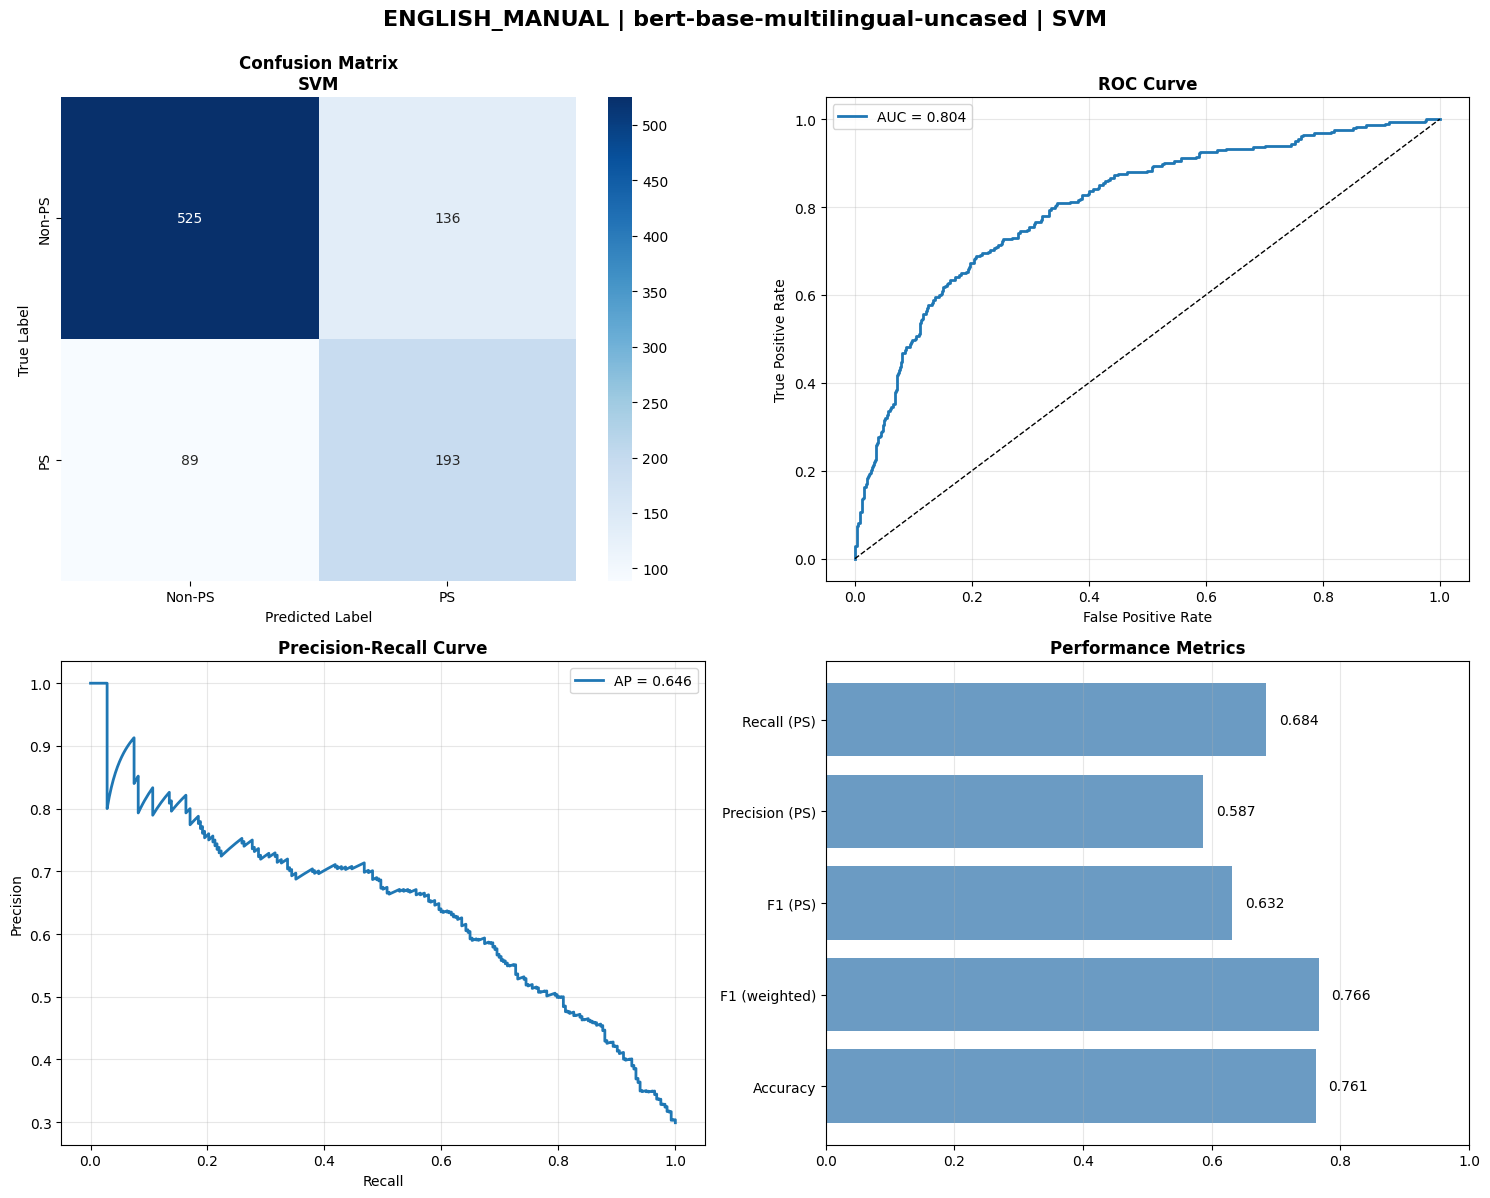


Detailed Report: ENGLISH_MANUAL | bert-base-multilingual-uncased | Random_Forest

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.8127    0.9319    0.8682       661
    Process Safety     0.7568    0.4965    0.5996       282

          accuracy                         0.8017       943
         macro avg     0.7847    0.7142    0.7339       943
      weighted avg     0.7959    0.8017    0.7879       943


 Visualization saved to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_4/eval_english_manual_bert-base-multilingual-uncased_Random_Forest.png


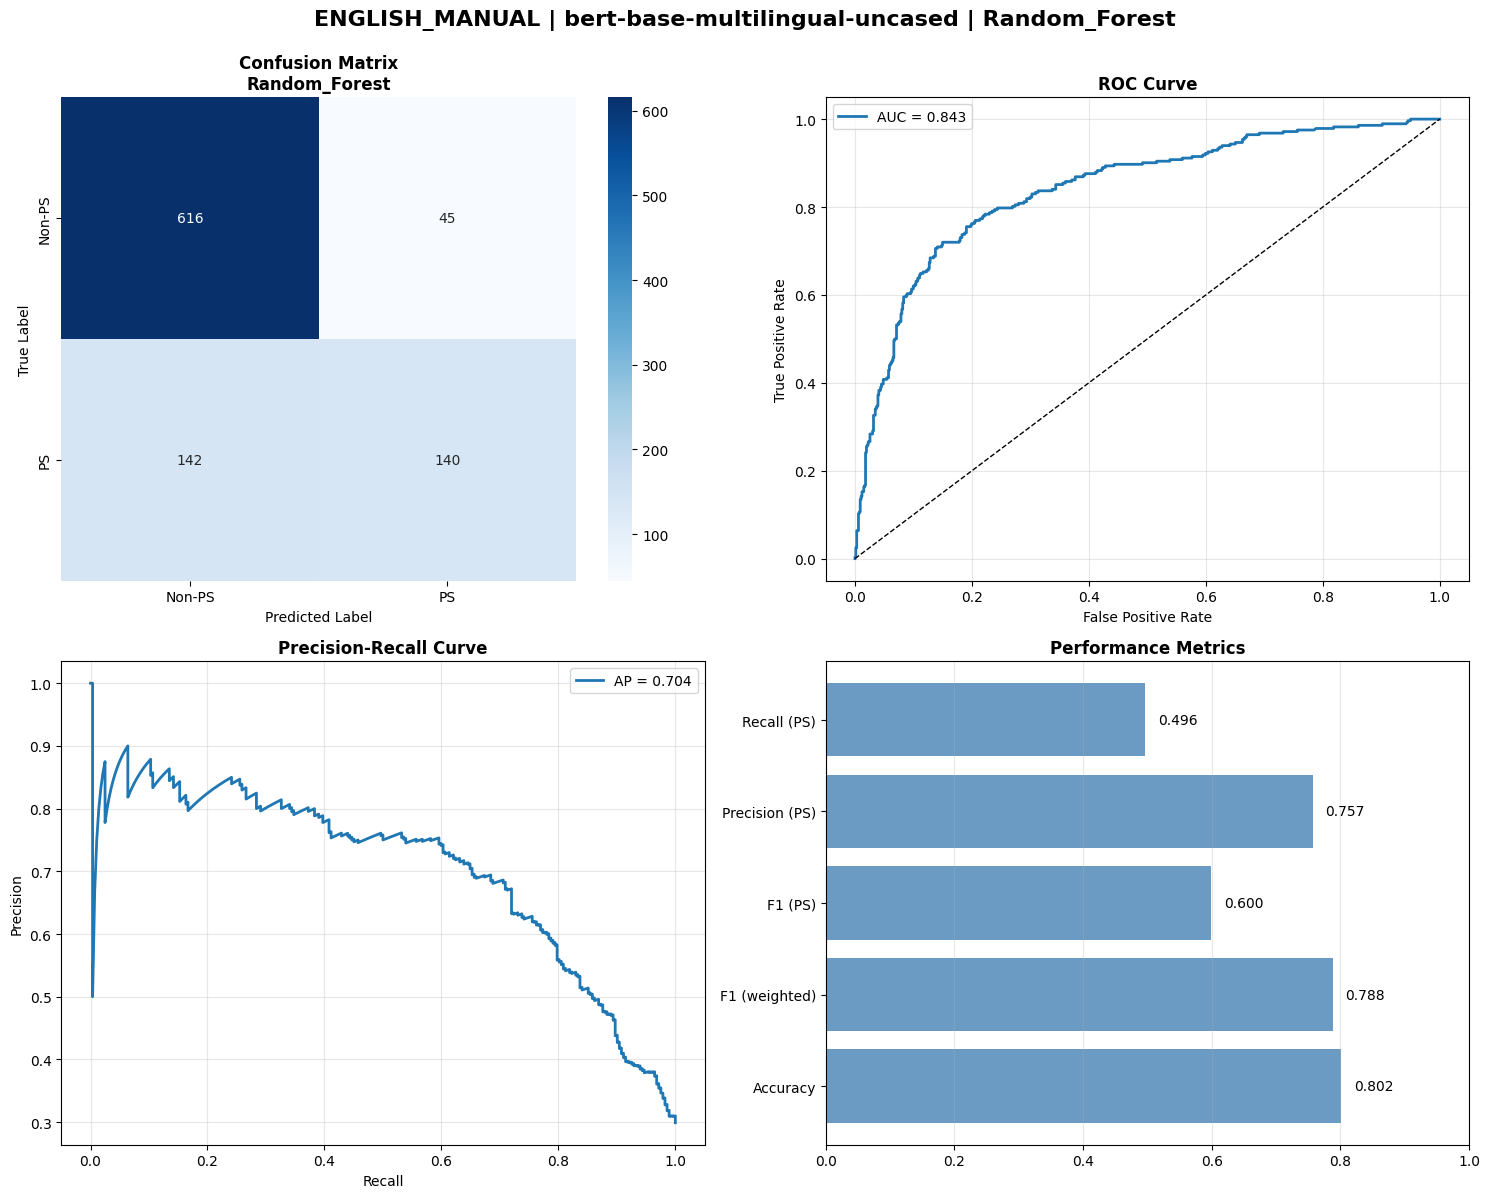


Detailed Report: ENGLISH_MANUAL | bert-base-multilingual-uncased | XGBoost

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.8466    0.9017    0.8733       661
    Process Safety     0.7280    0.6170    0.6679       282

          accuracy                         0.8165       943
         macro avg     0.7873    0.7593    0.7706       943
      weighted avg     0.8111    0.8165    0.8119       943


 Visualization saved to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_4/eval_english_manual_bert-base-multilingual-uncased_XGBoost.png


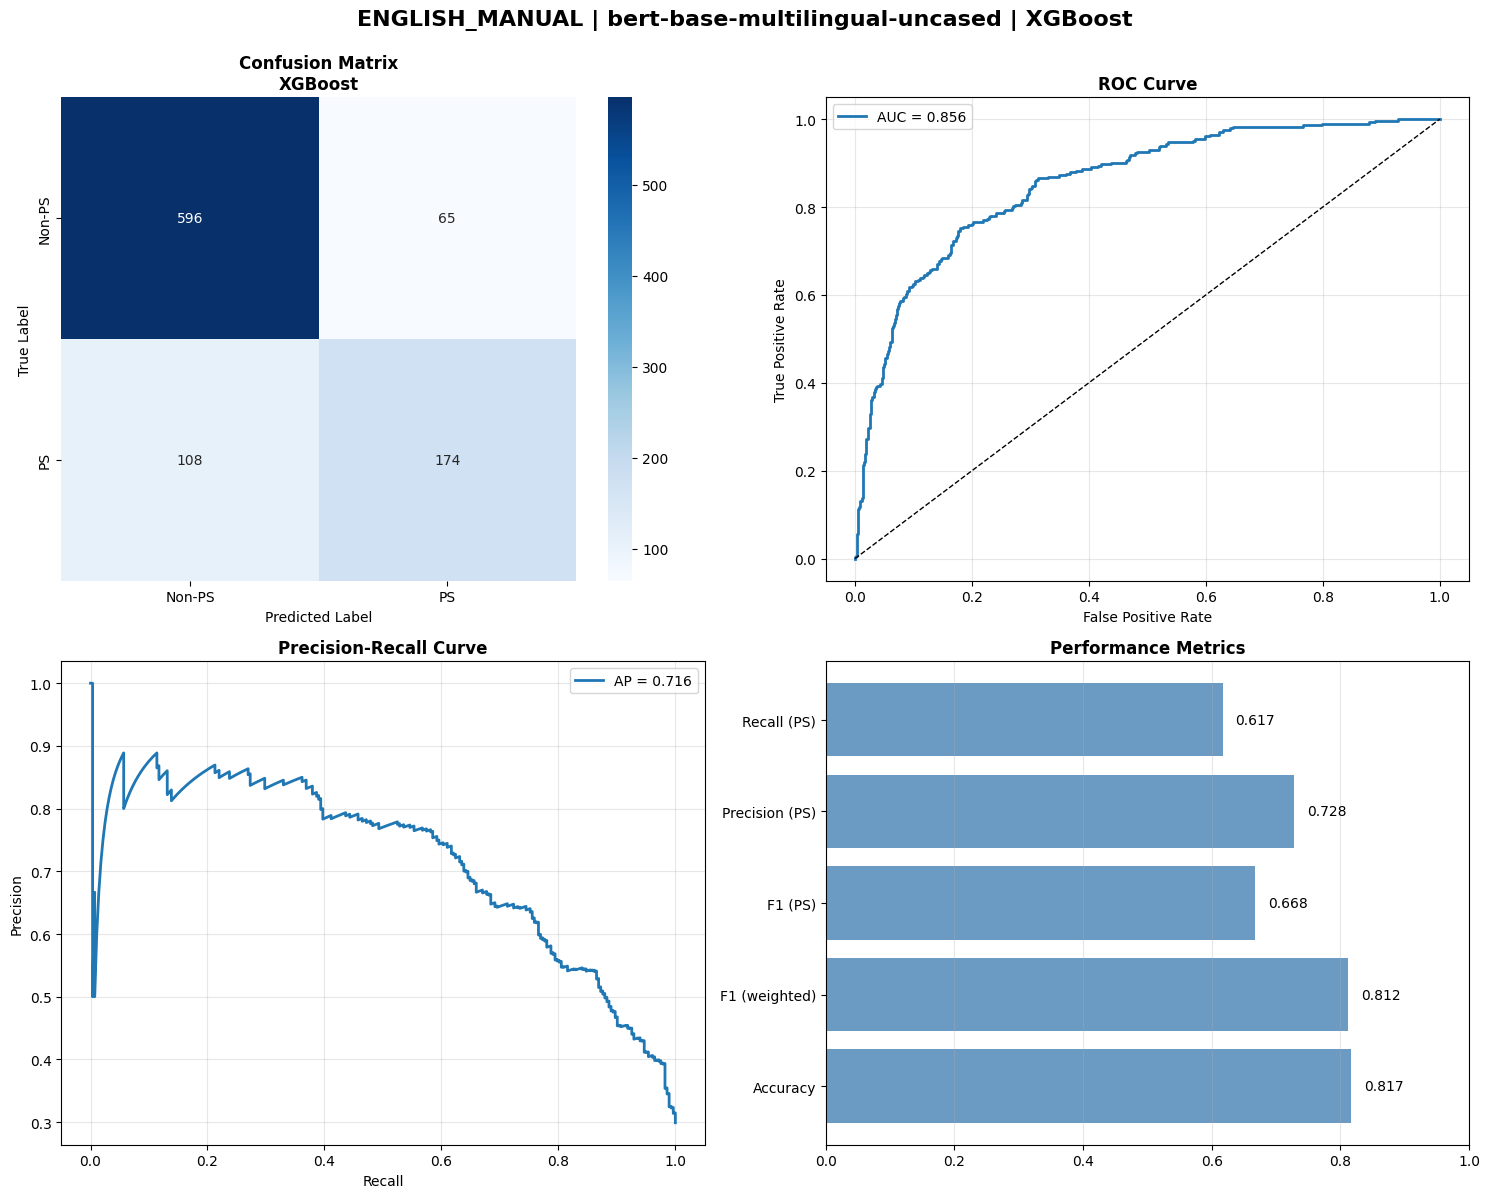


Detailed Report: ENGLISH_MANUAL | bert-base-multilingual-uncased | LightGBM

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.8403    0.8835    0.8614       661
    Process Safety     0.6895    0.6064    0.6453       282

          accuracy                         0.8006       943
         macro avg     0.7649    0.7449    0.7533       943
      weighted avg     0.7952    0.8006    0.7967       943


 Visualization saved to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_4/eval_english_manual_bert-base-multilingual-uncased_LightGBM.png


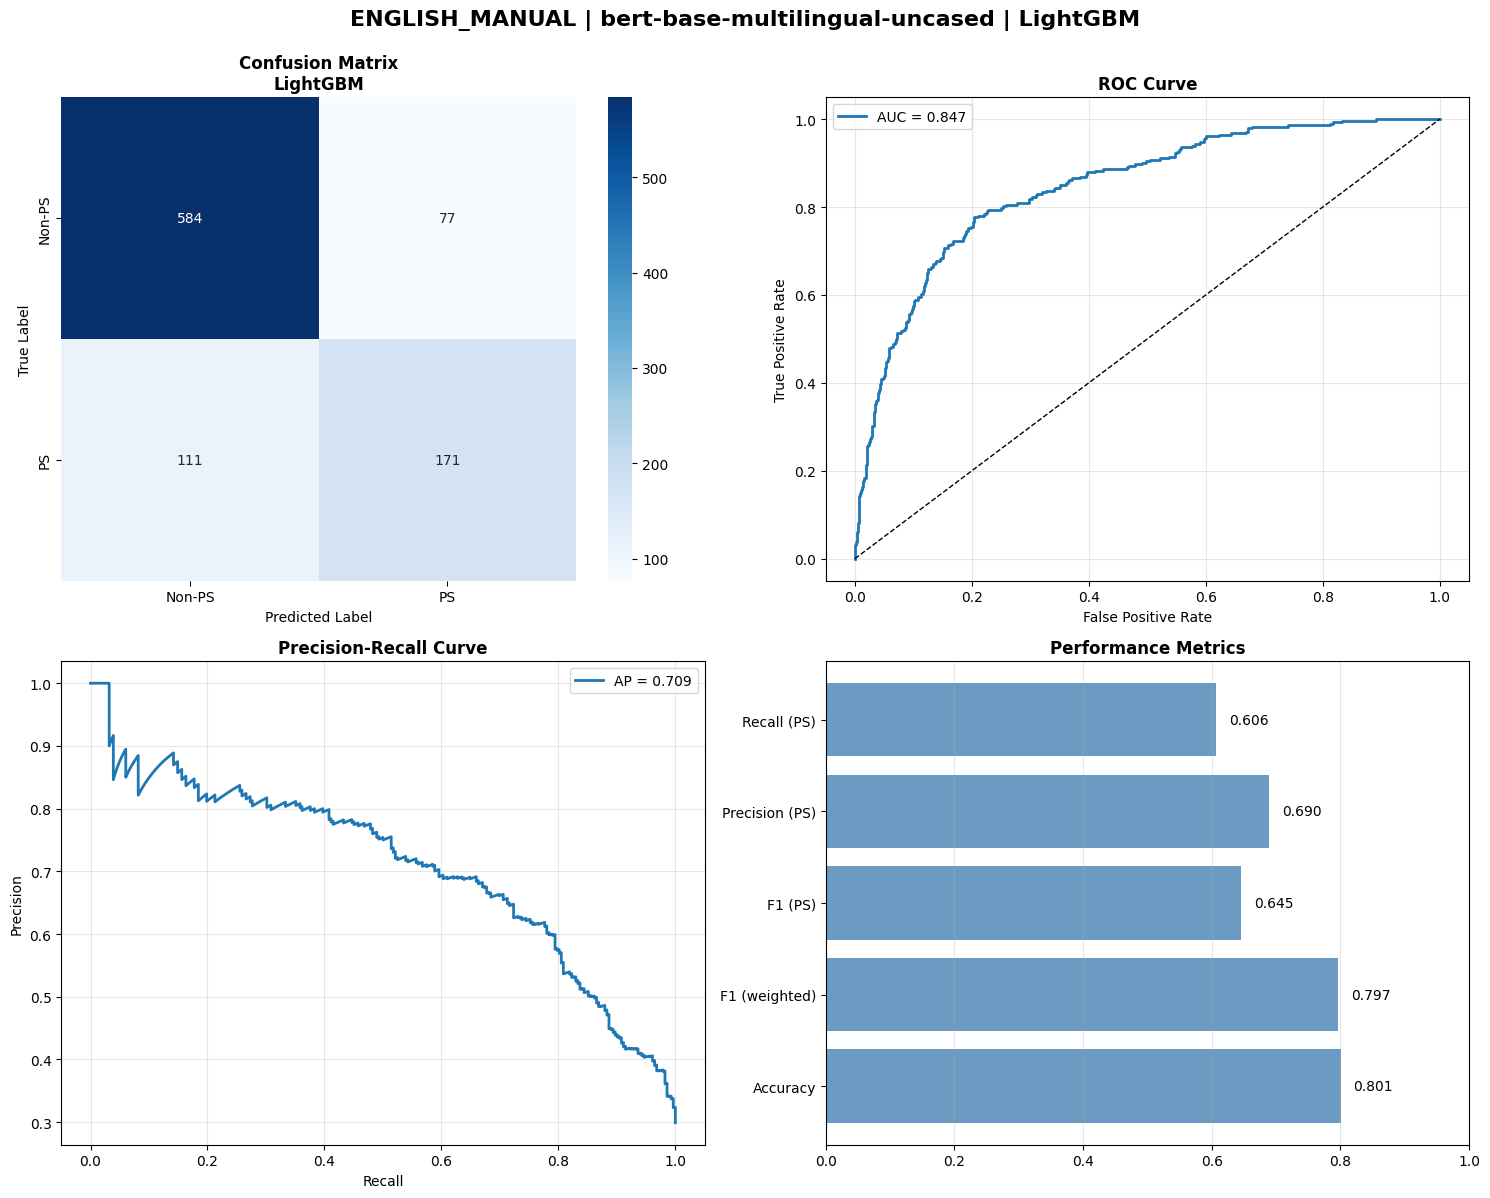


Detailed Report: ENGLISH_MANUAL | bert-base-multilingual-uncased | Voting_Ensemble

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.8441    0.9092    0.8755       661
    Process Safety     0.7403    0.6064    0.6667       282

          accuracy                         0.8187       943
         macro avg     0.7922    0.7578    0.7711       943
      weighted avg     0.8130    0.8187    0.8130       943


 Visualization saved to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_4/eval_english_manual_bert-base-multilingual-uncased_Voting_Ensemble.png


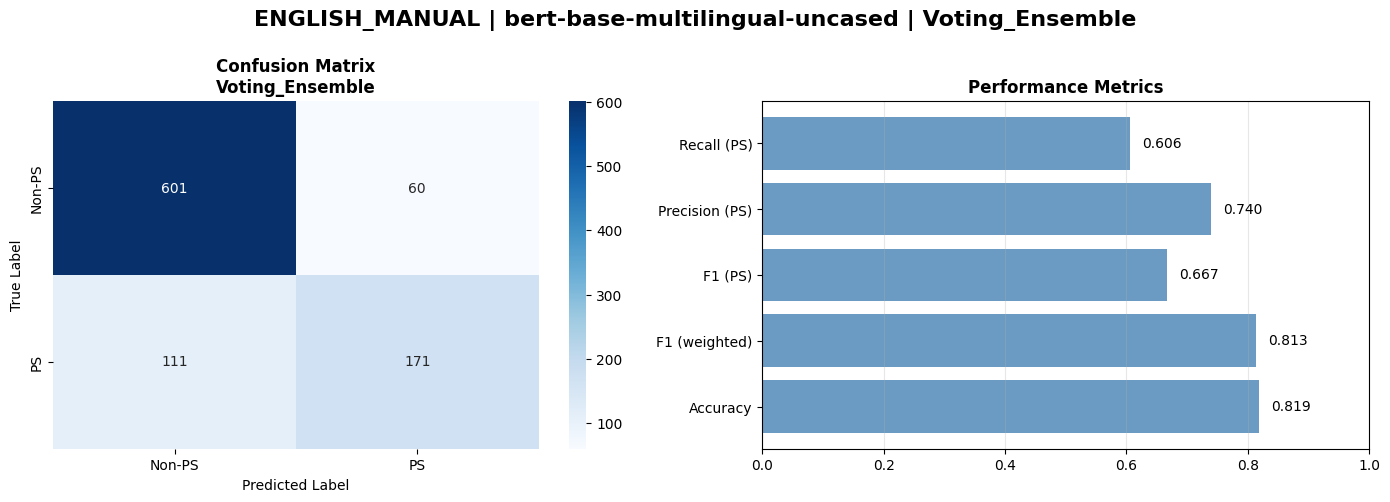


################################################################################
 Training Pipeline: GERMAN_MANUAL
################################################################################
Model: bert-base-multilingual-uncased
Pooling: mean
SMOTE used: True
Feature scaling: True

Training Multiple Classifiers: GERMAN_MANUAL
Training samples: 6000
Test samples: 2991
Features: 768

 Training SVM with hyperparameter tuning...

 Training Random Forest...

 Training XGBoost...

 Training LightGBM...

────────────────────────────────────────────────────────────
 SVM
────────────────────────────────────────────────────────────
   Best parameters: {'C': 0.1, 'class_weight': 'balanced', 'max_iter': 10000}
   Best CV score: 0.8207
   Accuracy: 0.7817
   F1 (weighted): 0.8144
   F1 (Process Safety): 0.3948
   ROC AUC: 0.7998
   Training time: 18.75s

────────────────────────────────────────────────────────────
 Random_Forest
────────────────────────────────────────────────────────────
   

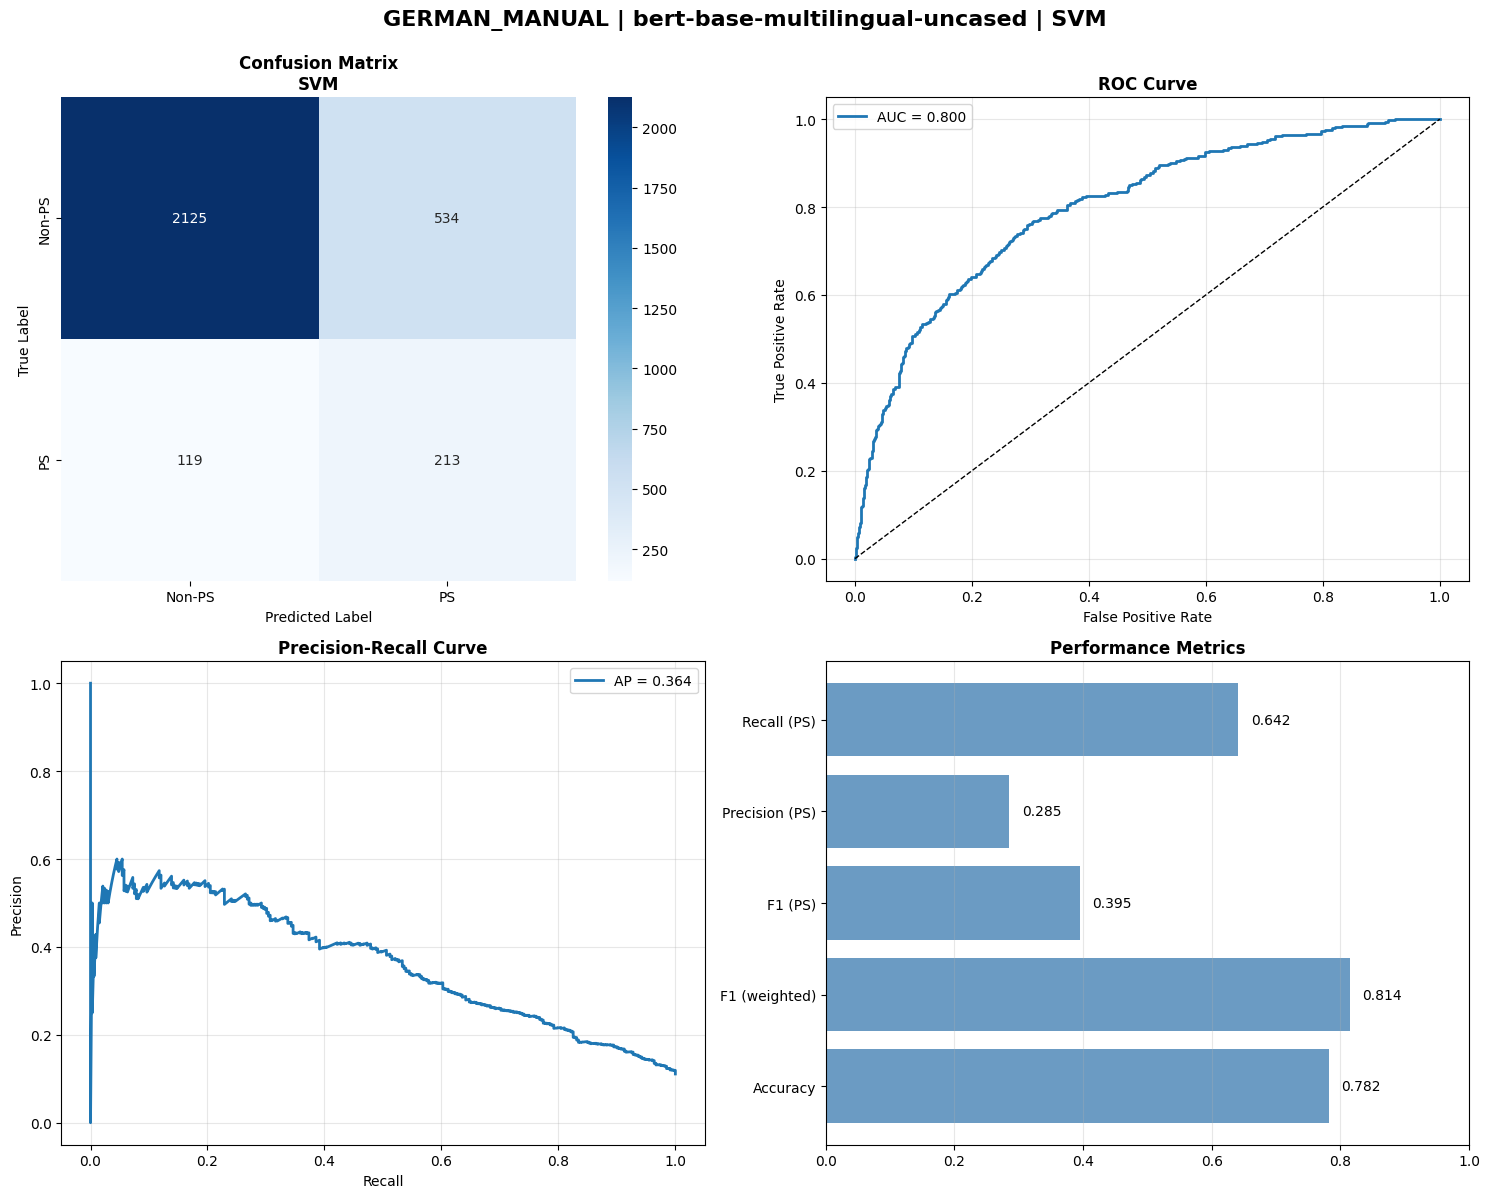


Detailed Report: GERMAN_MANUAL | bert-base-multilingual-uncased | Random_Forest

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.9280    0.9458    0.9369      2659
    Process Safety     0.4875    0.4127    0.4470       332

          accuracy                         0.8867      2991
         macro avg     0.7078    0.6792    0.6919      2991
      weighted avg     0.8791    0.8867    0.8825      2991


 Visualization saved to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_4/eval_german_manual_bert-base-multilingual-uncased_Random_Forest.png


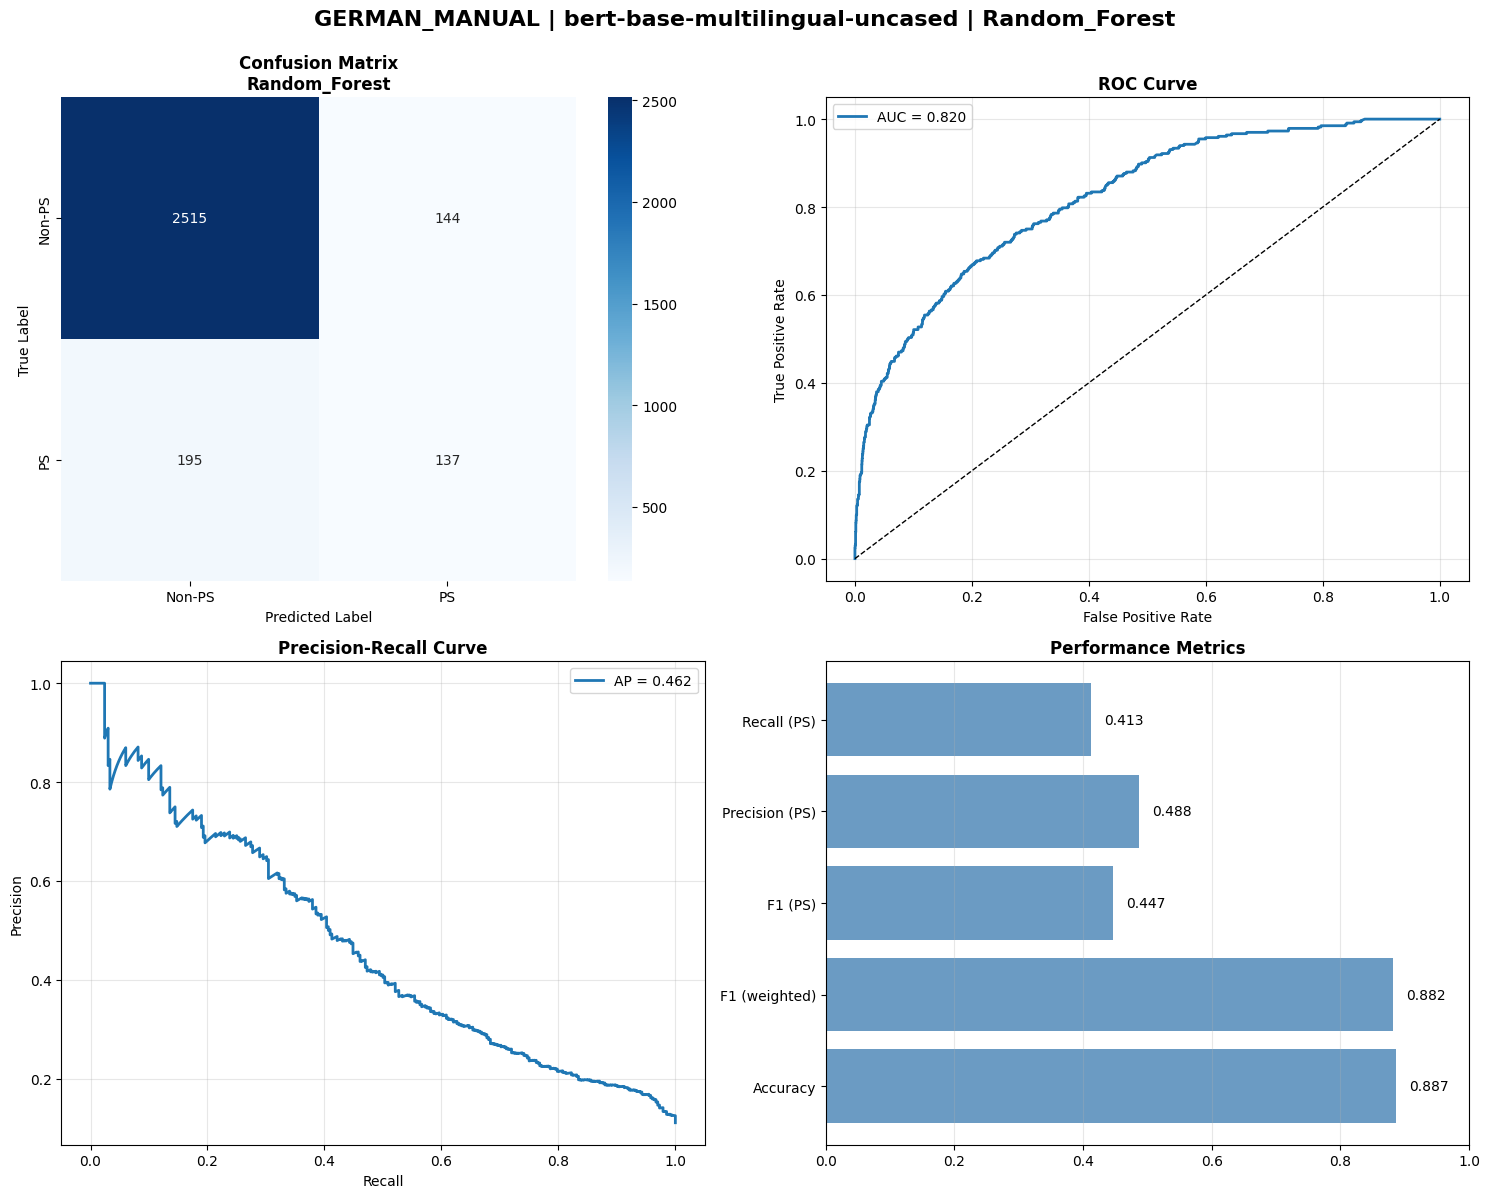


Detailed Report: GERMAN_MANUAL | bert-base-multilingual-uncased | XGBoost

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.9388    0.9180    0.9283      2659
    Process Safety     0.4425    0.5211    0.4786       332

          accuracy                         0.8740      2991
         macro avg     0.6907    0.7195    0.7034      2991
      weighted avg     0.8837    0.8740    0.8784      2991


 Visualization saved to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_4/eval_german_manual_bert-base-multilingual-uncased_XGBoost.png


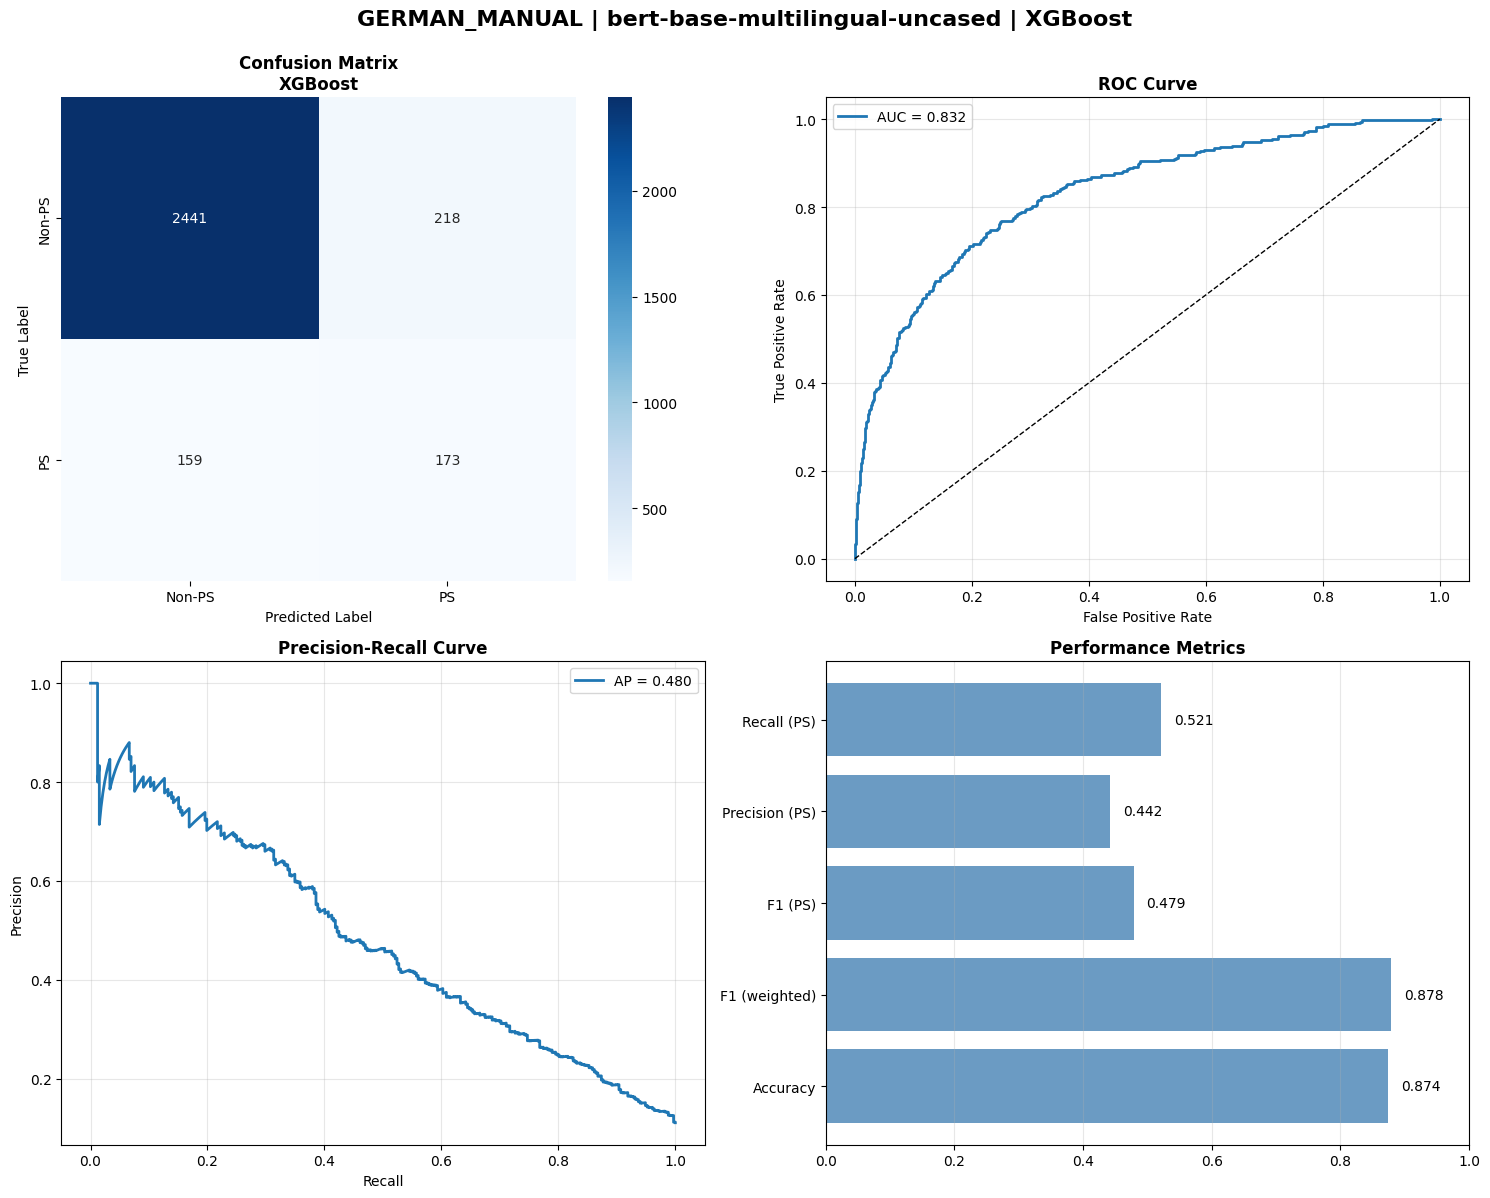


Detailed Report: GERMAN_MANUAL | bert-base-multilingual-uncased | LightGBM

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.9351    0.9259    0.9305      2659
    Process Safety     0.4497    0.4849    0.4667       332

          accuracy                         0.8770      2991
         macro avg     0.6924    0.7054    0.6986      2991
      weighted avg     0.8812    0.8770    0.8790      2991


 Visualization saved to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_4/eval_german_manual_bert-base-multilingual-uncased_LightGBM.png


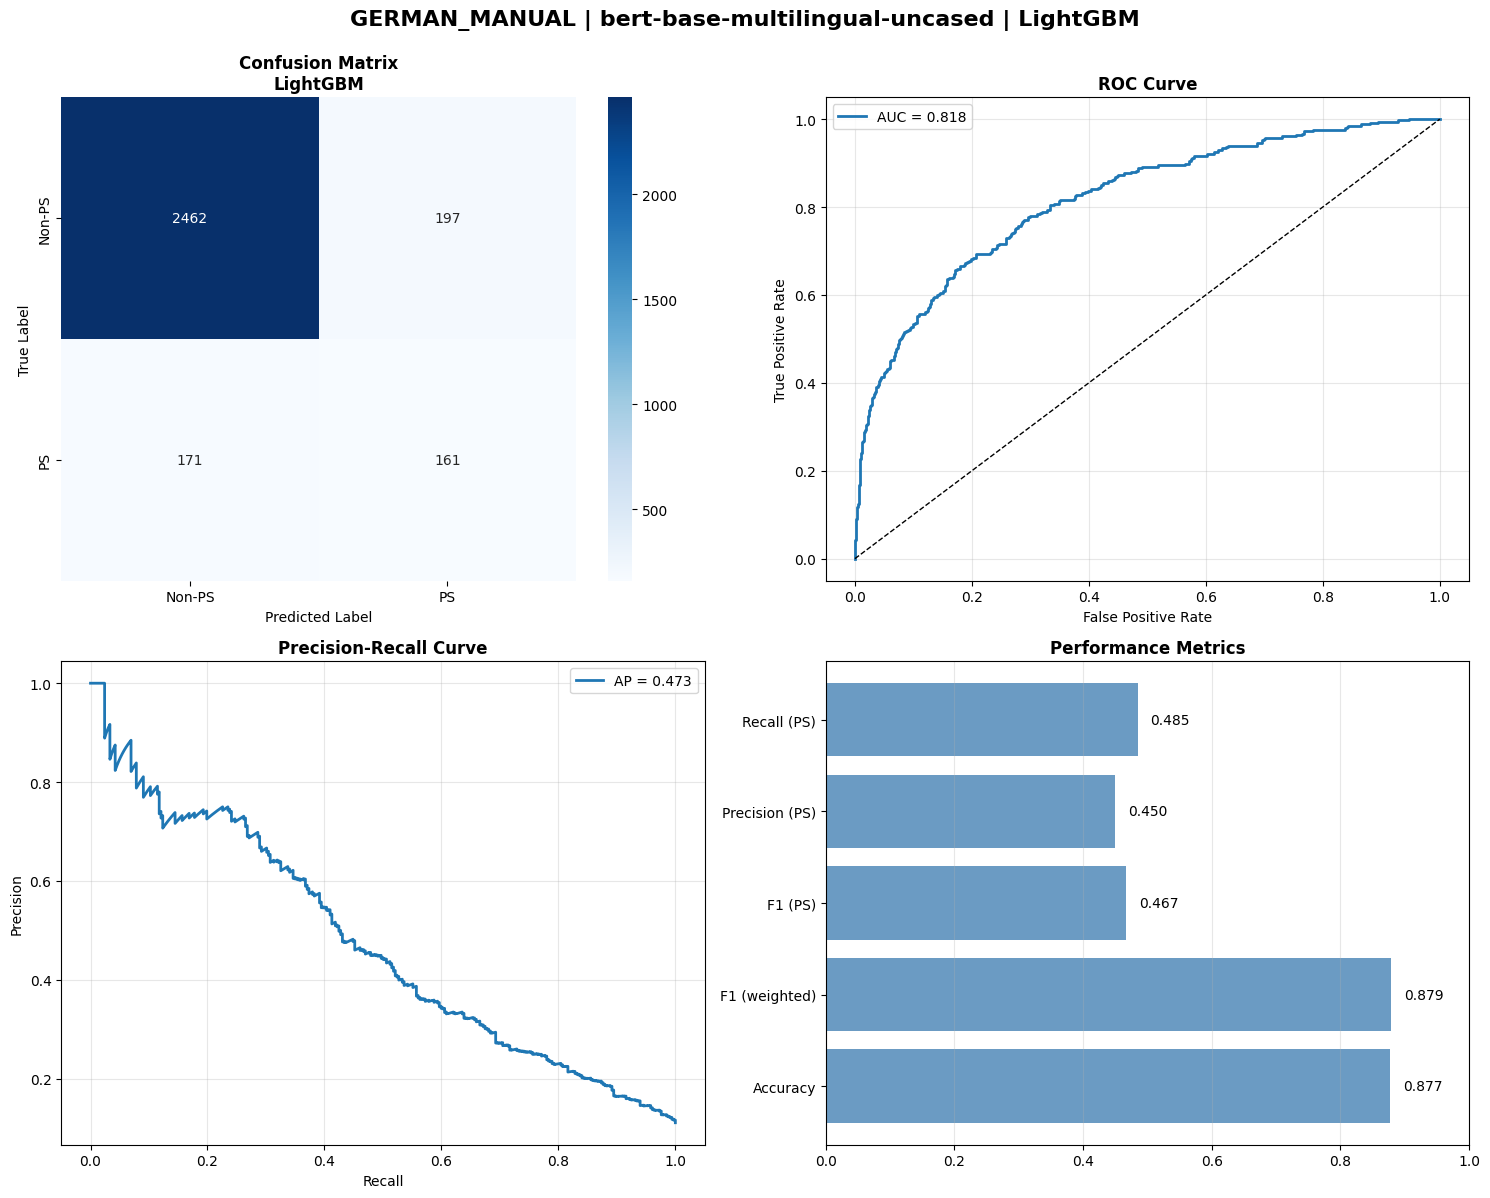


Detailed Report: GERMAN_MANUAL | bert-base-multilingual-uncased | Voting_Ensemble

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.9346    0.9297    0.9321      2659
    Process Safety     0.4595    0.4789    0.4690       332

          accuracy                         0.8796      2991
         macro avg     0.6971    0.7043    0.7006      2991
      weighted avg     0.8819    0.8796    0.8807      2991


 Visualization saved to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_4/eval_german_manual_bert-base-multilingual-uncased_Voting_Ensemble.png


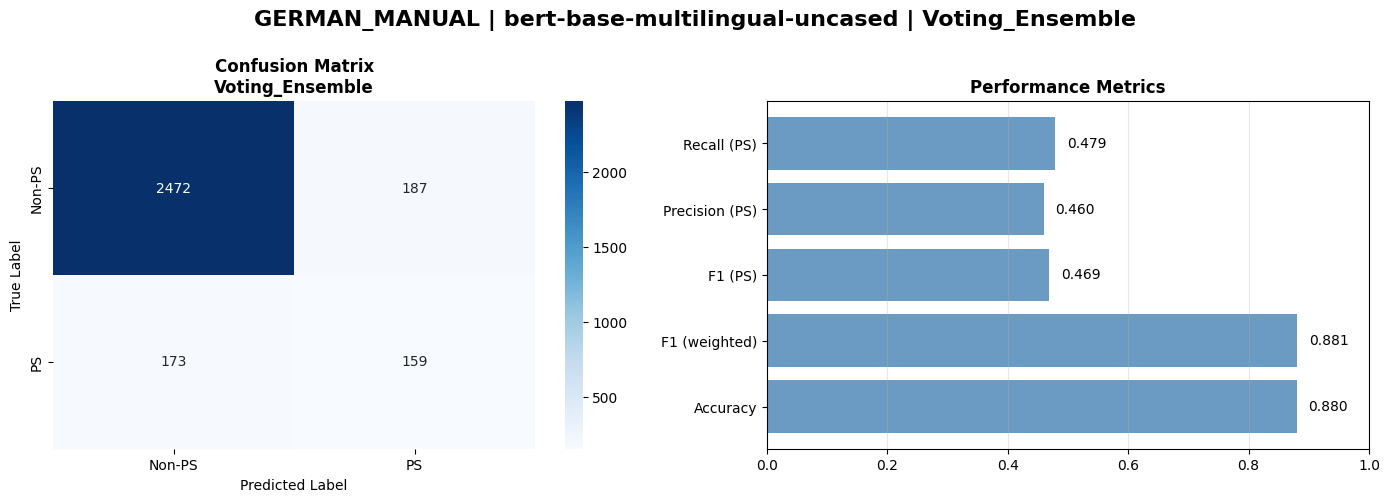


################################################################################
 Training Pipeline: SWEDISH_MANUAL
################################################################################
Model: bert-base-multilingual-uncased
Pooling: mean
SMOTE used: True
Feature scaling: True

Training Multiple Classifiers: SWEDISH_MANUAL
Training samples: 6000
Test samples: 2445
Features: 768

 Training SVM with hyperparameter tuning...

 Training Random Forest...

 Training XGBoost...

 Training LightGBM...

────────────────────────────────────────────────────────────
 SVM
────────────────────────────────────────────────────────────
   Best parameters: {'C': 0.1, 'class_weight': {0: 1, 1: 2}, 'max_iter': 10000}
   Best CV score: 0.8634
   Accuracy: 0.7697
   F1 (weighted): 0.8240
   F1 (Process Safety): 0.2191
   ROC AUC: 0.7165
   Training time: 487.35s

────────────────────────────────────────────────────────────
 Random_Forest
───────────────────────────────────────────────────────────

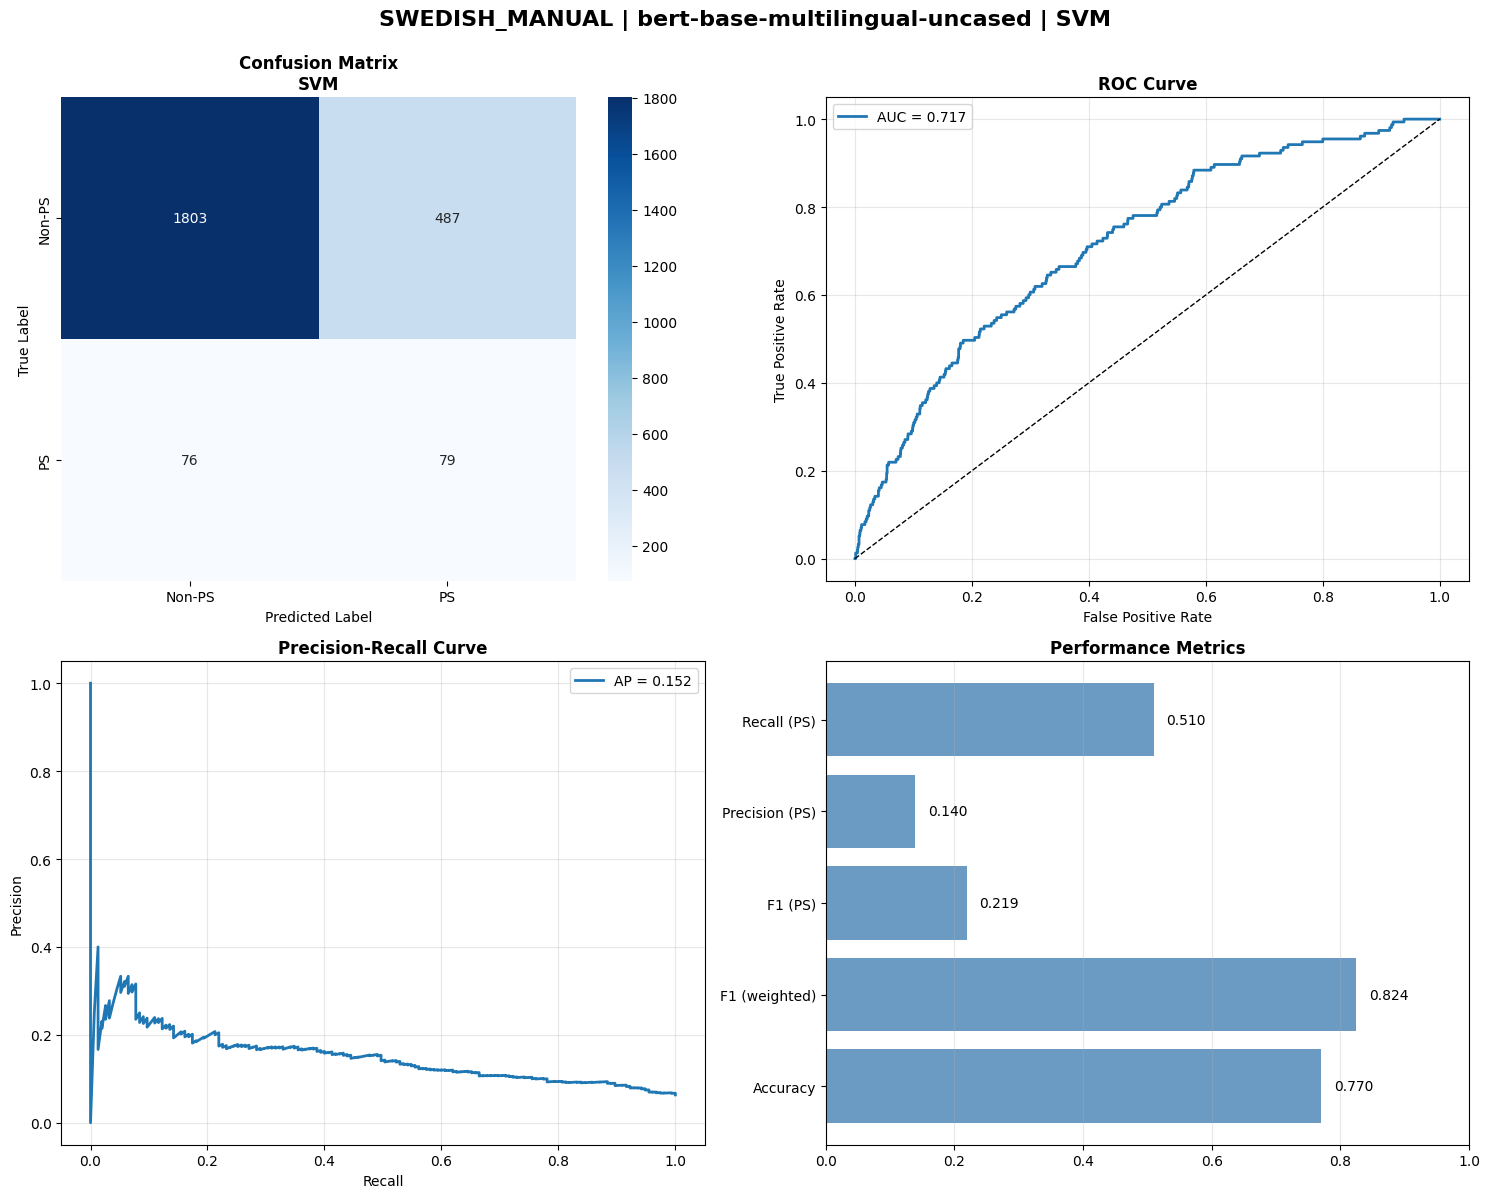


Detailed Report: SWEDISH_MANUAL | bert-base-multilingual-uncased | Random_Forest

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.9468    0.9559    0.9513      2290
    Process Safety     0.2406    0.2065    0.2222       155

          accuracy                         0.9084      2445
         macro avg     0.5937    0.5812    0.5868      2445
      weighted avg     0.9020    0.9084    0.9051      2445


 Visualization saved to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_4/eval_swedish_manual_bert-base-multilingual-uncased_Random_Forest.png


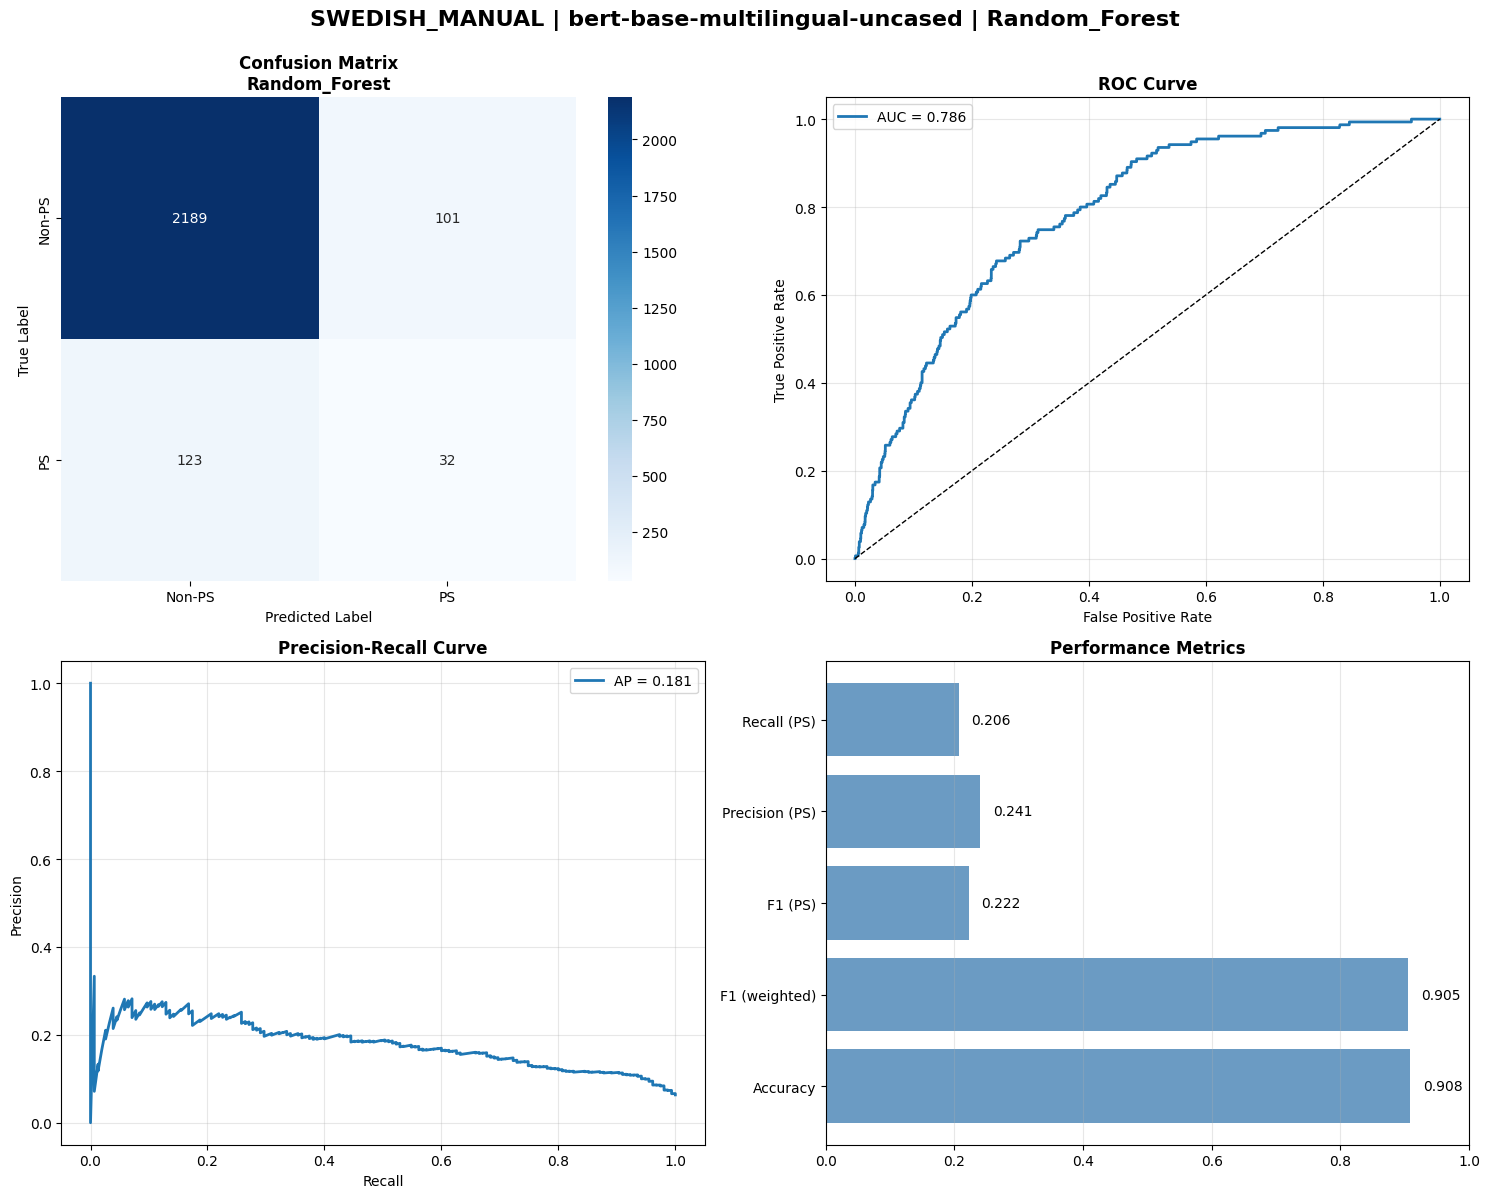


Detailed Report: SWEDISH_MANUAL | bert-base-multilingual-uncased | XGBoost

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.9526    0.9384    0.9454      2290
    Process Safety     0.2540    0.3097    0.2791       155

          accuracy                         0.8986      2445
         macro avg     0.6033    0.6241    0.6123      2445
      weighted avg     0.9083    0.8986    0.9032      2445


 Visualization saved to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_4/eval_swedish_manual_bert-base-multilingual-uncased_XGBoost.png


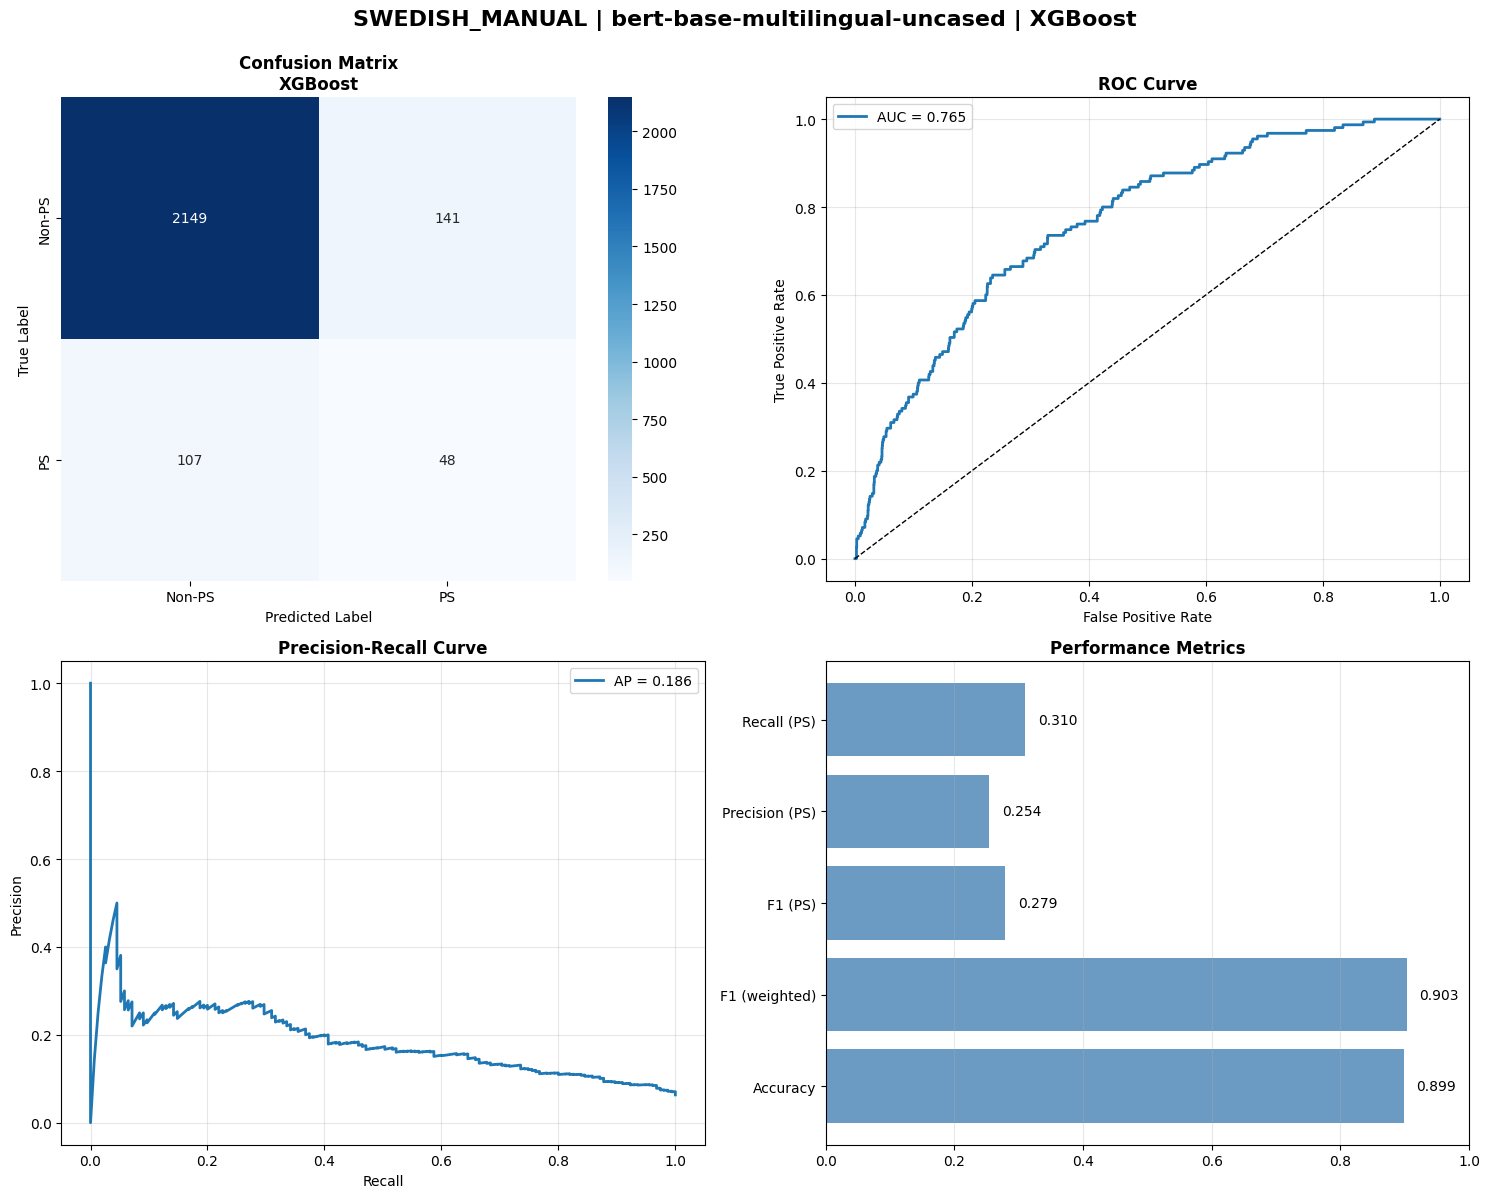


Detailed Report: SWEDISH_MANUAL | bert-base-multilingual-uncased | LightGBM

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.9499    0.9358    0.9428      2290
    Process Safety     0.2222    0.2710    0.2442       155

          accuracy                         0.8937      2445
         macro avg     0.5861    0.6034    0.5935      2445
      weighted avg     0.9038    0.8937    0.8985      2445


 Visualization saved to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_4/eval_swedish_manual_bert-base-multilingual-uncased_LightGBM.png


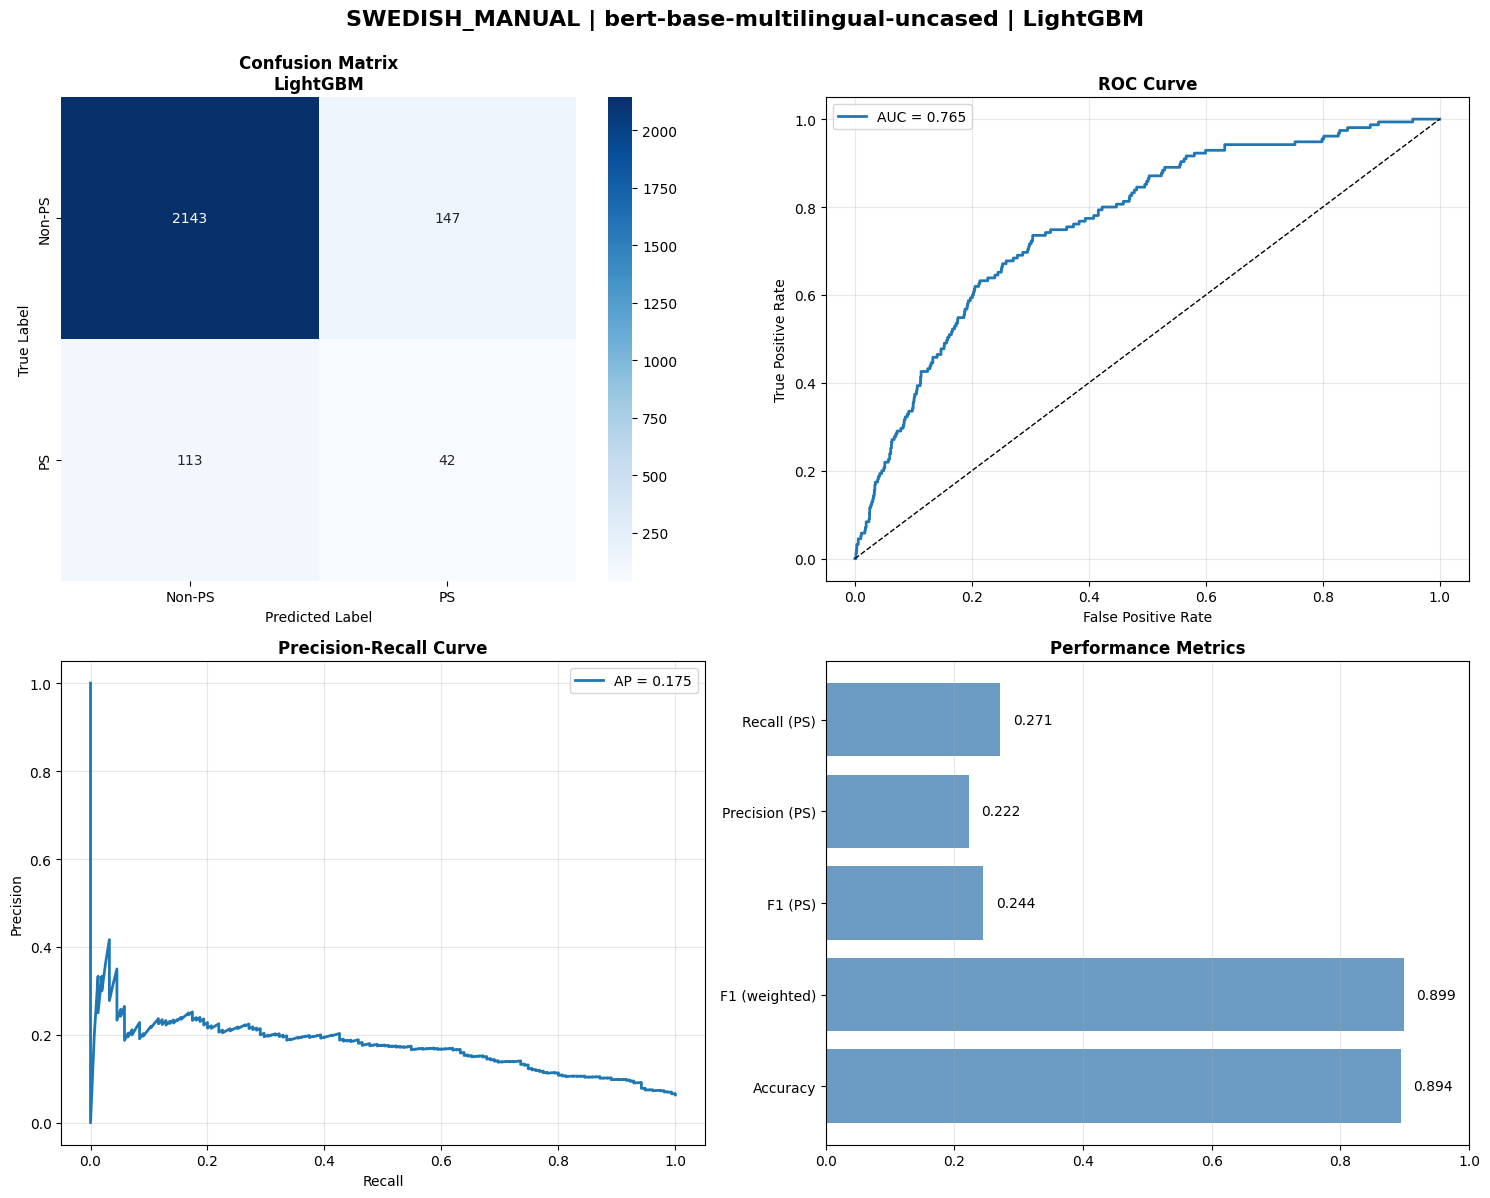


Detailed Report: SWEDISH_MANUAL | bert-base-multilingual-uncased | Voting_Ensemble

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.9504    0.9454    0.9479      2290
    Process Safety     0.2515    0.2710    0.2609       155

          accuracy                         0.9027      2445
         macro avg     0.6009    0.6082    0.6044      2445
      weighted avg     0.9061    0.9027    0.9043      2445


 Visualization saved to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_4/eval_swedish_manual_bert-base-multilingual-uncased_Voting_Ensemble.png


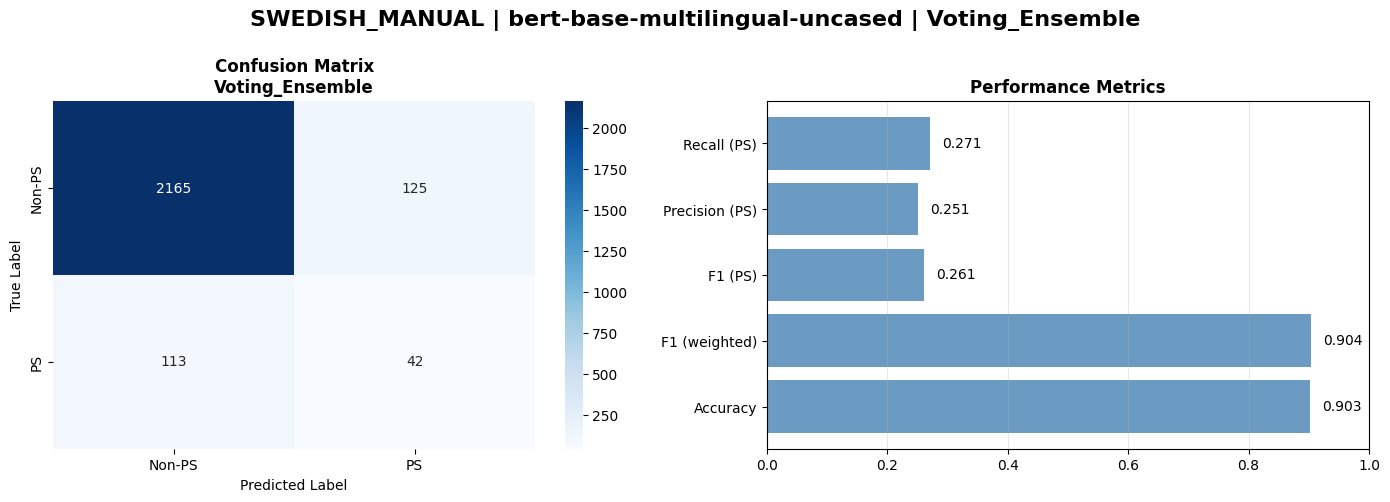


################################################################################
 Training Pipeline: DUTCH_MANUAL
################################################################################
Model: bert-base-multilingual-uncased
Pooling: mean
SMOTE used: True
Feature scaling: True

Training Multiple Classifiers: DUTCH_MANUAL
Training samples: 1907
Test samples: 398
Features: 768

 Training SVM with hyperparameter tuning...

 Training Random Forest...

 Training XGBoost...

 Training LightGBM...

────────────────────────────────────────────────────────────
 SVM
────────────────────────────────────────────────────────────
   Best parameters: {'C': 0.1, 'class_weight': 'balanced', 'max_iter': 10000}
   Best CV score: 0.7665
   Accuracy: 0.6935
   F1 (weighted): 0.6981
   F1 (Process Safety): 0.5120
   ROC AUC: 0.7053
   Training time: 14.39s

────────────────────────────────────────────────────────────
 Random_Forest
────────────────────────────────────────────────────────────
   Acc

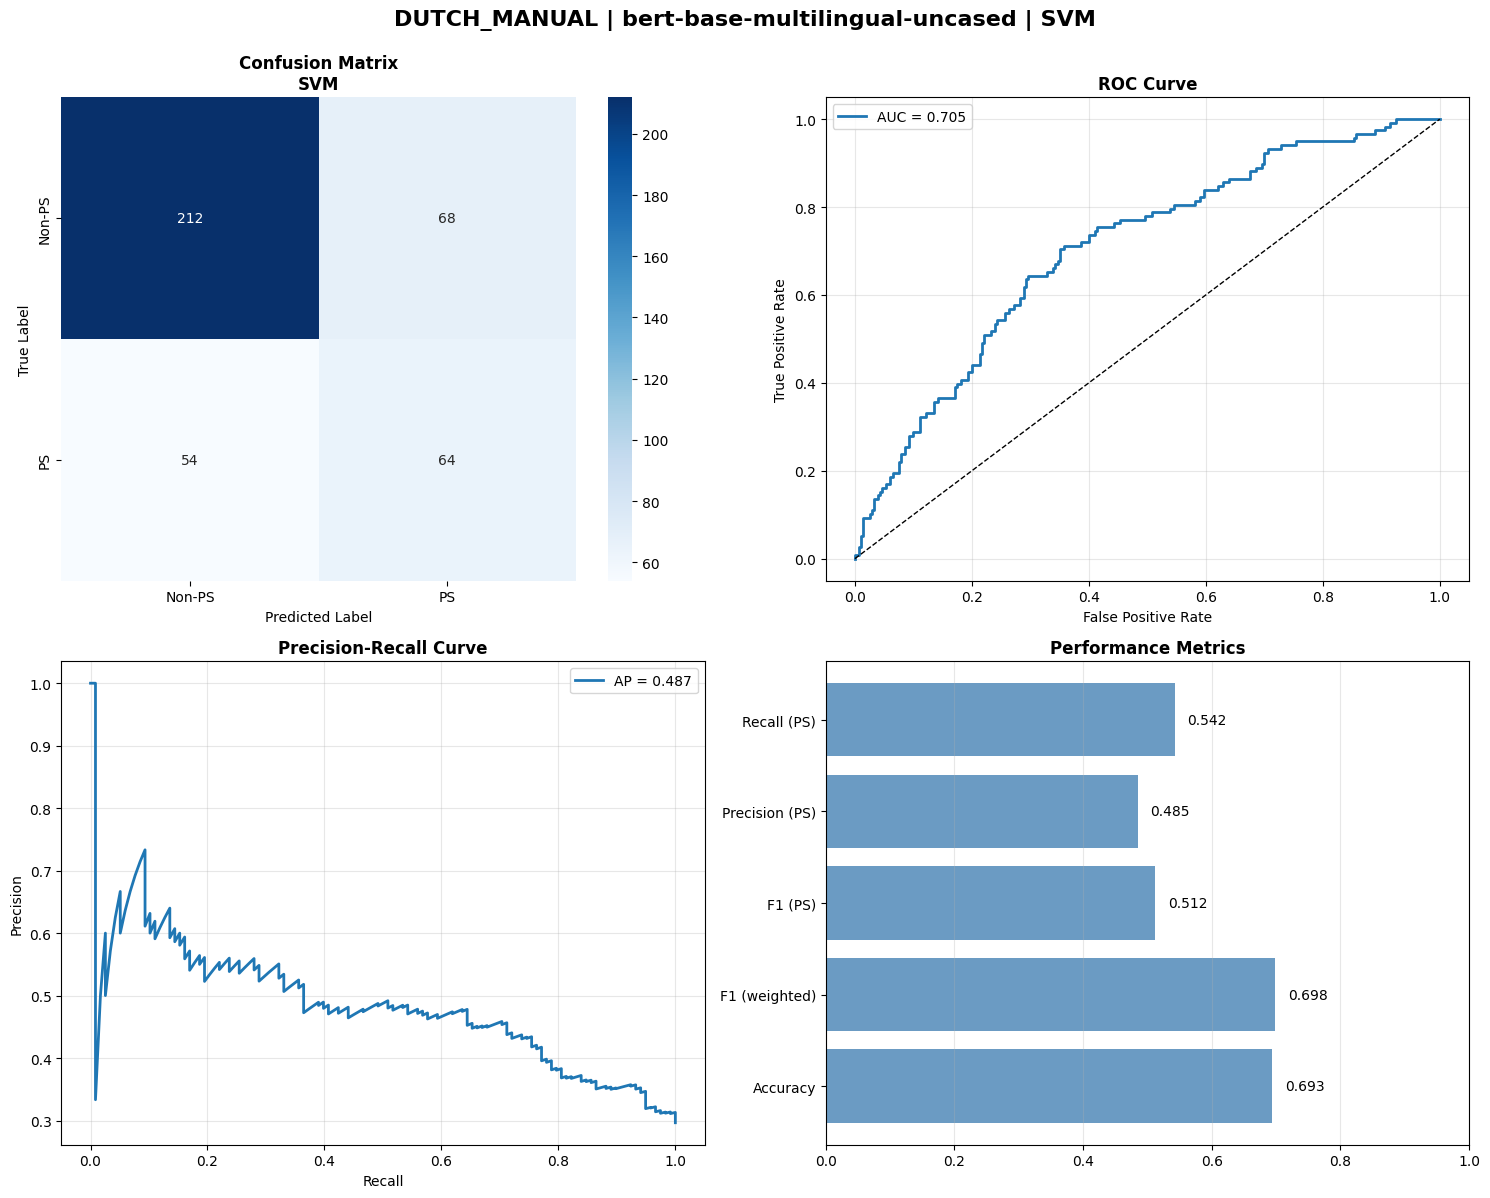


Detailed Report: DUTCH_MANUAL | bert-base-multilingual-uncased | Random_Forest

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.7638    0.9357    0.8411       280
    Process Safety     0.6727    0.3136    0.4277       118

          accuracy                         0.7513       398
         macro avg     0.7183    0.6246    0.6344       398
      weighted avg     0.7368    0.7513    0.7185       398


 Visualization saved to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_4/eval_dutch_manual_bert-base-multilingual-uncased_Random_Forest.png


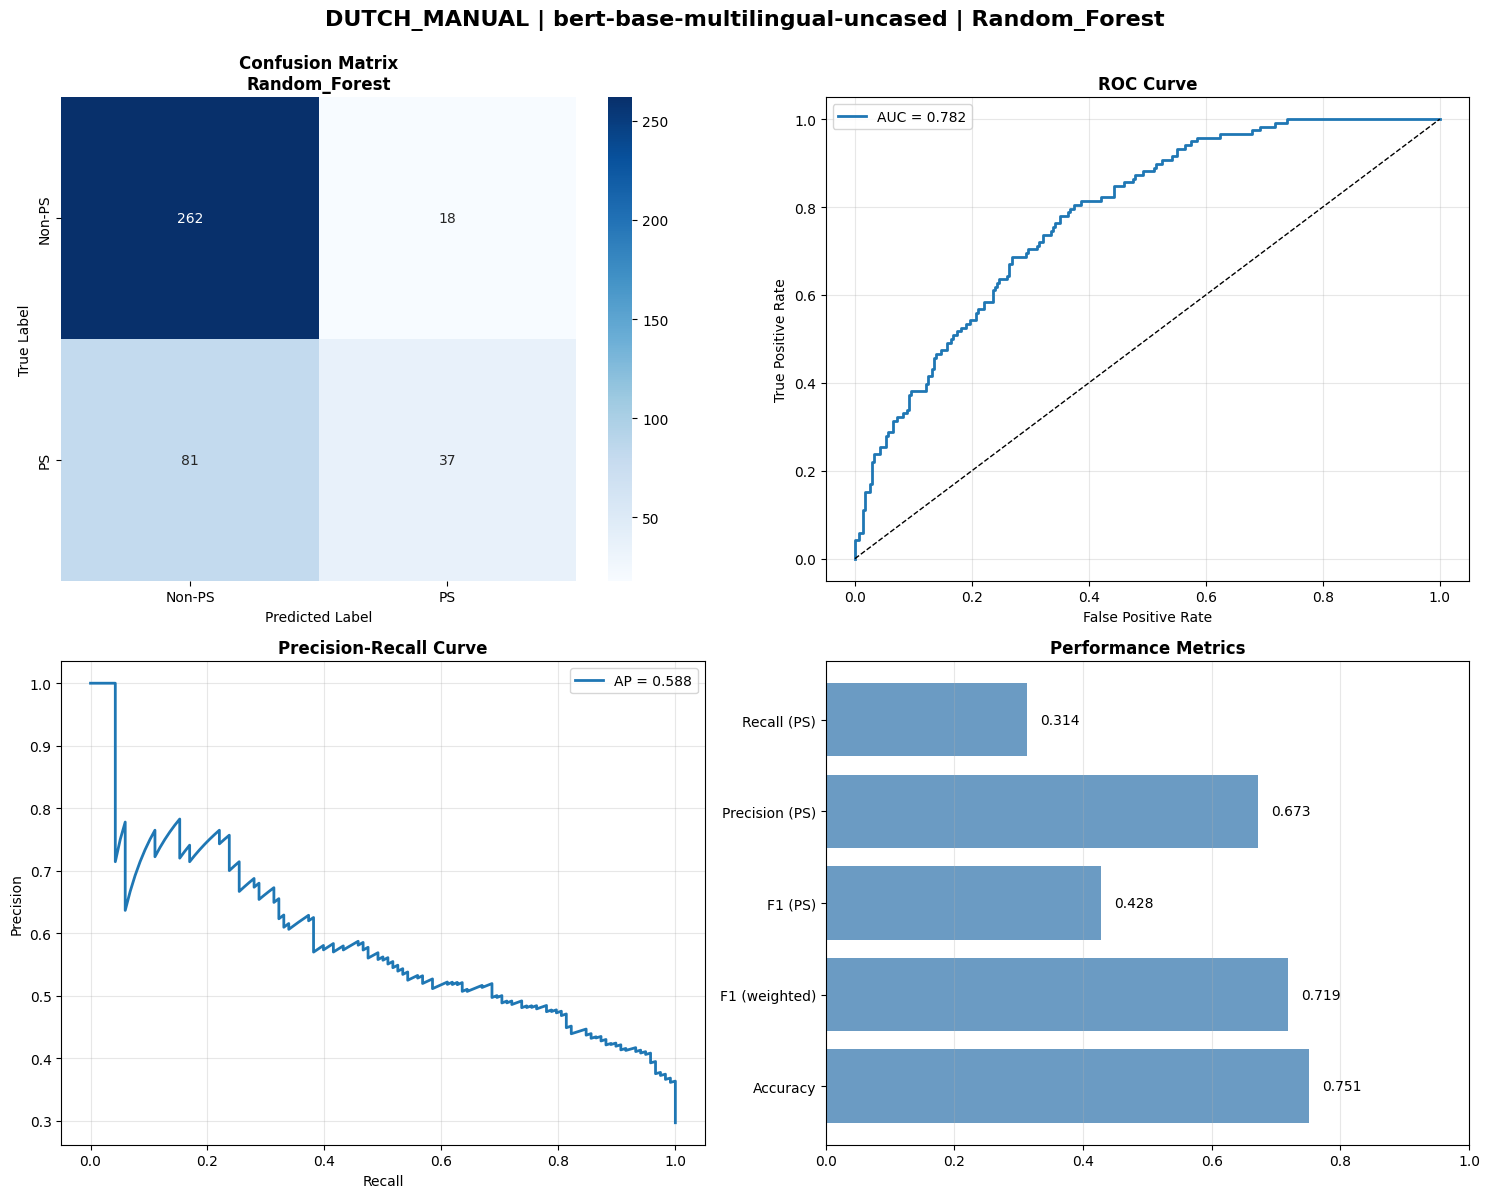


Detailed Report: DUTCH_MANUAL | bert-base-multilingual-uncased | XGBoost

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.7926    0.8464    0.8187       280
    Process Safety     0.5657    0.4746    0.5161       118

          accuracy                         0.7362       398
         macro avg     0.6791    0.6605    0.6674       398
      weighted avg     0.7253    0.7362    0.7290       398


 Visualization saved to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_4/eval_dutch_manual_bert-base-multilingual-uncased_XGBoost.png


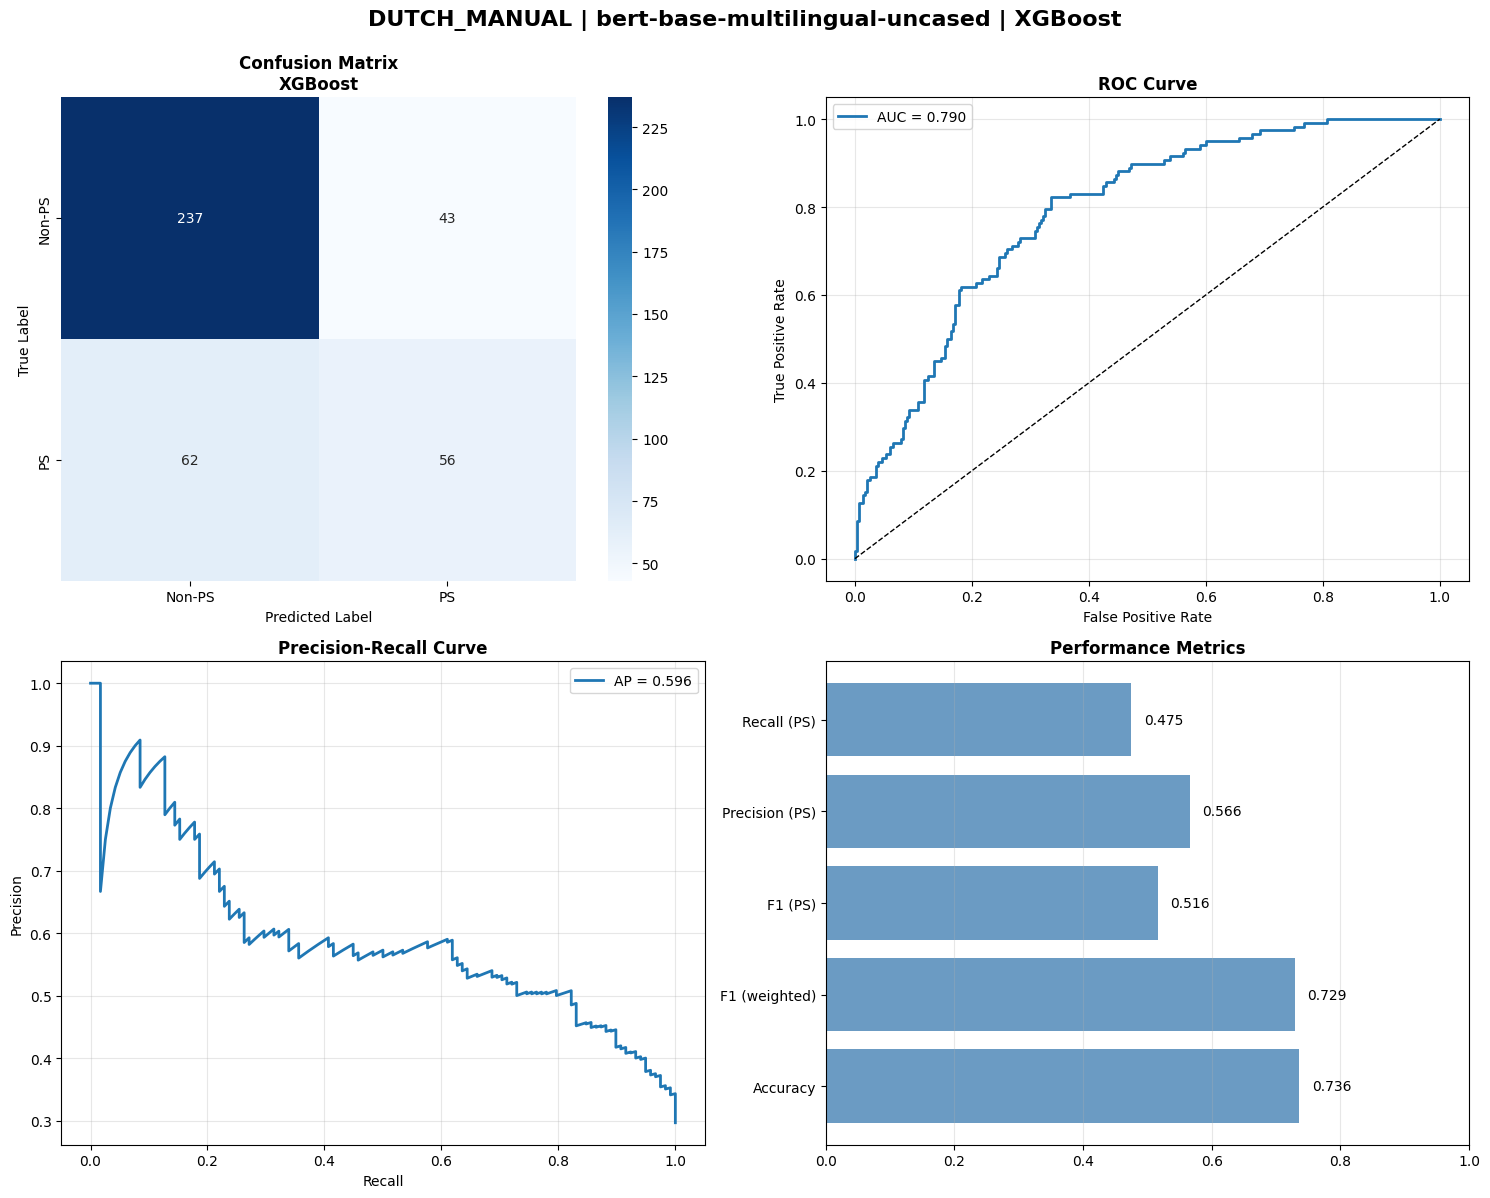


Detailed Report: DUTCH_MANUAL | bert-base-multilingual-uncased | LightGBM

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.7953    0.8464    0.8201       280
    Process Safety     0.5700    0.4831    0.5229       118

          accuracy                         0.7387       398
         macro avg     0.6827    0.6647    0.6715       398
      weighted avg     0.7285    0.7387    0.7320       398


 Visualization saved to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_4/eval_dutch_manual_bert-base-multilingual-uncased_LightGBM.png


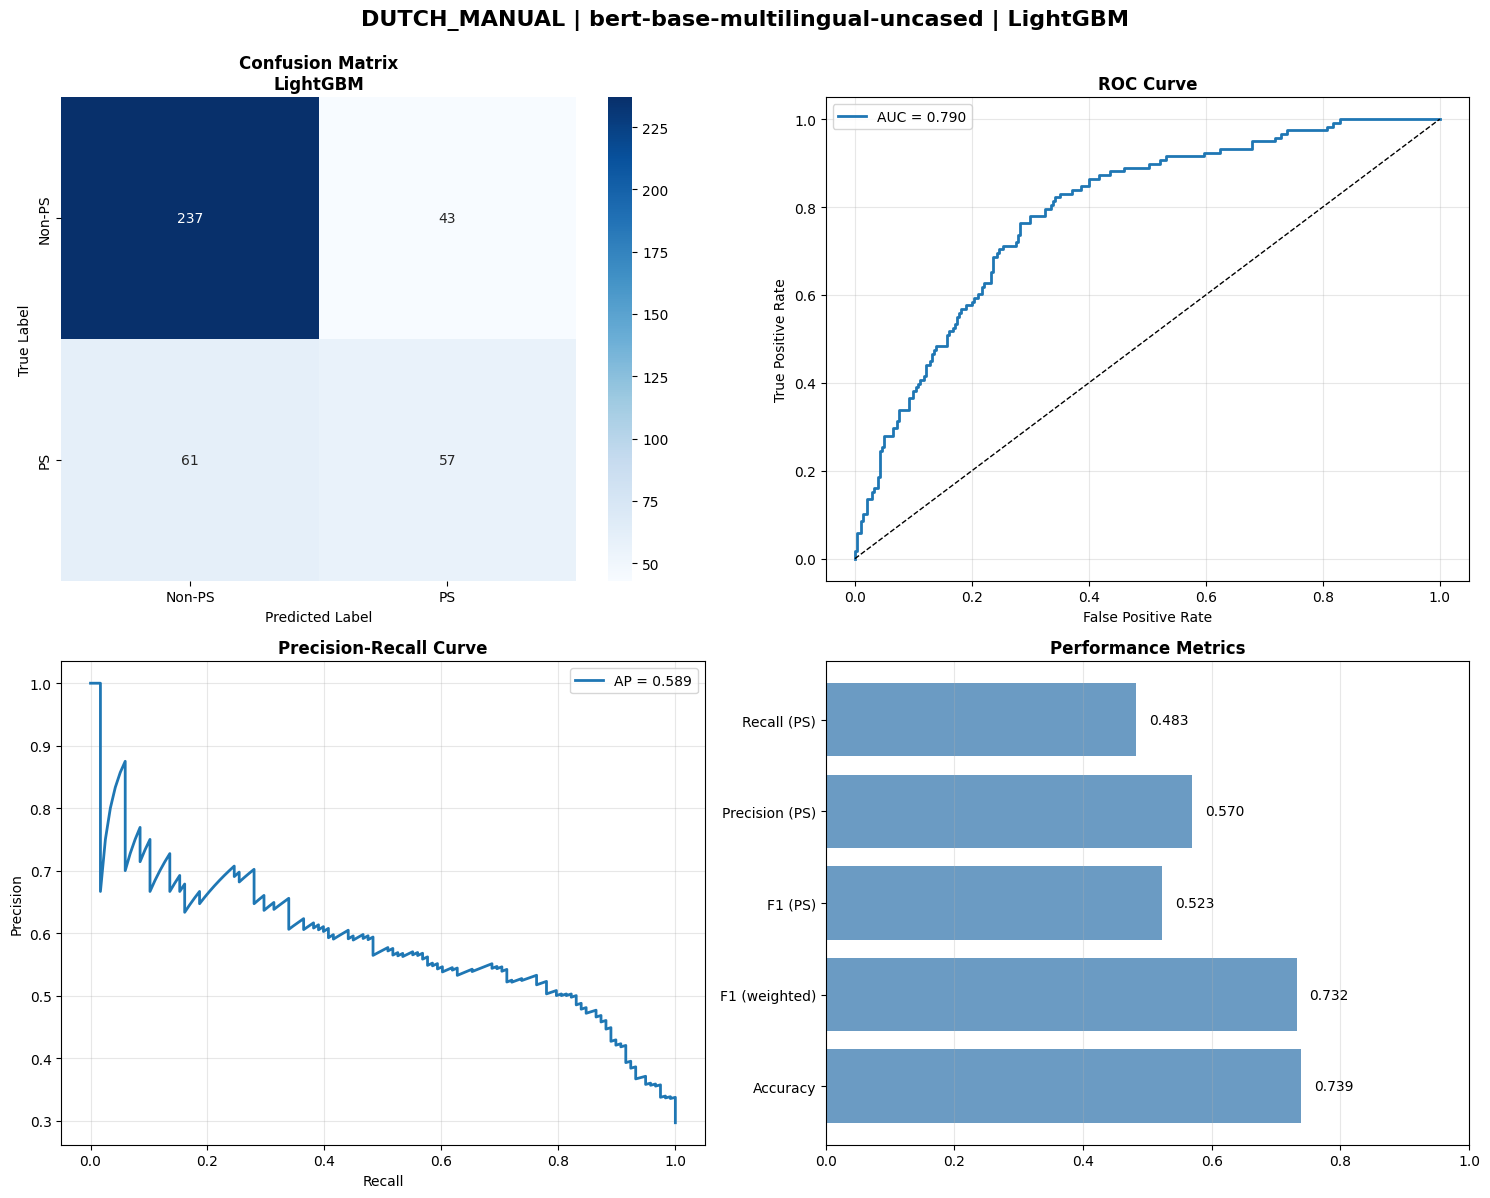


Detailed Report: DUTCH_MANUAL | bert-base-multilingual-uncased | Voting_Ensemble

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.7981    0.8893    0.8412       280
    Process Safety     0.6395    0.4661    0.5392       118

          accuracy                         0.7638       398
         macro avg     0.7188    0.6777    0.6902       398
      weighted avg     0.7511    0.7638    0.7517       398


 Visualization saved to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_4/eval_dutch_manual_bert-base-multilingual-uncased_Voting_Ensemble.png


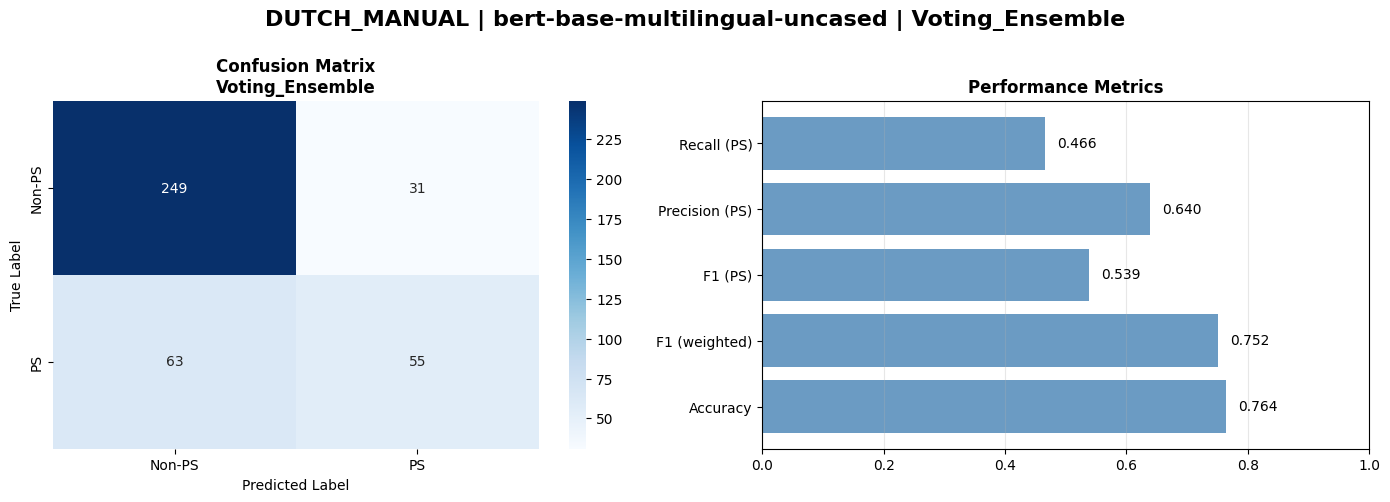


 Completed processing bert-base-multilingual-uncased

################################################################################
 MODEL: xlm-roberta-base
################################################################################

 Initializing xlm-roberta-base...
 Model loaded successfully!

 PHASE 1: GENERATING EMBEDDINGS - xlm-roberta-base

Processing: ENGLISH_MANUAL
Model: xlm-roberta-base
Dataset shape: (4713, 36)

Case type distribution:
CASE_TYPE
Safety                              2553
Process Safety                      1409
Environment                          454
Asset and Reputation damage/loss     145
Operational loss                     123
Physical Security                     14
Information Security                  12
Not classified                         3
Name: count, dtype: int64

Class balance:
binary_label
0    0.70104
1    0.29896
Name: proportion, dtype: float64

Applying advanced text preprocessing...

Generating xlm-roberta-base embeddings...
Usin

Generating embeddings: 100%|██████████| 393/393 [01:28<00:00,  4.44it/s]



Training set: (3770, 768)
Test set: (943, 768)

 Applying SMOTE for class balancing...
   Strategy: Oversample minority to 70.0% of majority
   Original training size: 3770
   Balanced training size: 4493
   Original class distribution: [2643 1127]
   Balanced class distribution: [2643 1850]

 Applying feature scaling...

Embeddings saved!
Location: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_4/xlm-roberta-base/english_manual_xlm-roberta-base_embeddings.pkl
Size: 44.41 MB

Checkpoint saved: 5 combinations processed
 Progress: 5/40

Processing: GERMAN_MANUAL
Model: xlm-roberta-base
Dataset shape: (14951, 36)

Case type distribution:
CASE_TYPE
Safety                              11506
Process Safety                       1661
Environment                          1038
Asset and Reputation damage/loss      518
Information Security                  156
Operational loss                       39
Physical Security                      30
Not classified    

Generating embeddings: 100%|██████████| 1246/1246 [03:15<00:00,  6.38it/s]



Training set: (11960, 768)
Test set: (2991, 768)

 Applying SMOTE for class balancing...
   Strategy: Oversample minority to 70.0% of majority
   Original training size: 11960
   Balanced training size: 18072
   Original class distribution: [10631  1329]
   Balanced class distribution: [10631  7441]

 Training set too large (18072 samples)
   Subsampling to 6000 for SVM efficiency...
   Subsampled training set: (6000, 768)

 Applying feature scaling...

Embeddings saved!
Location: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_4/xlm-roberta-base/german_manual_xlm-roberta-base_embeddings.pkl
Size: 126.49 MB

Checkpoint saved: 6 combinations processed
 Progress: 6/40

Processing: SWEDISH_MANUAL
Model: xlm-roberta-base
Dataset shape: (12224, 36)

Case type distribution:
CASE_TYPE
Safety                              9974
Process Safety                       773
Environment                          681
Asset and Reputation damage/loss     549
Operational l

Generating embeddings: 100%|██████████| 1019/1019 [01:14<00:00, 13.63it/s]



Training set: (9779, 768)
Test set: (2445, 768)

 Applying SMOTE for class balancing...
   Strategy: Oversample minority to 70.0% of majority
   Original training size: 9779
   Balanced training size: 15573
   Original class distribution: [9161  618]
   Balanced class distribution: [9161 6412]

 Training set too large (15573 samples)
   Subsampling to 6000 for SVM efficiency...
   Subsampled training set: (6000, 768)

 Applying feature scaling...

Embeddings saved!
Location: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_4/xlm-roberta-base/swedish_manual_xlm-roberta-base_embeddings.pkl
Size: 107.54 MB

Checkpoint saved: 7 combinations processed
 Progress: 7/40

Processing: DUTCH_MANUAL
Model: xlm-roberta-base
Dataset shape: (1990, 36)

Case type distribution:
CASE_TYPE
Safety                              649
Process Safety                      588
Environment                         536
Asset and Reputation damage/loss    110
Operational loss         

Generating embeddings: 100%|██████████| 166/166 [00:49<00:00,  3.36it/s]


Training set: (1592, 768)
Test set: (398, 768)

 Applying SMOTE for class balancing...
   Strategy: Oversample minority to 70.0% of majority
   Original training size: 1592
   Balanced training size: 1907
   Original class distribution: [1122  470]
   Balanced class distribution: [1122  785]

 Applying feature scaling...

Embeddings saved!
Location: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_4/xlm-roberta-base/dutch_manual_xlm-roberta-base_embeddings.pkl
Size: 18.93 MB

Checkpoint saved: 8 combinations processed
 Progress: 8/40

 PHASE 2: TRAINING CLASSIFIERS - xlm-roberta-base

################################################################################
 Training Pipeline: ENGLISH_MANUAL
################################################################################
Model: xlm-roberta-base
Pooling: mean
SMOTE used: True
Feature scaling: True

Training Multiple Classifiers: ENGLISH_MANUAL
Training samples: 4493
Test samples: 943
Features: 768

   Best parameters: {'C': 0.1, 'class_weight': 'balanced', 'max_iter': 10000}
   Best CV score: 0.7835
   Accuracy: 0.7699
   F1 (weighted): 0.7748
   F1 (Process Safety): 0.6472
   ROC AUC: 0.8379
   Training time: 160.99s

────────────────────────────────────────────────────────────
 Random_Forest
────────────────────────────────────────────────────────────
   Accuracy: 0.8070
   F1 (weighted): 0.8009
   F1 (Process Safety): 0.6445
   ROC AUC: 0.8488
   Training time: 1.88s

────────────────────────────────────────────────────────────
 XGBoost
────────────────────────────────────────────────────────────
   Accuracy: 0.8049
   F1 (weighted): 0.8011
   F1 (Process Safety): 0.6528
   ROC AUC: 0.8464
   Training time: 4.52s

────────────────────────────────────────────────────────────
 LightGBM
────────────────────────────────────────────────────────────
   Accuracy: 0.8070
   F1 (weighted): 0.8044
   F1 (Process Safety): 0.6630
   ROC AUC: 0.8515
   Training time: 1.86s

───────────────

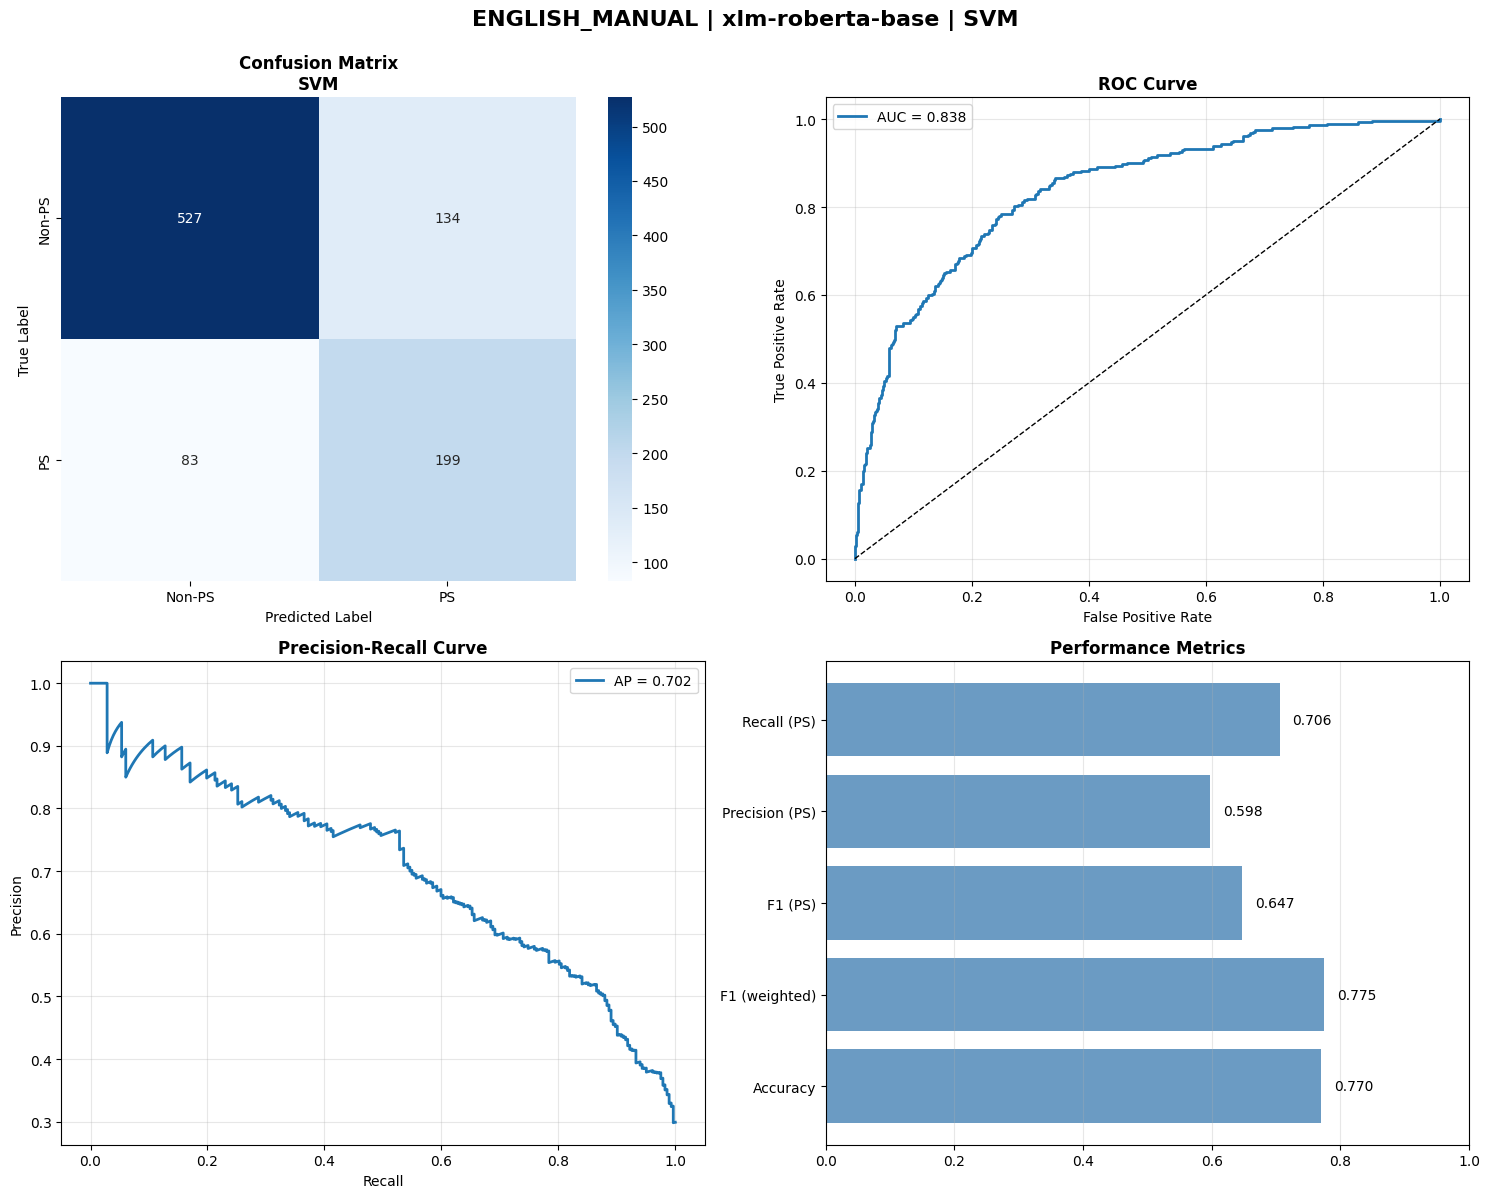


Detailed Report: ENGLISH_MANUAL | xlm-roberta-base | Random_Forest

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.8359    0.9017    0.8675       661
    Process Safety     0.7174    0.5851    0.6445       282

          accuracy                         0.8070       943
         macro avg     0.7766    0.7434    0.7560       943
      weighted avg     0.8005    0.8070    0.8009       943


 Visualization saved to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_4/eval_english_manual_xlm-roberta-base_Random_Forest.png


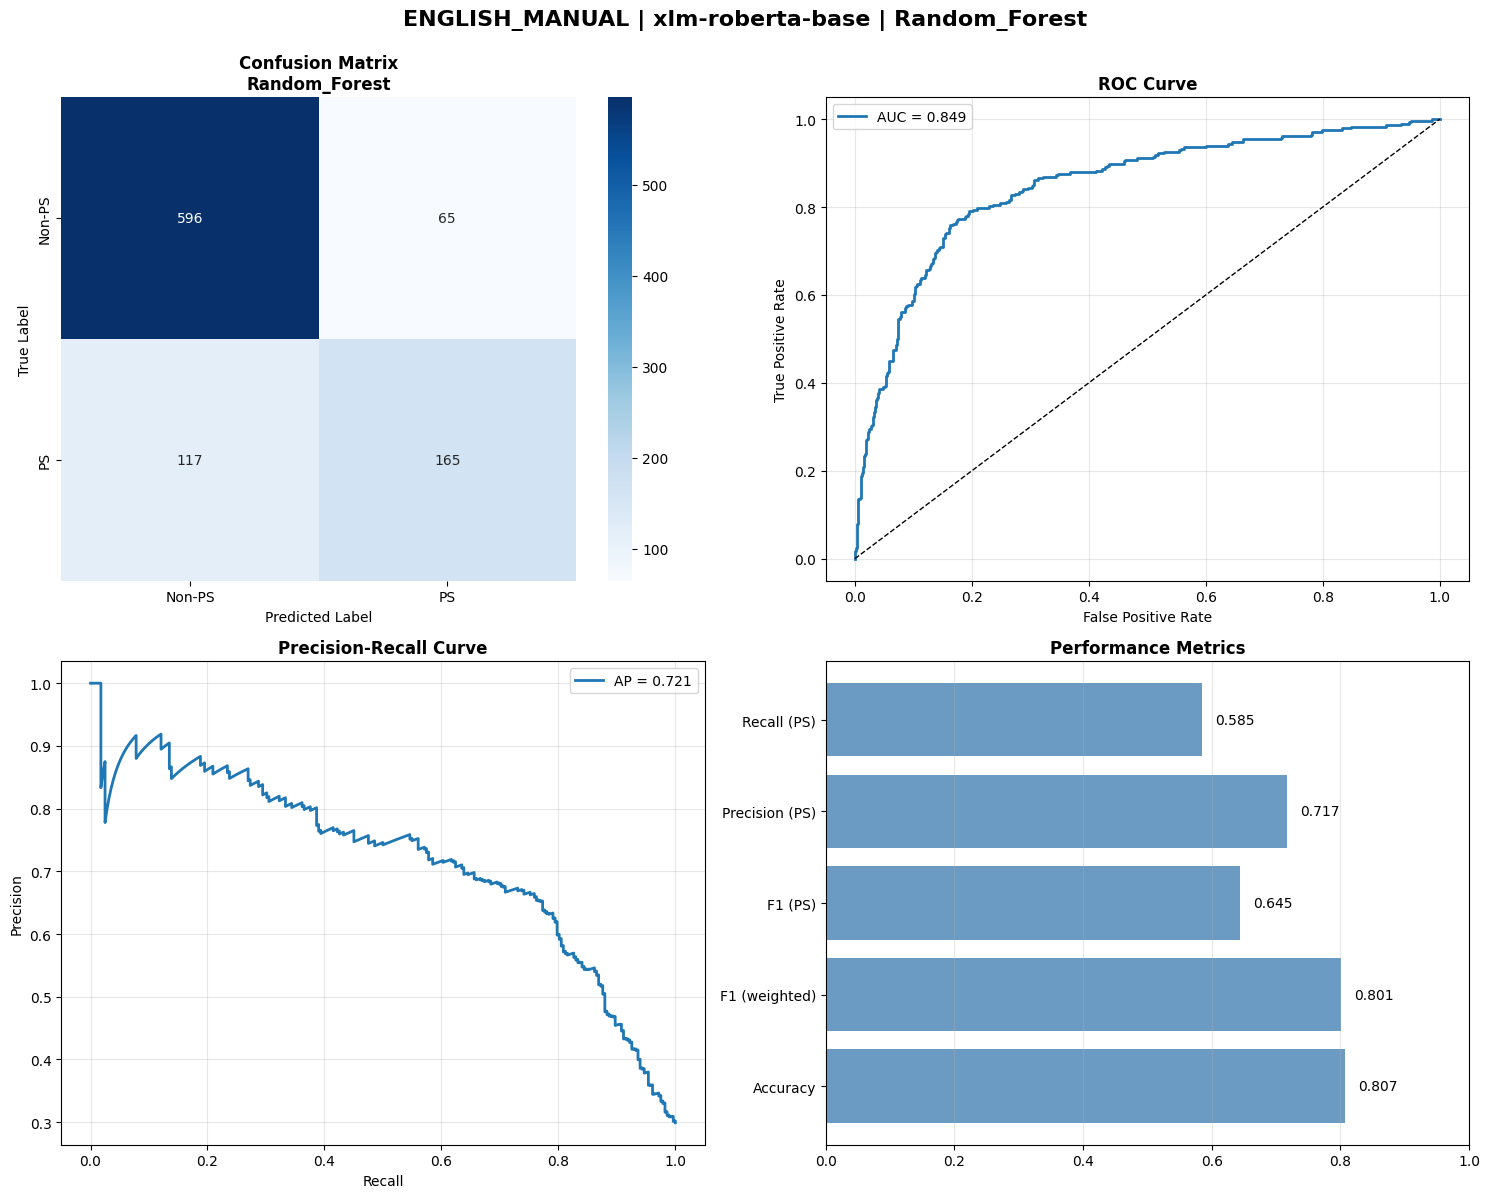


Detailed Report: ENGLISH_MANUAL | xlm-roberta-base | XGBoost

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.8432    0.8865    0.8643       661
    Process Safety     0.6976    0.6135    0.6528       282

          accuracy                         0.8049       943
         macro avg     0.7704    0.7500    0.7586       943
      weighted avg     0.7996    0.8049    0.8011       943


 Visualization saved to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_4/eval_english_manual_xlm-roberta-base_XGBoost.png


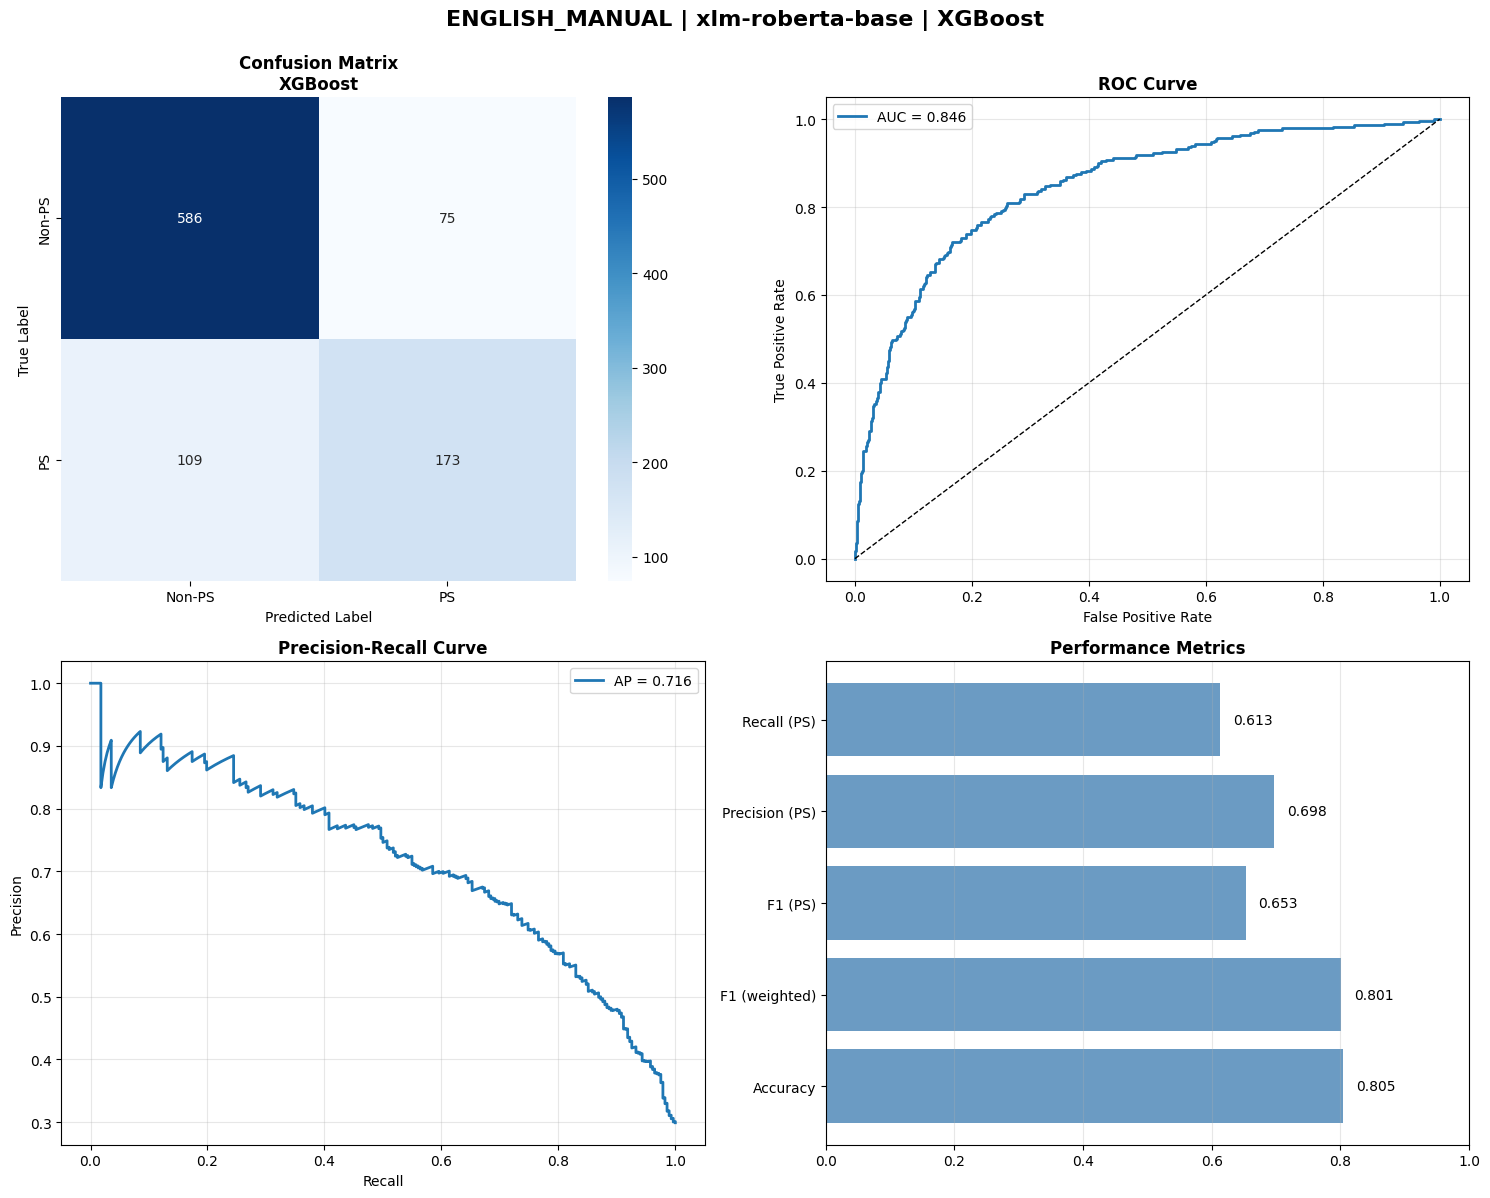


Detailed Report: ENGLISH_MANUAL | xlm-roberta-base | LightGBM

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.8496    0.8805    0.8648       661
    Process Safety     0.6938    0.6348    0.6630       282

          accuracy                         0.8070       943
         macro avg     0.7717    0.7576    0.7639       943
      weighted avg     0.8030    0.8070    0.8044       943


 Visualization saved to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_4/eval_english_manual_xlm-roberta-base_LightGBM.png


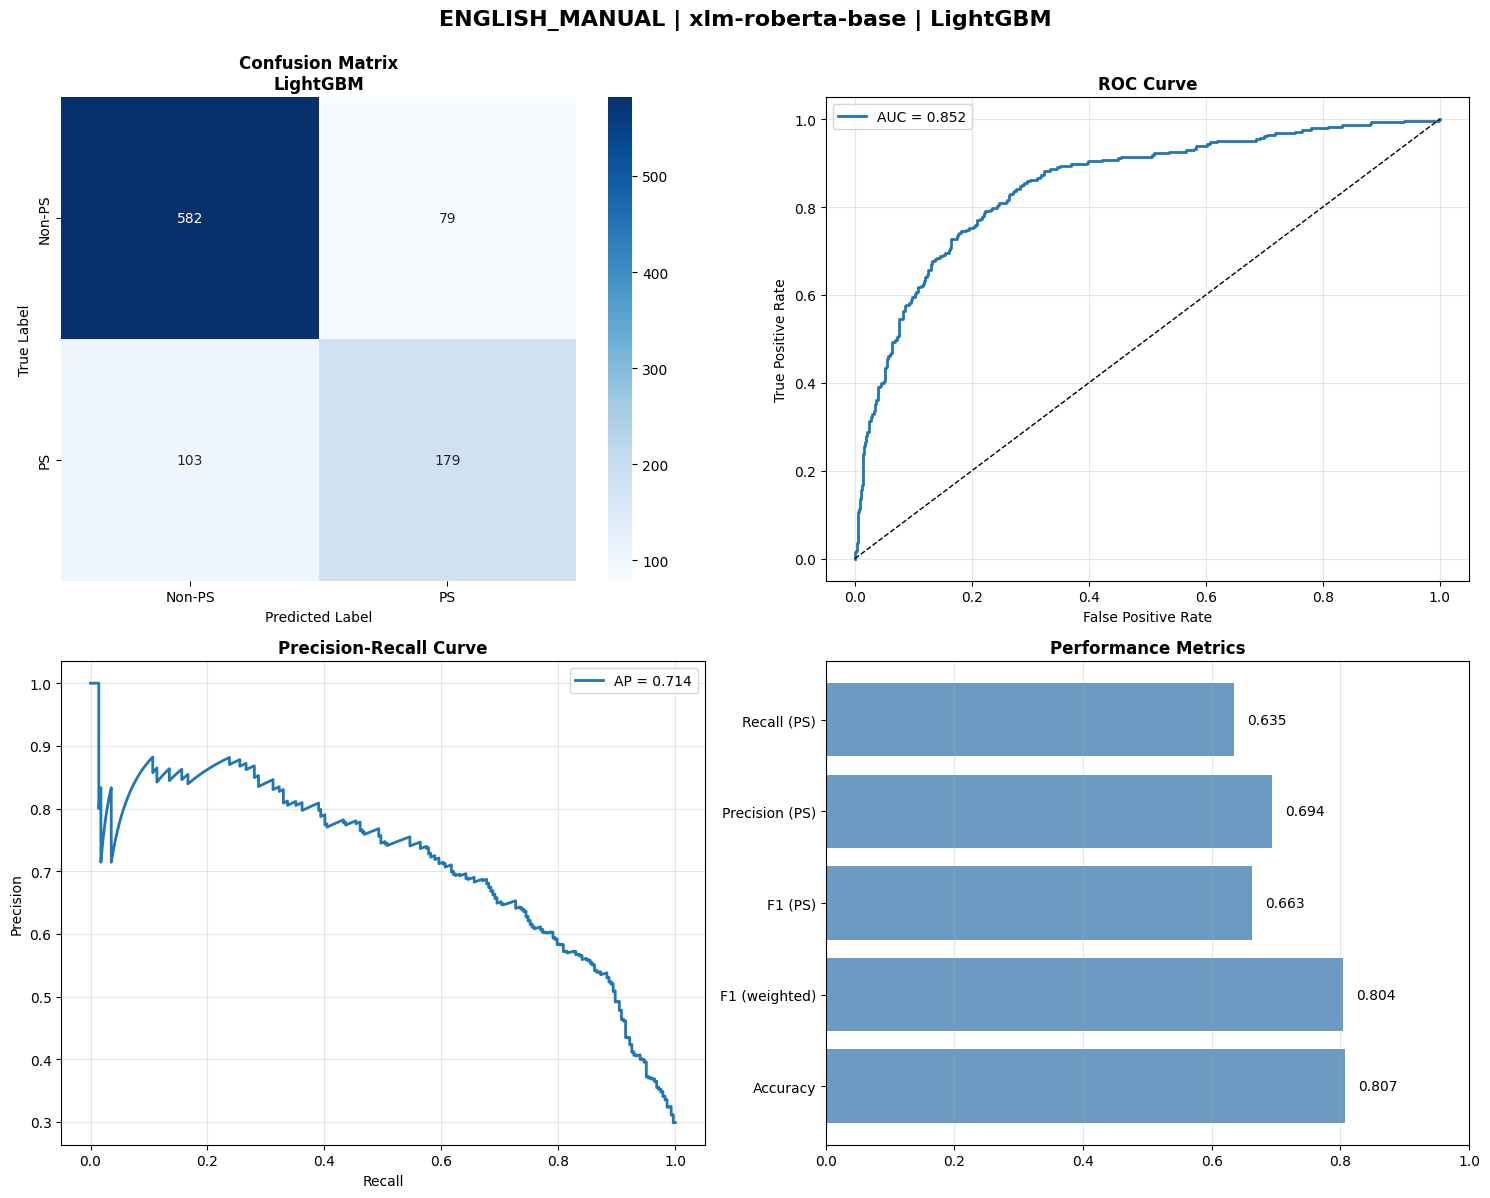


Detailed Report: ENGLISH_MANUAL | xlm-roberta-base | Voting_Ensemble

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.8485    0.8896    0.8685       661
    Process Safety     0.7080    0.6277    0.6654       282

          accuracy                         0.8112       943
         macro avg     0.7782    0.7586    0.7670       943
      weighted avg     0.8065    0.8112    0.8078       943


 Visualization saved to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_4/eval_english_manual_xlm-roberta-base_Voting_Ensemble.png


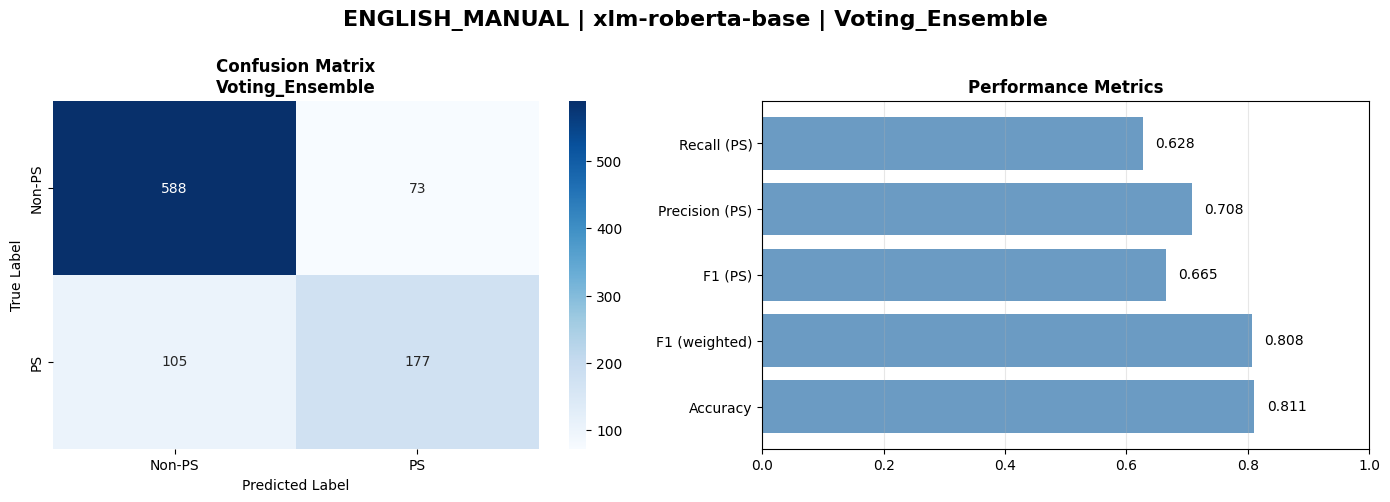


################################################################################
 Training Pipeline: GERMAN_MANUAL
################################################################################
Model: xlm-roberta-base
Pooling: mean
SMOTE used: True
Feature scaling: True

Training Multiple Classifiers: GERMAN_MANUAL
Training samples: 6000
Test samples: 2991
Features: 768

 Training SVM with hyperparameter tuning...

 Training Random Forest...

 Training XGBoost...

 Training LightGBM...

────────────────────────────────────────────────────────────
 SVM
────────────────────────────────────────────────────────────
   Best parameters: {'C': 0.1, 'class_weight': 'balanced', 'max_iter': 10000}
   Best CV score: 0.8352
   Accuracy: 0.7867
   F1 (weighted): 0.8185
   F1 (Process Safety): 0.4060
   ROC AUC: 0.7891
   Training time: 27.06s

────────────────────────────────────────────────────────────
 Random_Forest
────────────────────────────────────────────────────────────
   Accuracy: 0.89

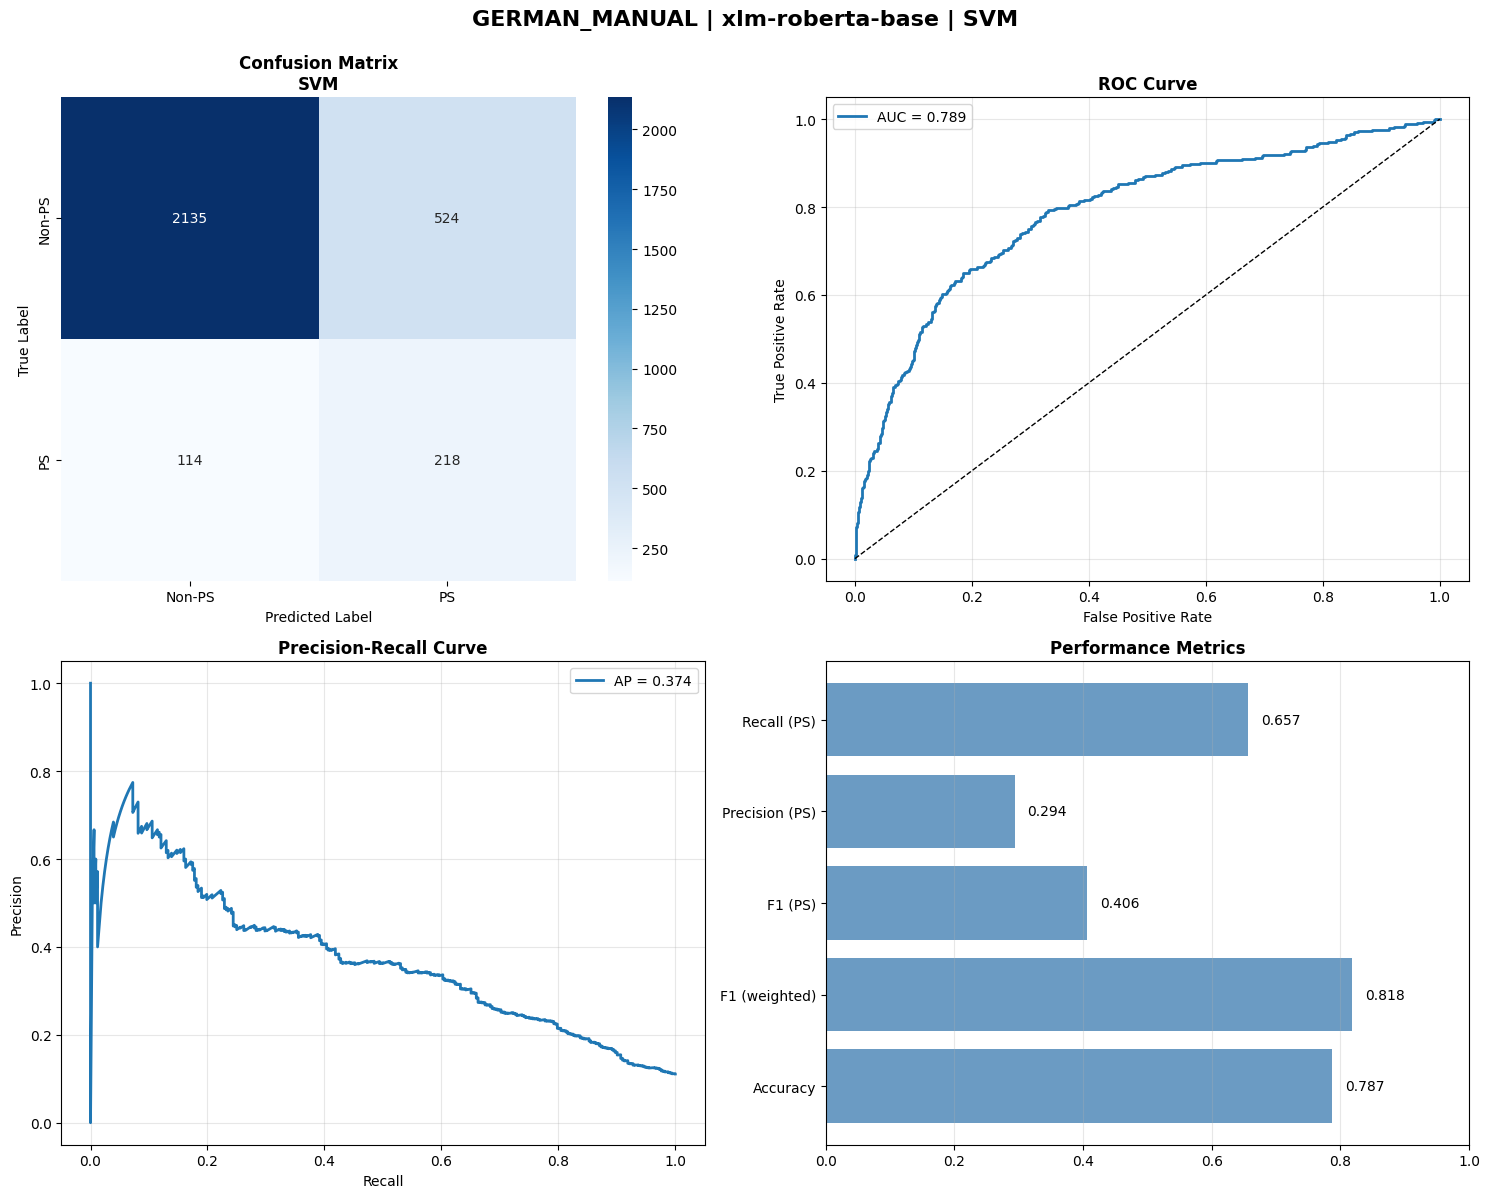


Detailed Report: GERMAN_MANUAL | xlm-roberta-base | Random_Forest

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.9325    0.9451    0.9387      2659
    Process Safety     0.5068    0.4518    0.4777       332

          accuracy                         0.8903      2991
         macro avg     0.7196    0.6984    0.7082      2991
      weighted avg     0.8852    0.8903    0.8876      2991


 Visualization saved to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_4/eval_german_manual_xlm-roberta-base_Random_Forest.png


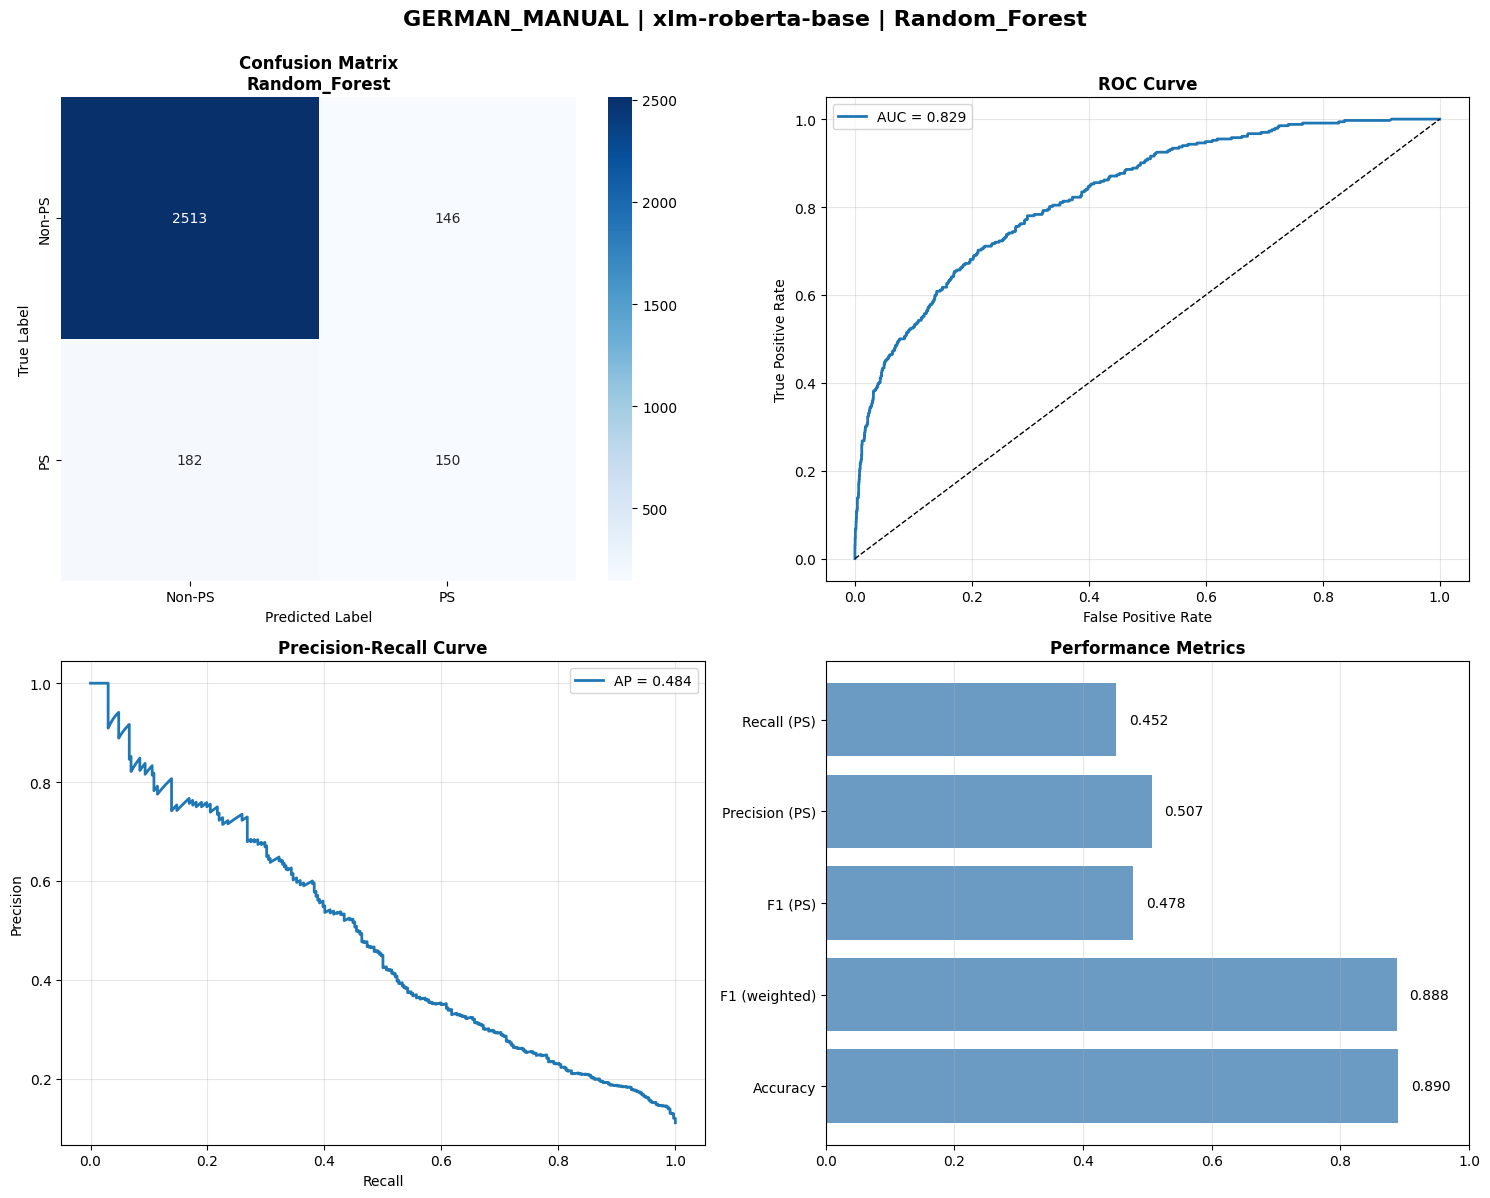


Detailed Report: GERMAN_MANUAL | xlm-roberta-base | XGBoost

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.9361    0.9146    0.9252      2659
    Process Safety     0.4224    0.5000    0.4579       332

          accuracy                         0.8686      2991
         macro avg     0.6792    0.7073    0.6916      2991
      weighted avg     0.8791    0.8686    0.8734      2991


 Visualization saved to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_4/eval_german_manual_xlm-roberta-base_XGBoost.png


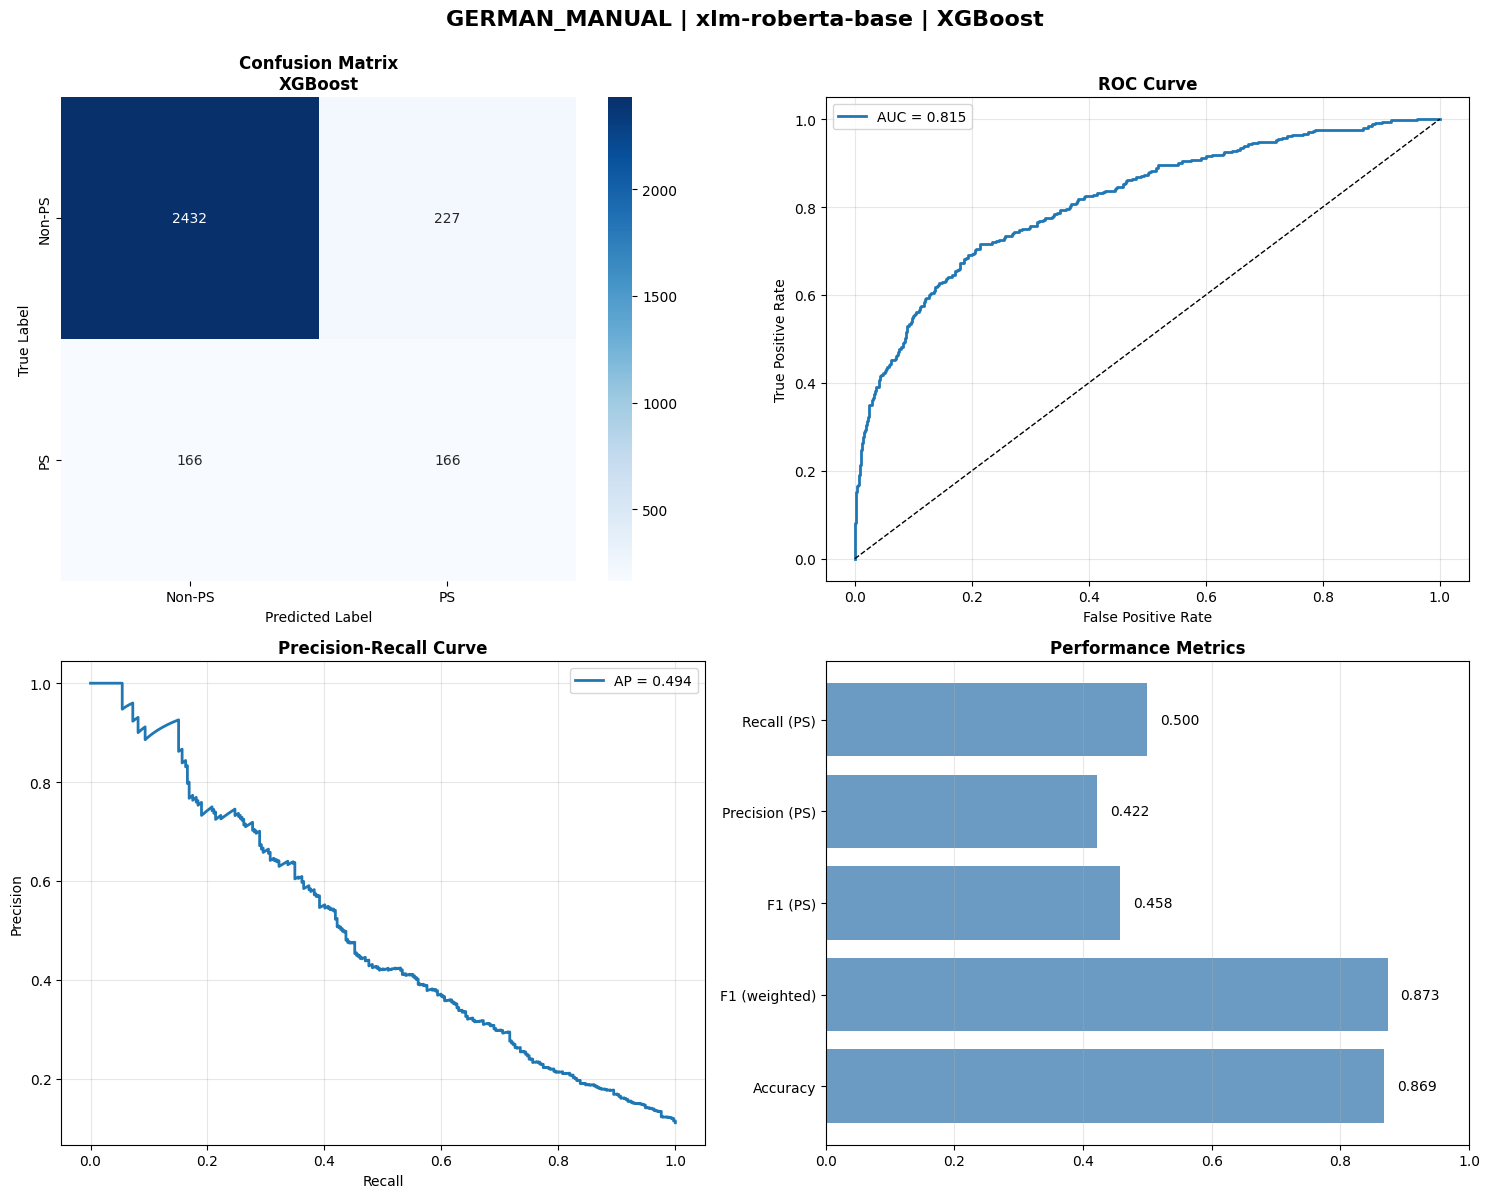


Detailed Report: GERMAN_MANUAL | xlm-roberta-base | LightGBM

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.9369    0.9154    0.9260      2659
    Process Safety     0.4275    0.5060    0.4634       332

          accuracy                         0.8699      2991
         macro avg     0.6822    0.7107    0.6947      2991
      weighted avg     0.8803    0.8699    0.8747      2991


 Visualization saved to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_4/eval_german_manual_xlm-roberta-base_LightGBM.png


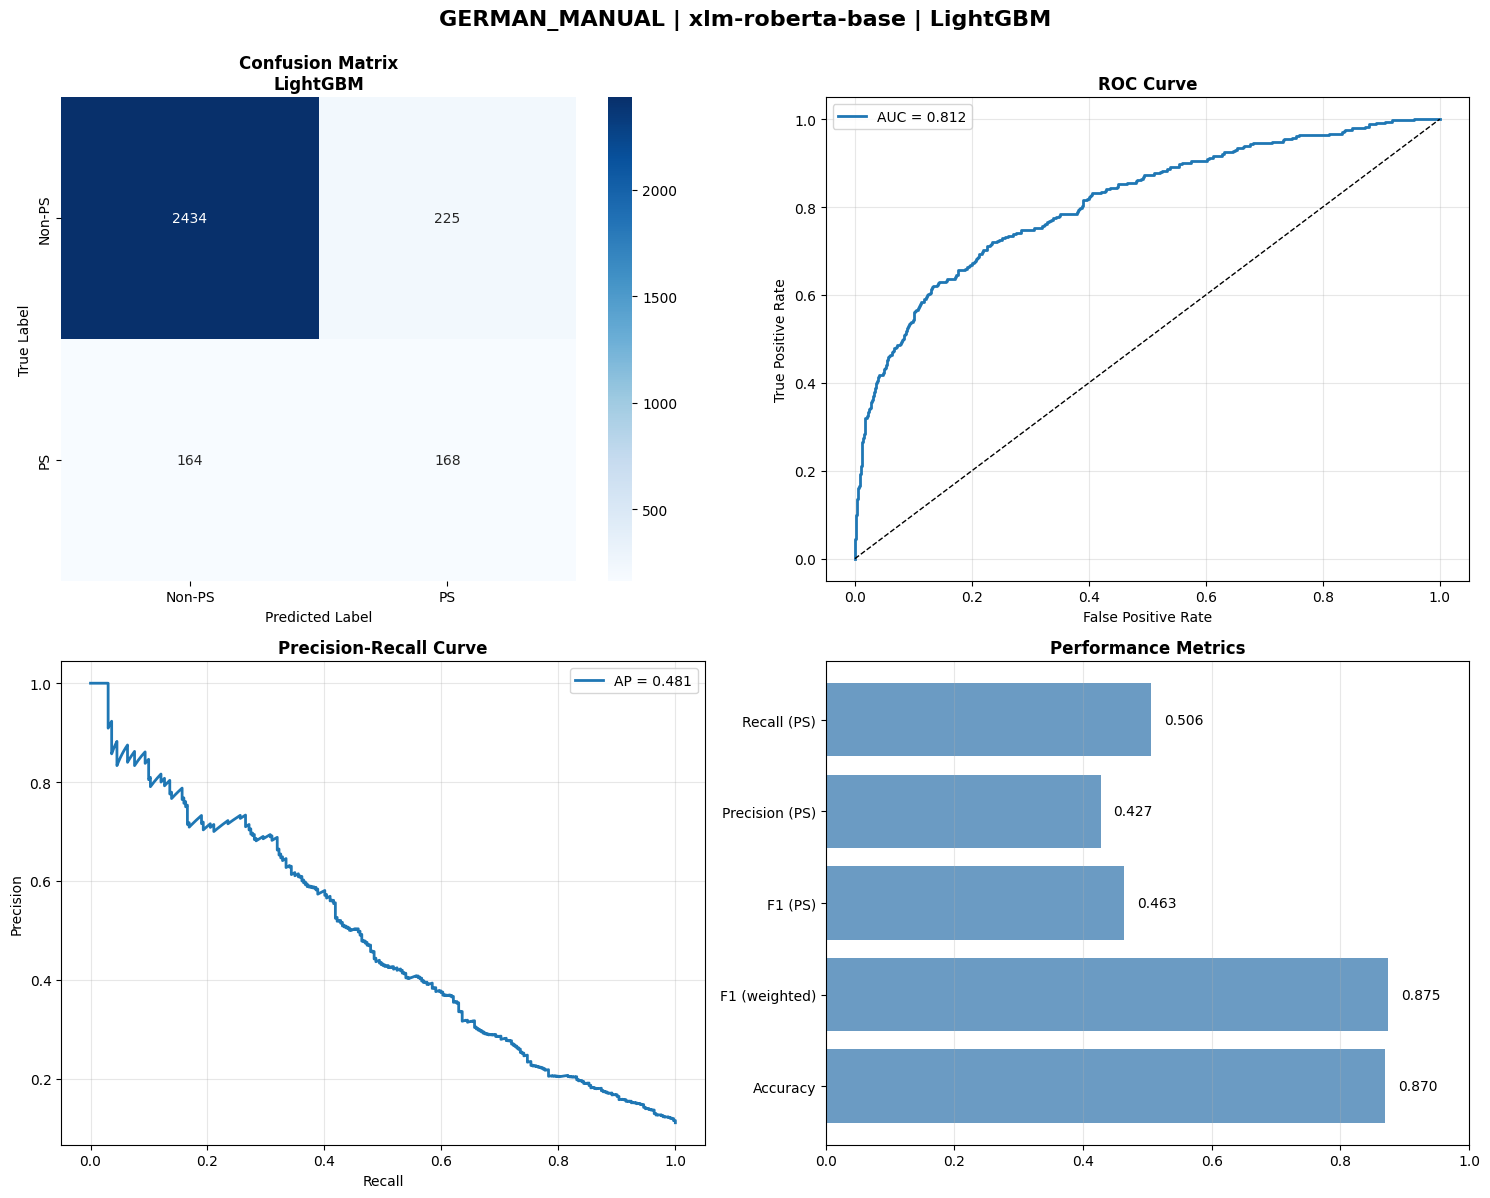


Detailed Report: GERMAN_MANUAL | xlm-roberta-base | Voting_Ensemble

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.9389    0.9297    0.9342      2659
    Process Safety     0.4777    0.5151    0.4957       332

          accuracy                         0.8837      2991
         macro avg     0.7083    0.7224    0.7149      2991
      weighted avg     0.8877    0.8837    0.8856      2991


 Visualization saved to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_4/eval_german_manual_xlm-roberta-base_Voting_Ensemble.png


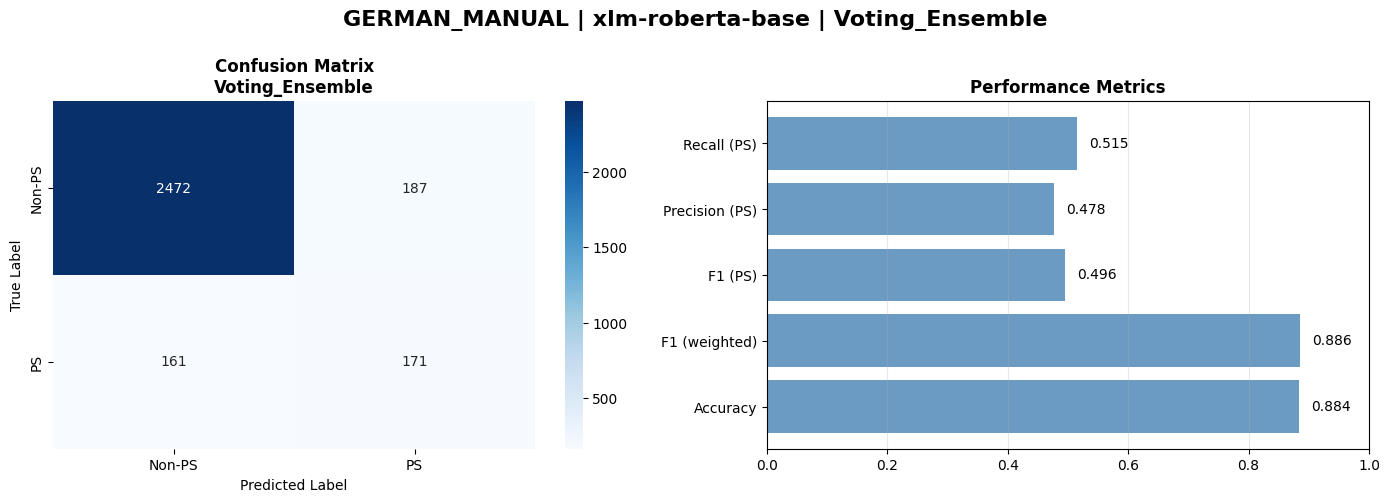


################################################################################
 Training Pipeline: SWEDISH_MANUAL
################################################################################
Model: xlm-roberta-base
Pooling: mean
SMOTE used: True
Feature scaling: True

Training Multiple Classifiers: SWEDISH_MANUAL
Training samples: 6000
Test samples: 2445
Features: 768

 Training SVM with hyperparameter tuning...

 Training Random Forest...

 Training XGBoost...

 Training LightGBM...

────────────────────────────────────────────────────────────
 SVM
────────────────────────────────────────────────────────────
   Best parameters: {'C': 1, 'class_weight': {0: 1, 1: 3}, 'max_iter': 10000}
   Best CV score: 0.8645
   Accuracy: 0.7710
   F1 (weighted): 0.8254
   F1 (Process Safety): 0.2371
   ROC AUC: 0.7153
   Training time: 540.74s

────────────────────────────────────────────────────────────
 Random_Forest
────────────────────────────────────────────────────────────
   Accuracy: 0

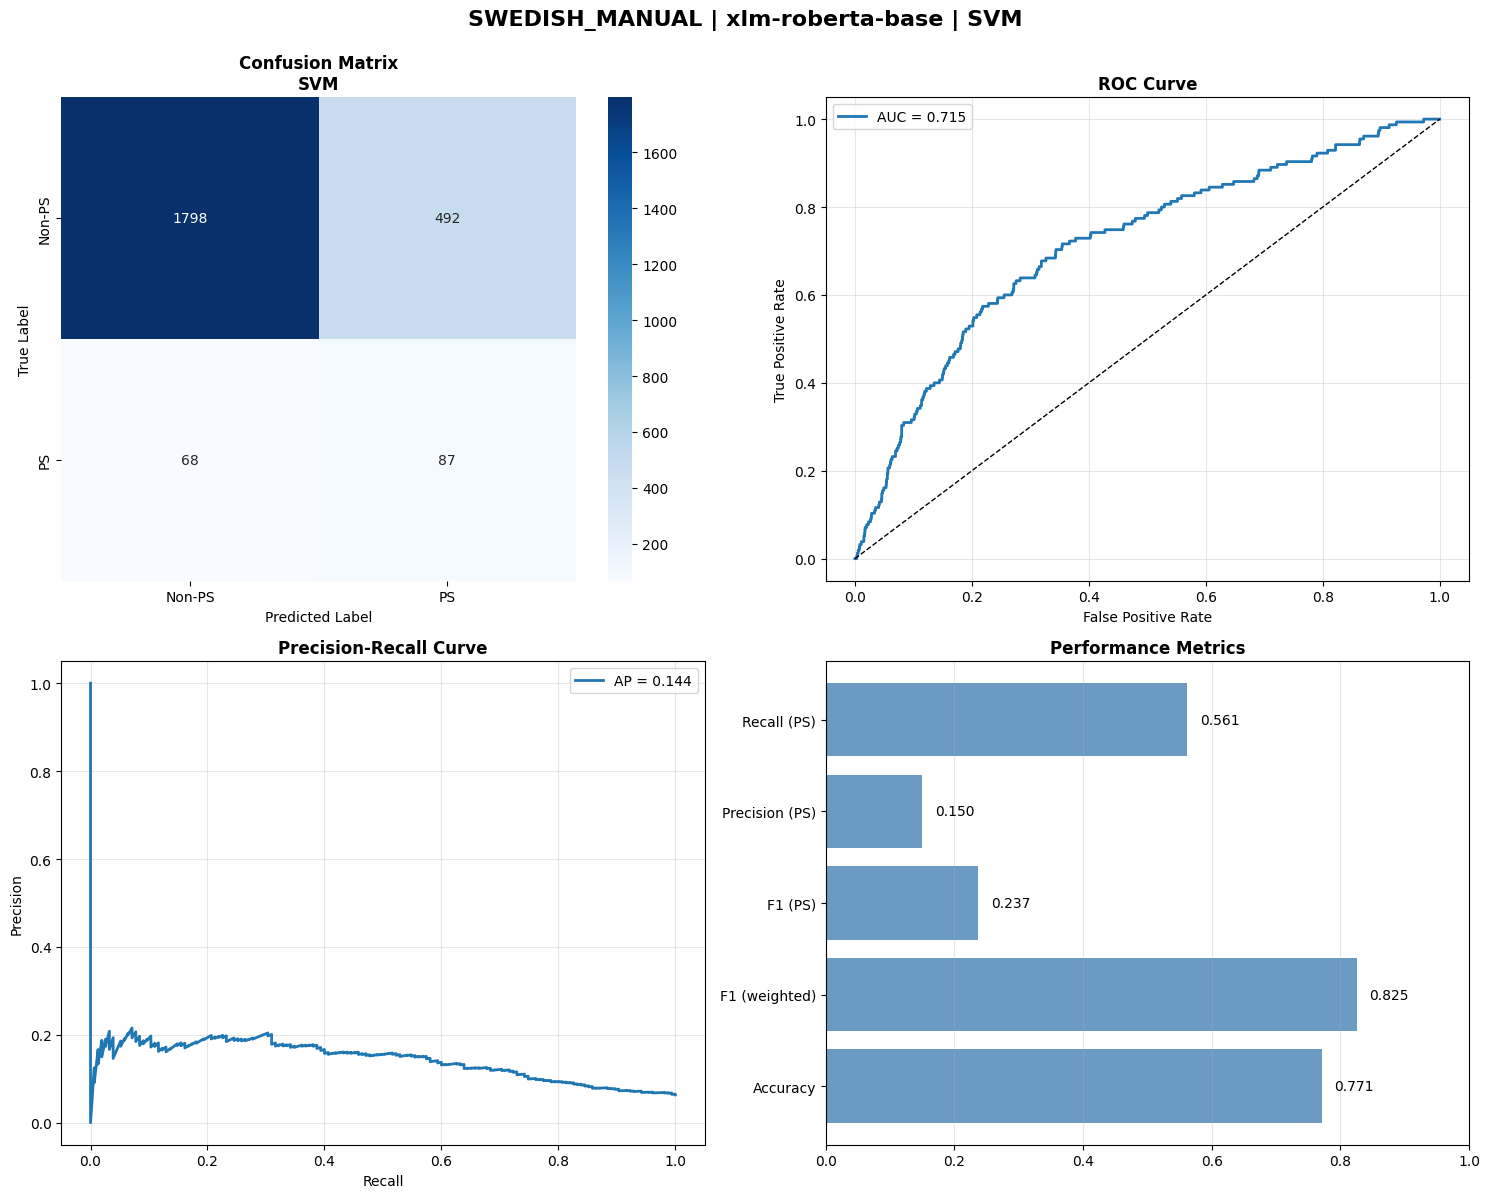


Detailed Report: SWEDISH_MANUAL | xlm-roberta-base | Random_Forest

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.9493    0.9493    0.9493      2290
    Process Safety     0.2516    0.2516    0.2516       155

          accuracy                         0.9051      2445
         macro avg     0.6005    0.6005    0.6005      2445
      weighted avg     0.9051    0.9051    0.9051      2445


 Visualization saved to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_4/eval_swedish_manual_xlm-roberta-base_Random_Forest.png


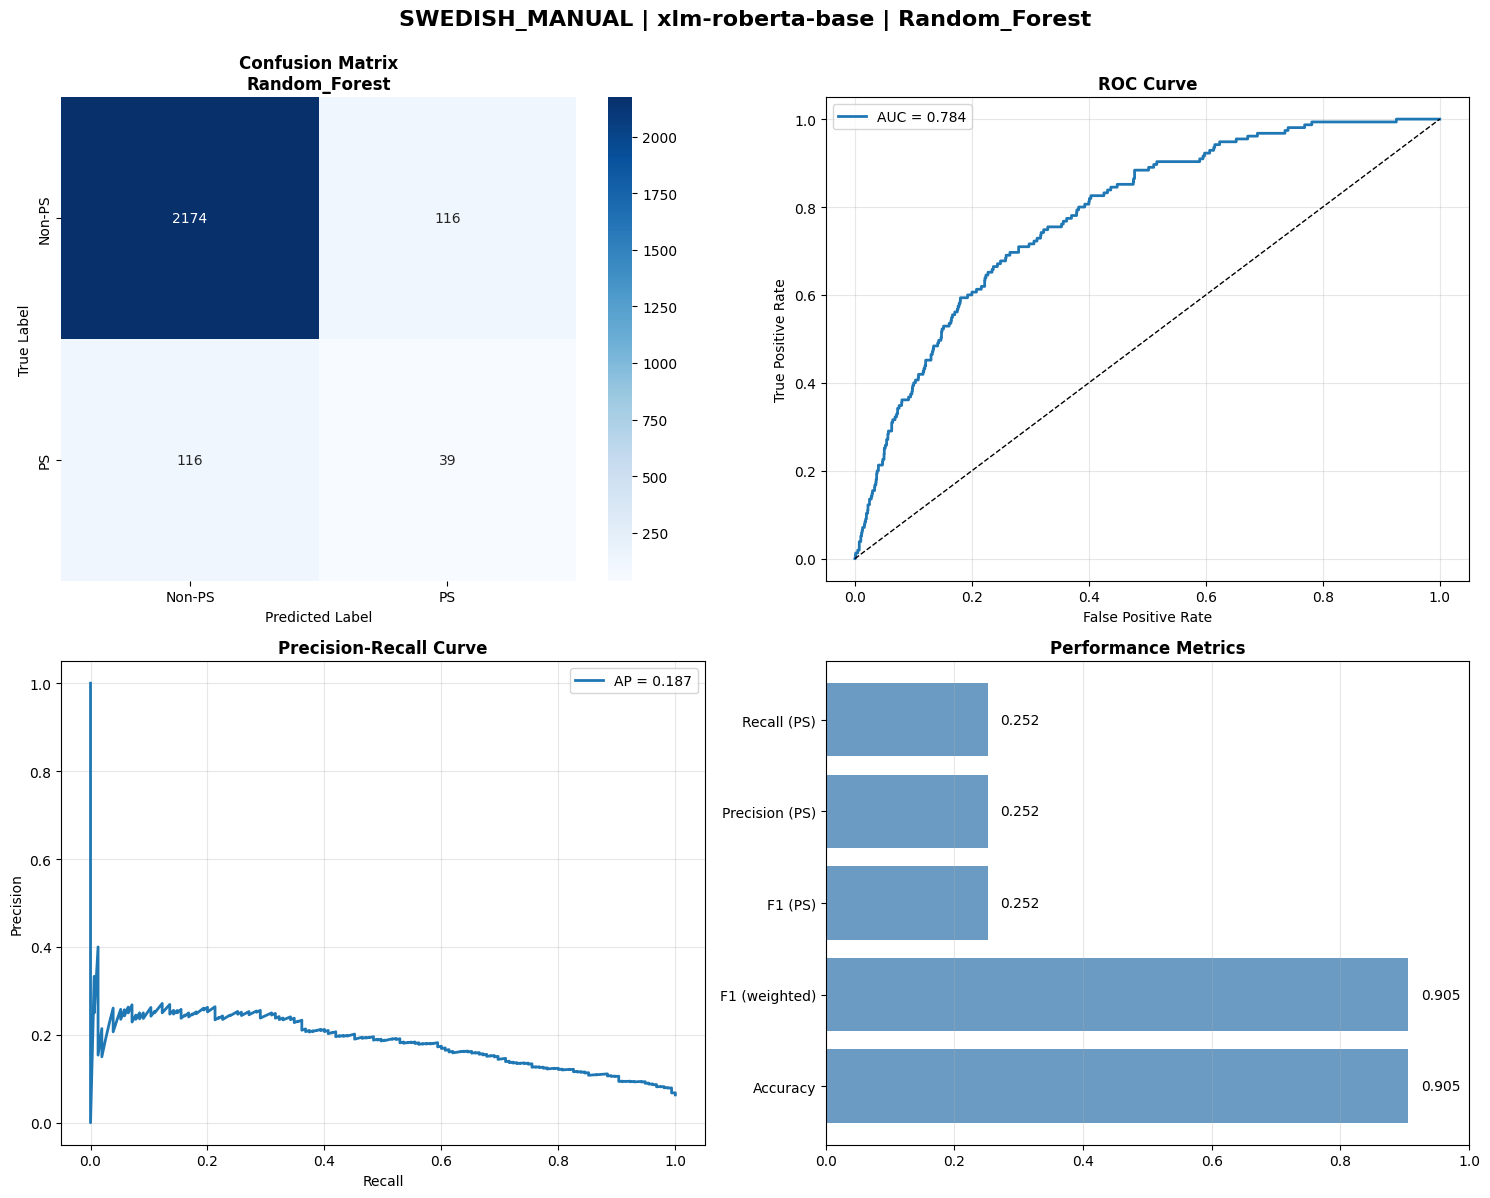


Detailed Report: SWEDISH_MANUAL | xlm-roberta-base | XGBoost

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.9547    0.9380    0.9463      2290
    Process Safety     0.2718    0.3419    0.3029       155

          accuracy                         0.9002      2445
         macro avg     0.6132    0.6400    0.6246      2445
      weighted avg     0.9114    0.9002    0.9055      2445


 Visualization saved to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_4/eval_swedish_manual_xlm-roberta-base_XGBoost.png


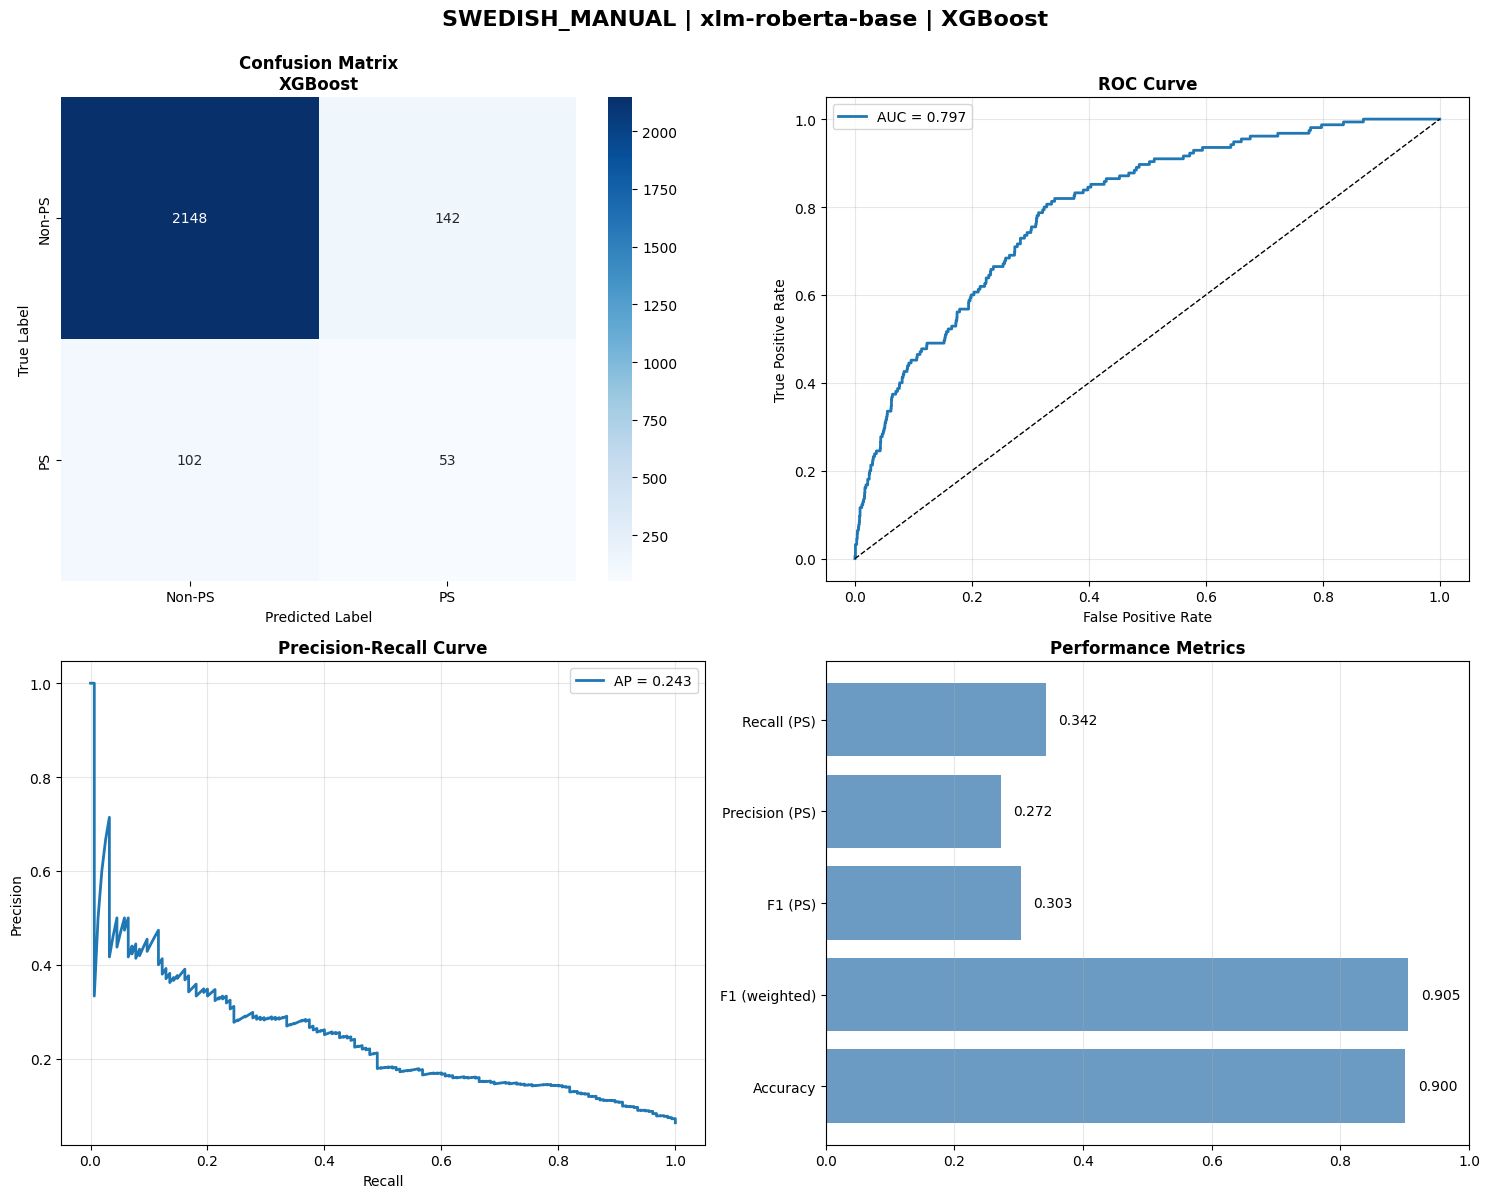


Detailed Report: SWEDISH_MANUAL | xlm-roberta-base | LightGBM

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.9544    0.9419    0.9481      2290
    Process Safety     0.2811    0.3355    0.3059       155

          accuracy                         0.9035      2445
         macro avg     0.6178    0.6387    0.6270      2445
      weighted avg     0.9117    0.9035    0.9074      2445


 Visualization saved to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_4/eval_swedish_manual_xlm-roberta-base_LightGBM.png


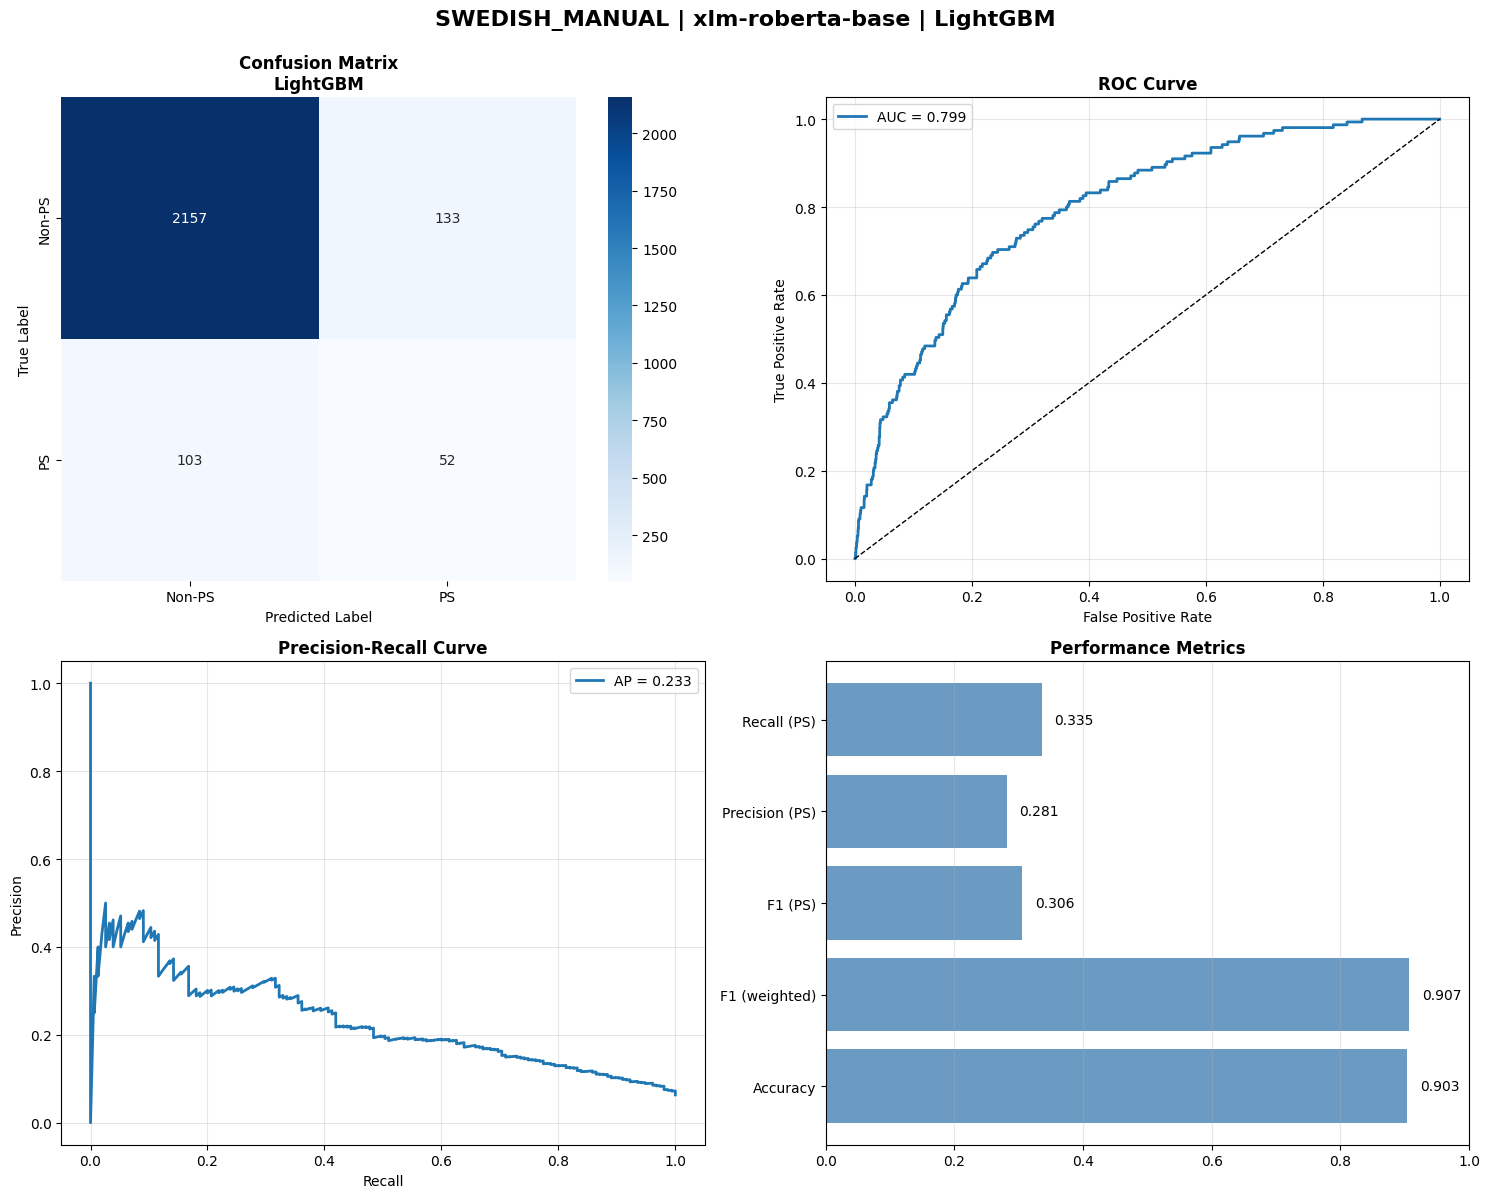


Detailed Report: SWEDISH_MANUAL | xlm-roberta-base | Voting_Ensemble

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.9543    0.9393    0.9467      2290
    Process Safety     0.2723    0.3355    0.3006       155

          accuracy                         0.9010      2445
         macro avg     0.6133    0.6374    0.6237      2445
      weighted avg     0.9111    0.9010    0.9058      2445


 Visualization saved to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_4/eval_swedish_manual_xlm-roberta-base_Voting_Ensemble.png


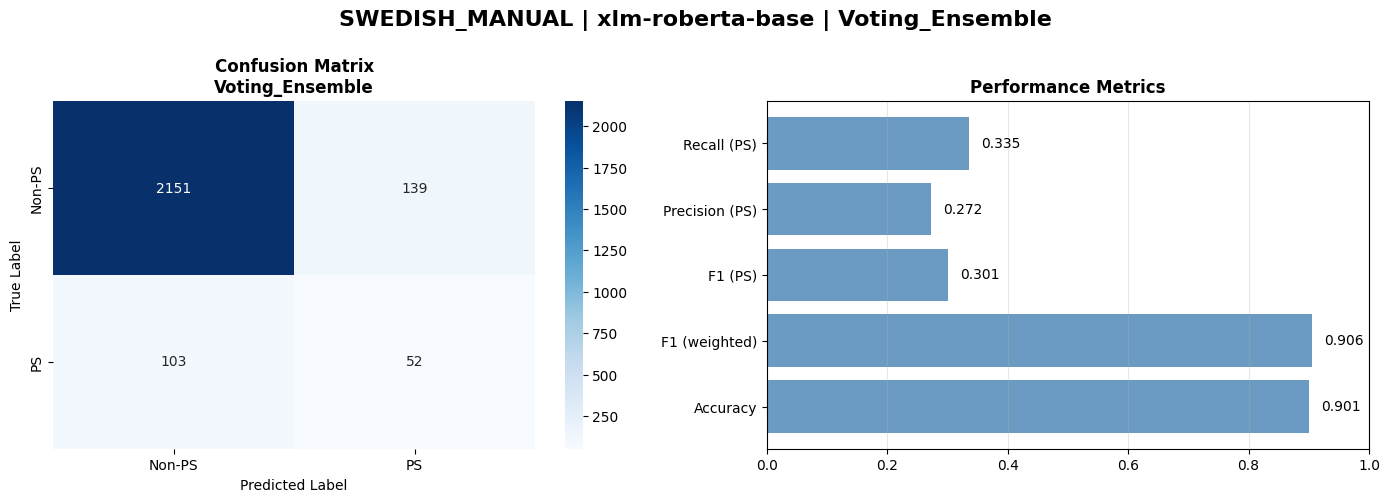


################################################################################
 Training Pipeline: DUTCH_MANUAL
################################################################################
Model: xlm-roberta-base
Pooling: mean
SMOTE used: True
Feature scaling: True

Training Multiple Classifiers: DUTCH_MANUAL
Training samples: 1907
Test samples: 398
Features: 768

 Training SVM with hyperparameter tuning...

 Training Random Forest...

 Training XGBoost...

 Training LightGBM...

────────────────────────────────────────────────────────────
 SVM
────────────────────────────────────────────────────────────
   Best parameters: {'C': 10, 'class_weight': 'balanced', 'max_iter': 10000}
   Best CV score: 0.7735
   Accuracy: 0.6784
   F1 (weighted): 0.6844
   F1 (Process Safety): 0.4961
   ROC AUC: 0.6948
   Training time: 16.58s

────────────────────────────────────────────────────────────
 Random_Forest
────────────────────────────────────────────────────────────
   Accuracy: 0.7739
 

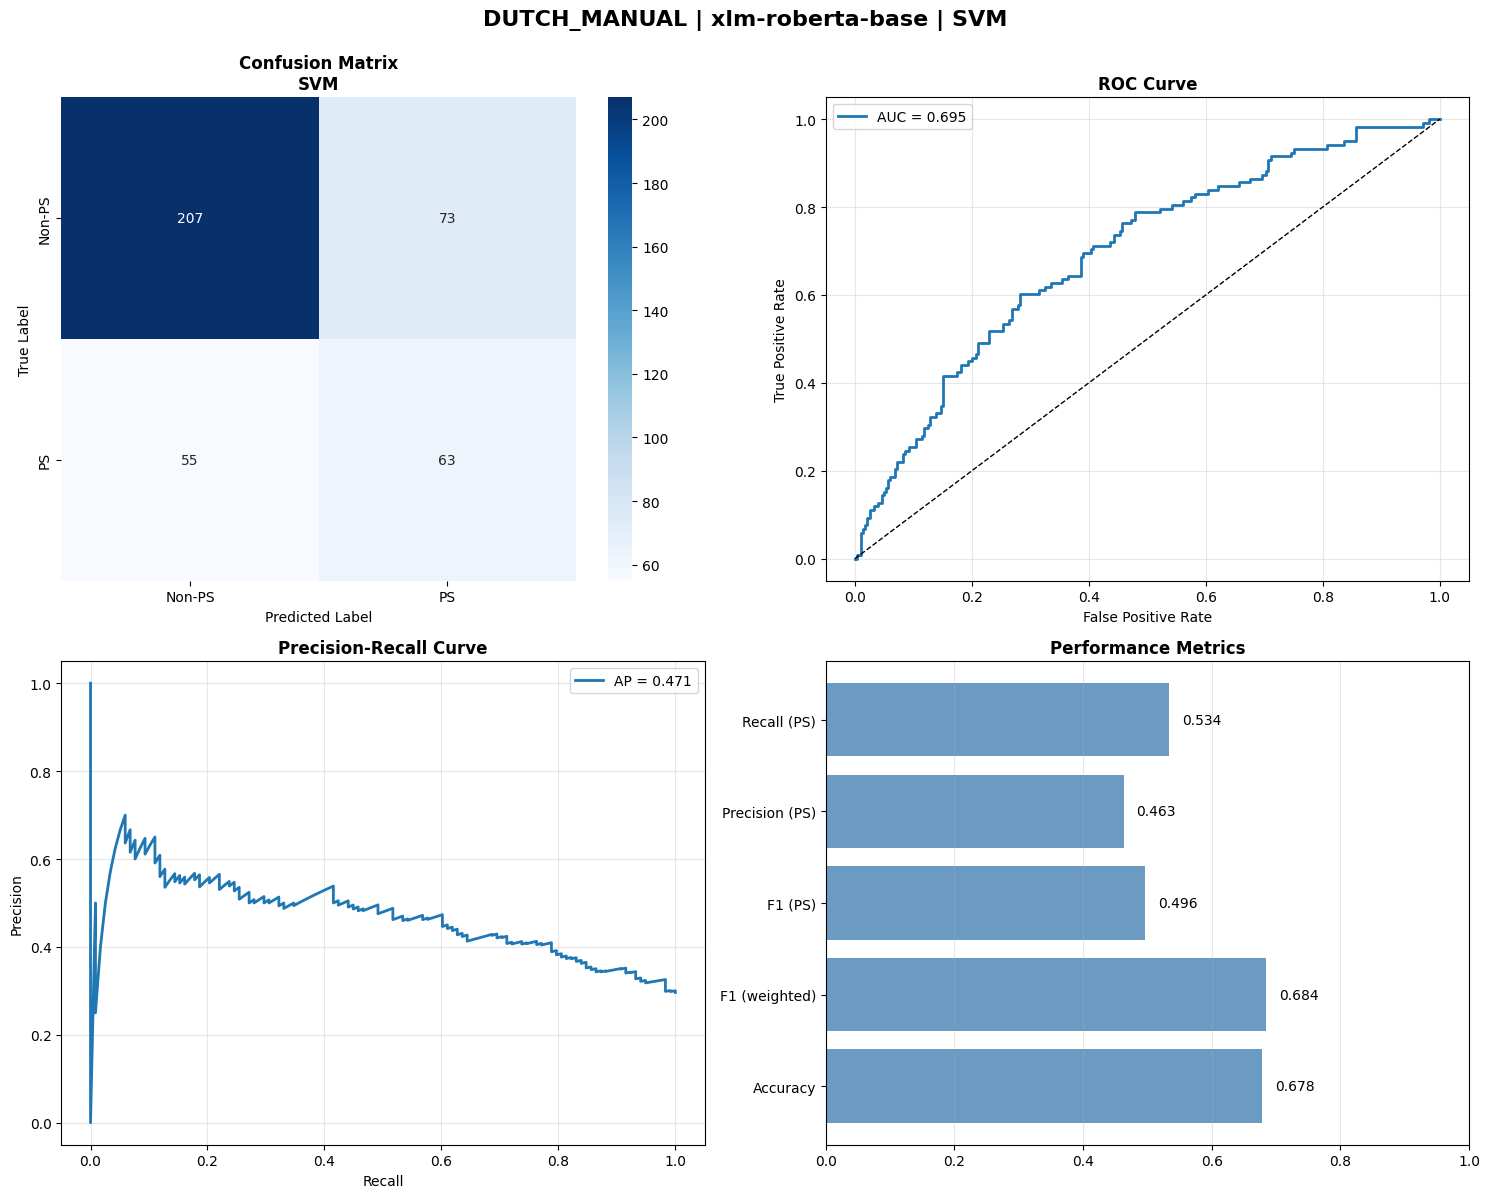


Detailed Report: DUTCH_MANUAL | xlm-roberta-base | Random_Forest

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.7914    0.9214    0.8515       280
    Process Safety     0.6944    0.4237    0.5263       118

          accuracy                         0.7739       398
         macro avg     0.7429    0.6726    0.6889       398
      weighted avg     0.7627    0.7739    0.7551       398


 Visualization saved to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_4/eval_dutch_manual_xlm-roberta-base_Random_Forest.png


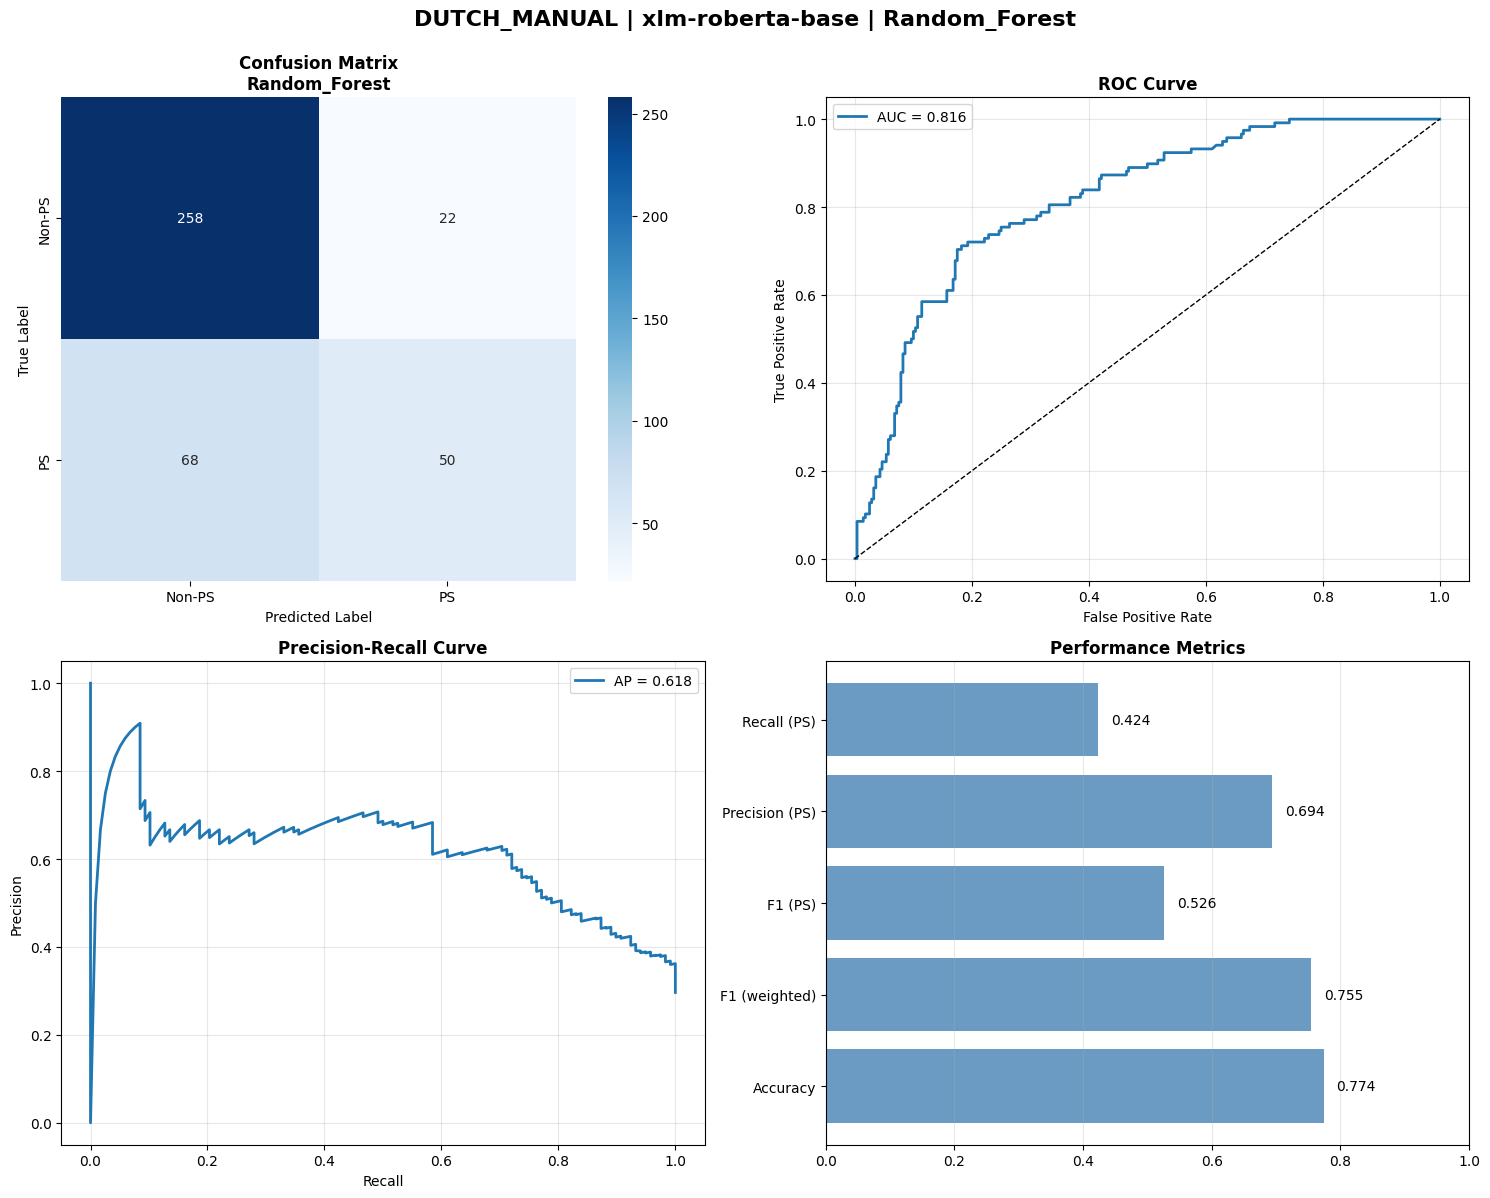


Detailed Report: DUTCH_MANUAL | xlm-roberta-base | XGBoost

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.8155    0.9000    0.8557       280
    Process Safety     0.6854    0.5169    0.5894       118

          accuracy                         0.7864       398
         macro avg     0.7505    0.7085    0.7225       398
      weighted avg     0.7769    0.7864    0.7767       398


 Visualization saved to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_4/eval_dutch_manual_xlm-roberta-base_XGBoost.png


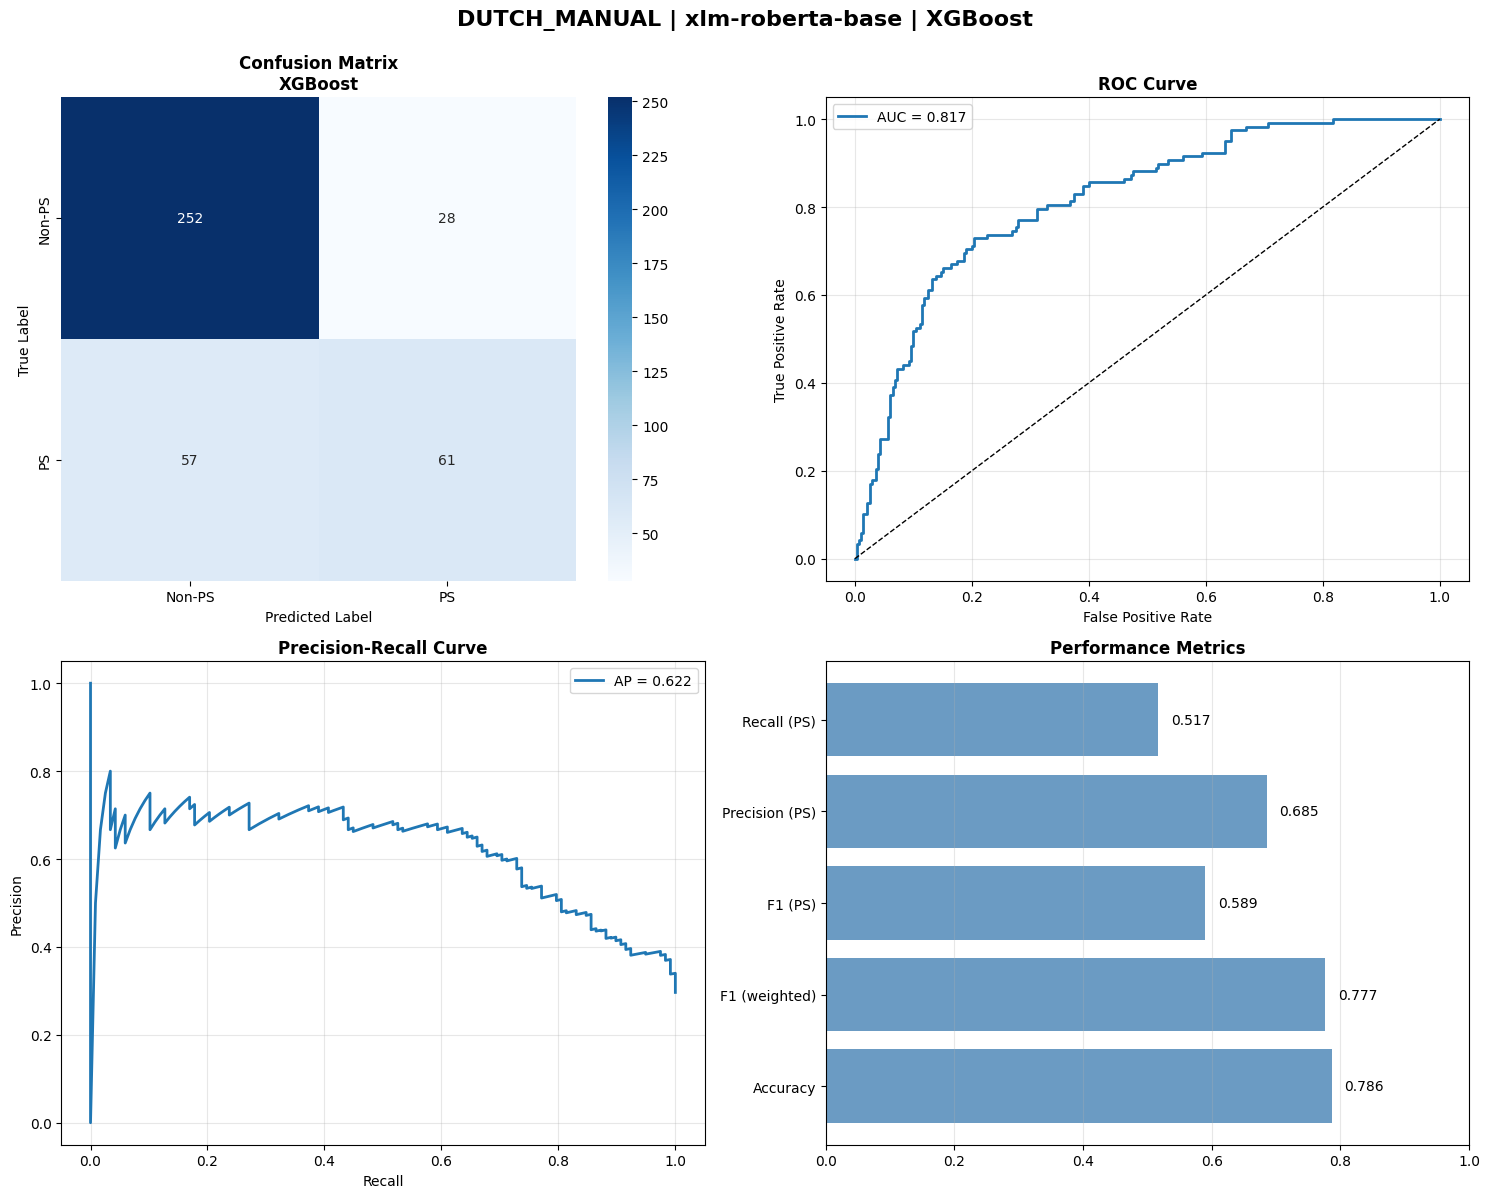


Detailed Report: DUTCH_MANUAL | xlm-roberta-base | LightGBM

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.8065    0.8929    0.8475       280
    Process Safety     0.6591    0.4915    0.5631       118

          accuracy                         0.7739       398
         macro avg     0.7328    0.6922    0.7053       398
      weighted avg     0.7628    0.7739    0.7632       398


 Visualization saved to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_4/eval_dutch_manual_xlm-roberta-base_LightGBM.png


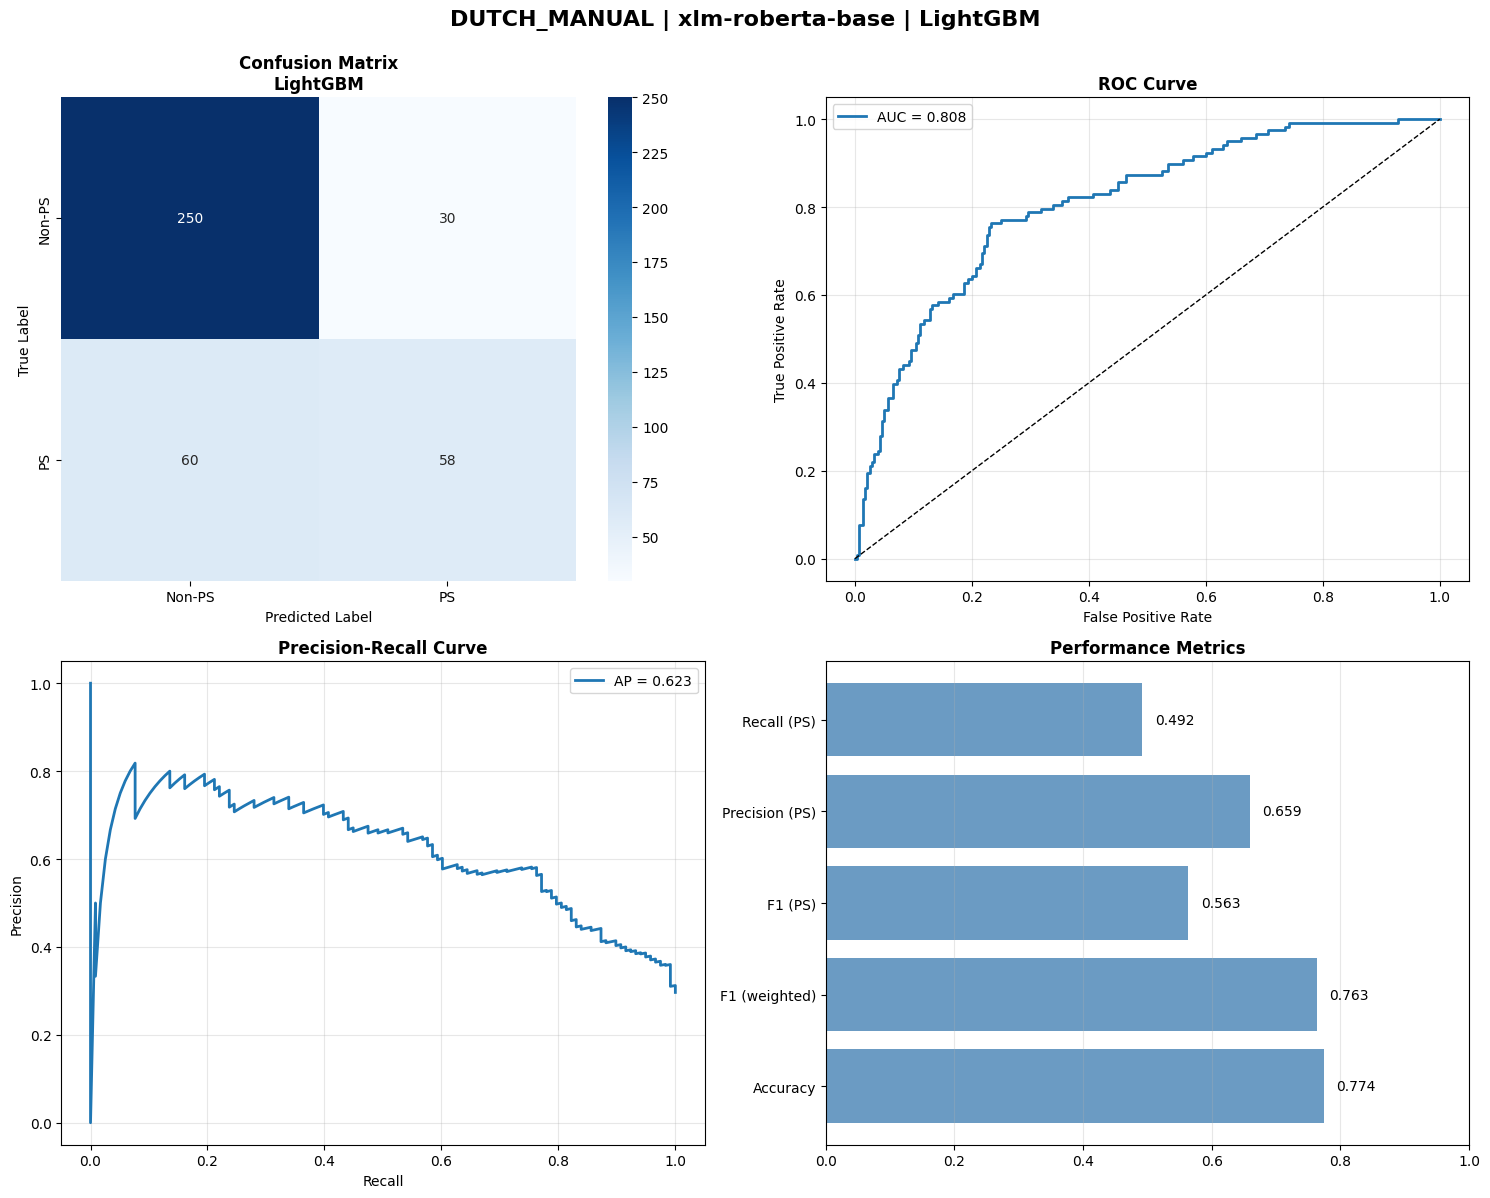


Detailed Report: DUTCH_MANUAL | xlm-roberta-base | Voting_Ensemble

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.8133    0.9179    0.8624       280
    Process Safety     0.7195    0.5000    0.5900       118

          accuracy                         0.7940       398
         macro avg     0.7664    0.7089    0.7262       398
      weighted avg     0.7855    0.7940    0.7816       398


 Visualization saved to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_4/eval_dutch_manual_xlm-roberta-base_Voting_Ensemble.png


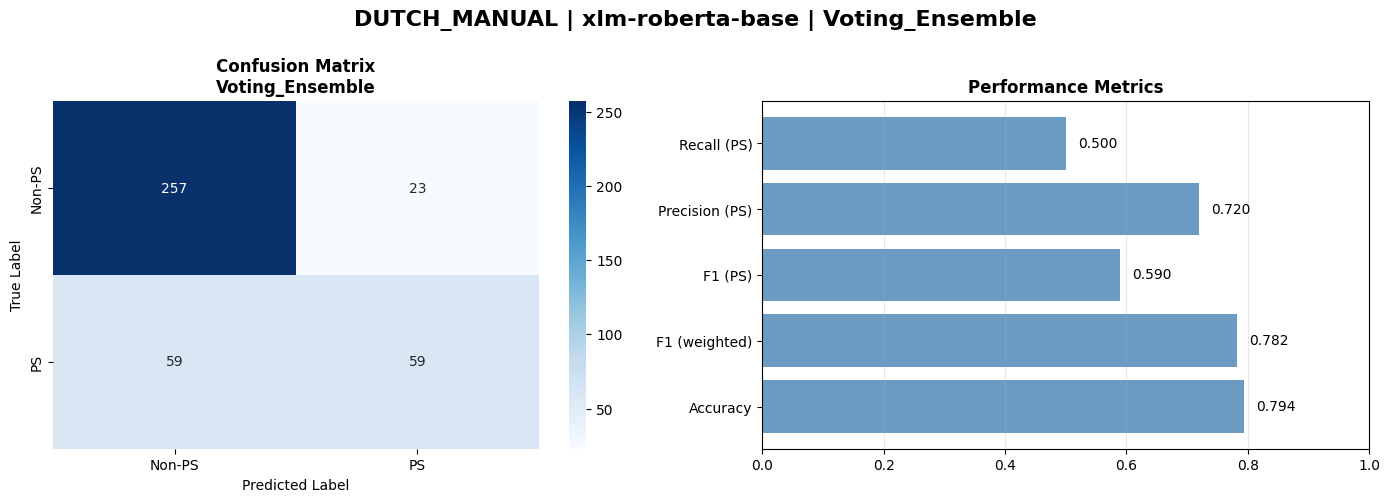


 Completed processing xlm-roberta-base

################################################################################
 MODEL: paraphrase-multilingual-mpnet-base-v2
################################################################################

 Initializing paraphrase-multilingual-mpnet-base-v2...
 Model loaded successfully!

 PHASE 1: GENERATING EMBEDDINGS - paraphrase-multilingual-mpnet-base-v2

Processing: ENGLISH_MANUAL
Model: paraphrase-multilingual-mpnet-base-v2
Dataset shape: (4713, 36)

Case type distribution:
CASE_TYPE
Safety                              2553
Process Safety                      1409
Environment                          454
Asset and Reputation damage/loss     145
Operational loss                     123
Physical Security                     14
Information Security                  12
Not classified                         3
Name: count, dtype: int64

Class balance:
binary_label
0    0.70104
1    0.29896
Name: proportion, dtype: float64

Applying advanced

Generating embeddings: 100%|██████████| 393/393 [01:22<00:00,  4.74it/s]



Training set: (3770, 768)
Test set: (943, 768)

 Applying SMOTE for class balancing...
   Strategy: Oversample minority to 70.0% of majority
   Original training size: 3770
   Balanced training size: 4493
   Original class distribution: [2643 1127]
   Balanced class distribution: [2643 1850]

 Applying feature scaling...

Embeddings saved!
Location: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_4/paraphrase-multilingual-mpnet-base-v2/english_manual_paraphrase-multilingual-mpnet-base-v2_embeddings.pkl
Size: 44.41 MB

Checkpoint saved: 9 combinations processed
 Progress: 9/40

Processing: GERMAN_MANUAL
Model: paraphrase-multilingual-mpnet-base-v2
Dataset shape: (14951, 36)

Case type distribution:
CASE_TYPE
Safety                              11506
Process Safety                       1661
Environment                          1038
Asset and Reputation damage/loss      518
Information Security                  156
Operational loss                       

Generating embeddings: 100%|██████████| 1246/1246 [03:18<00:00,  6.27it/s]



Training set: (11960, 768)
Test set: (2991, 768)

 Applying SMOTE for class balancing...
   Strategy: Oversample minority to 70.0% of majority
   Original training size: 11960
   Balanced training size: 18072
   Original class distribution: [10631  1329]
   Balanced class distribution: [10631  7441]

 Training set too large (18072 samples)
   Subsampling to 6000 for SVM efficiency...
   Subsampled training set: (6000, 768)

 Applying feature scaling...

Embeddings saved!
Location: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_4/paraphrase-multilingual-mpnet-base-v2/german_manual_paraphrase-multilingual-mpnet-base-v2_embeddings.pkl
Size: 126.49 MB

Checkpoint saved: 10 combinations processed
 Progress: 10/40

Processing: SWEDISH_MANUAL
Model: paraphrase-multilingual-mpnet-base-v2
Dataset shape: (12224, 36)

Case type distribution:
CASE_TYPE
Safety                              9974
Process Safety                       773
Environment                   

Generating embeddings: 100%|██████████| 1019/1019 [01:13<00:00, 13.85it/s]



Training set: (9779, 768)
Test set: (2445, 768)

 Applying SMOTE for class balancing...
   Strategy: Oversample minority to 70.0% of majority
   Original training size: 9779
   Balanced training size: 15573
   Original class distribution: [9161  618]
   Balanced class distribution: [9161 6412]

 Training set too large (15573 samples)
   Subsampling to 6000 for SVM efficiency...
   Subsampled training set: (6000, 768)

 Applying feature scaling...

Embeddings saved!
Location: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_4/paraphrase-multilingual-mpnet-base-v2/swedish_manual_paraphrase-multilingual-mpnet-base-v2_embeddings.pkl
Size: 107.54 MB

Checkpoint saved: 11 combinations processed
 Progress: 11/40

Processing: DUTCH_MANUAL
Model: paraphrase-multilingual-mpnet-base-v2
Dataset shape: (1990, 36)

Case type distribution:
CASE_TYPE
Safety                              649
Process Safety                      588
Environment                         536


Generating embeddings: 100%|██████████| 166/166 [00:51<00:00,  3.23it/s]


Training set: (1592, 768)
Test set: (398, 768)

 Applying SMOTE for class balancing...
   Strategy: Oversample minority to 70.0% of majority
   Original training size: 1592
   Balanced training size: 1907
   Original class distribution: [1122  470]
   Balanced class distribution: [1122  785]

 Applying feature scaling...

Embeddings saved!
Location: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_4/paraphrase-multilingual-mpnet-base-v2/dutch_manual_paraphrase-multilingual-mpnet-base-v2_embeddings.pkl
Size: 18.93 MB

Checkpoint saved: 12 combinations processed
 Progress: 12/40

 PHASE 2: TRAINING CLASSIFIERS - paraphrase-multilingual-mpnet-base-v2

################################################################################
 Training Pipeline: ENGLISH_MANUAL
################################################################################
Model: paraphrase-multilingual-mpnet-base-v2
Pooling: mean
SMOTE used: True
Feature scaling: True

Training Multi

   Best parameters: {'C': 0.1, 'class_weight': 'balanced', 'max_iter': 10000}
   Best CV score: 0.8004
   Accuracy: 0.7943
   F1 (weighted): 0.7986
   F1 (Process Safety): 0.6840
   ROC AUC: 0.8475
   Training time: 100.97s

────────────────────────────────────────────────────────────
 Random_Forest
────────────────────────────────────────────────────────────
   Accuracy: 0.8282
   F1 (weighted): 0.8212
   F1 (Process Safety): 0.6760
   ROC AUC: 0.8580
   Training time: 2.04s

────────────────────────────────────────────────────────────
 XGBoost
────────────────────────────────────────────────────────────
   Accuracy: 0.8112
   F1 (weighted): 0.8085
   F1 (Process Safety): 0.6691
   ROC AUC: 0.8710
   Training time: 4.84s

────────────────────────────────────────────────────────────
 LightGBM
────────────────────────────────────────────────────────────
   Accuracy: 0.8208
   F1 (weighted): 0.8179
   F1 (Process Safety): 0.6841
   ROC AUC: 0.8686
   Training time: 2.03s

───────────────

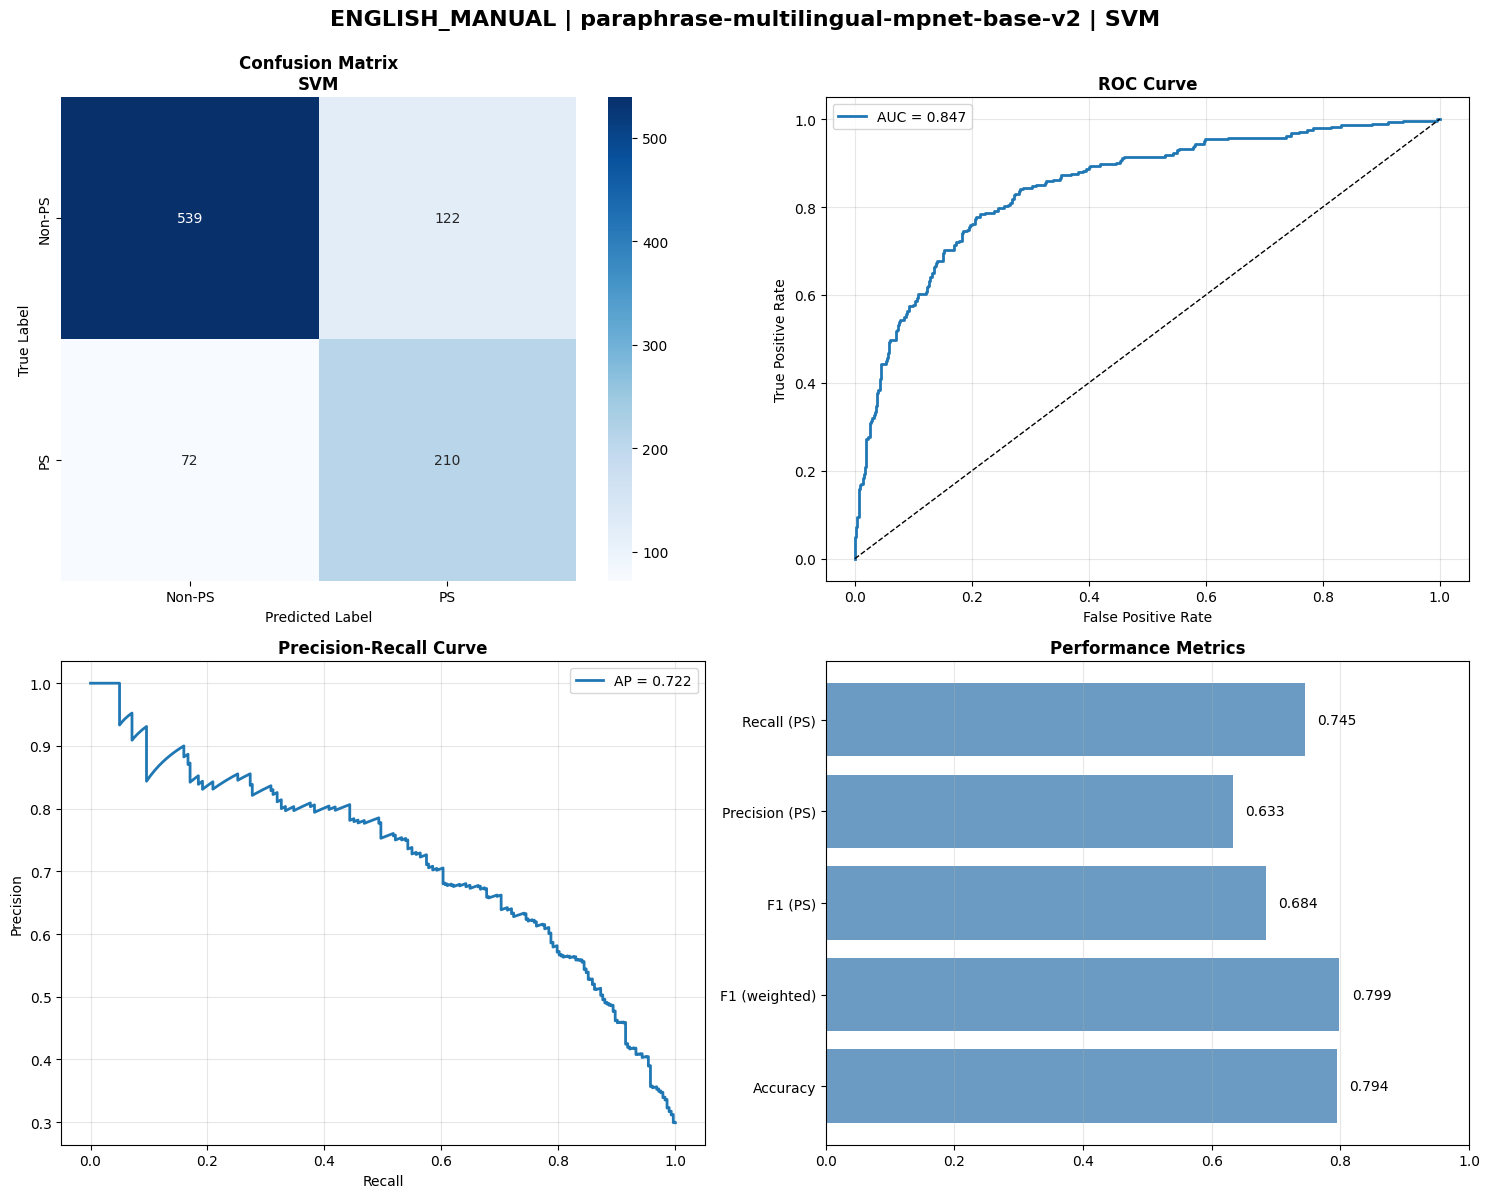


Detailed Report: ENGLISH_MANUAL | paraphrase-multilingual-mpnet-base-v2 | Random_Forest

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.8441    0.9259    0.8831       661
    Process Safety     0.7752    0.5993    0.6760       282

          accuracy                         0.8282       943
         macro avg     0.8097    0.7626    0.7796       943
      weighted avg     0.8235    0.8282    0.8212       943


 Visualization saved to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_4/eval_english_manual_paraphrase-multilingual-mpnet-base-v2_Random_Forest.png


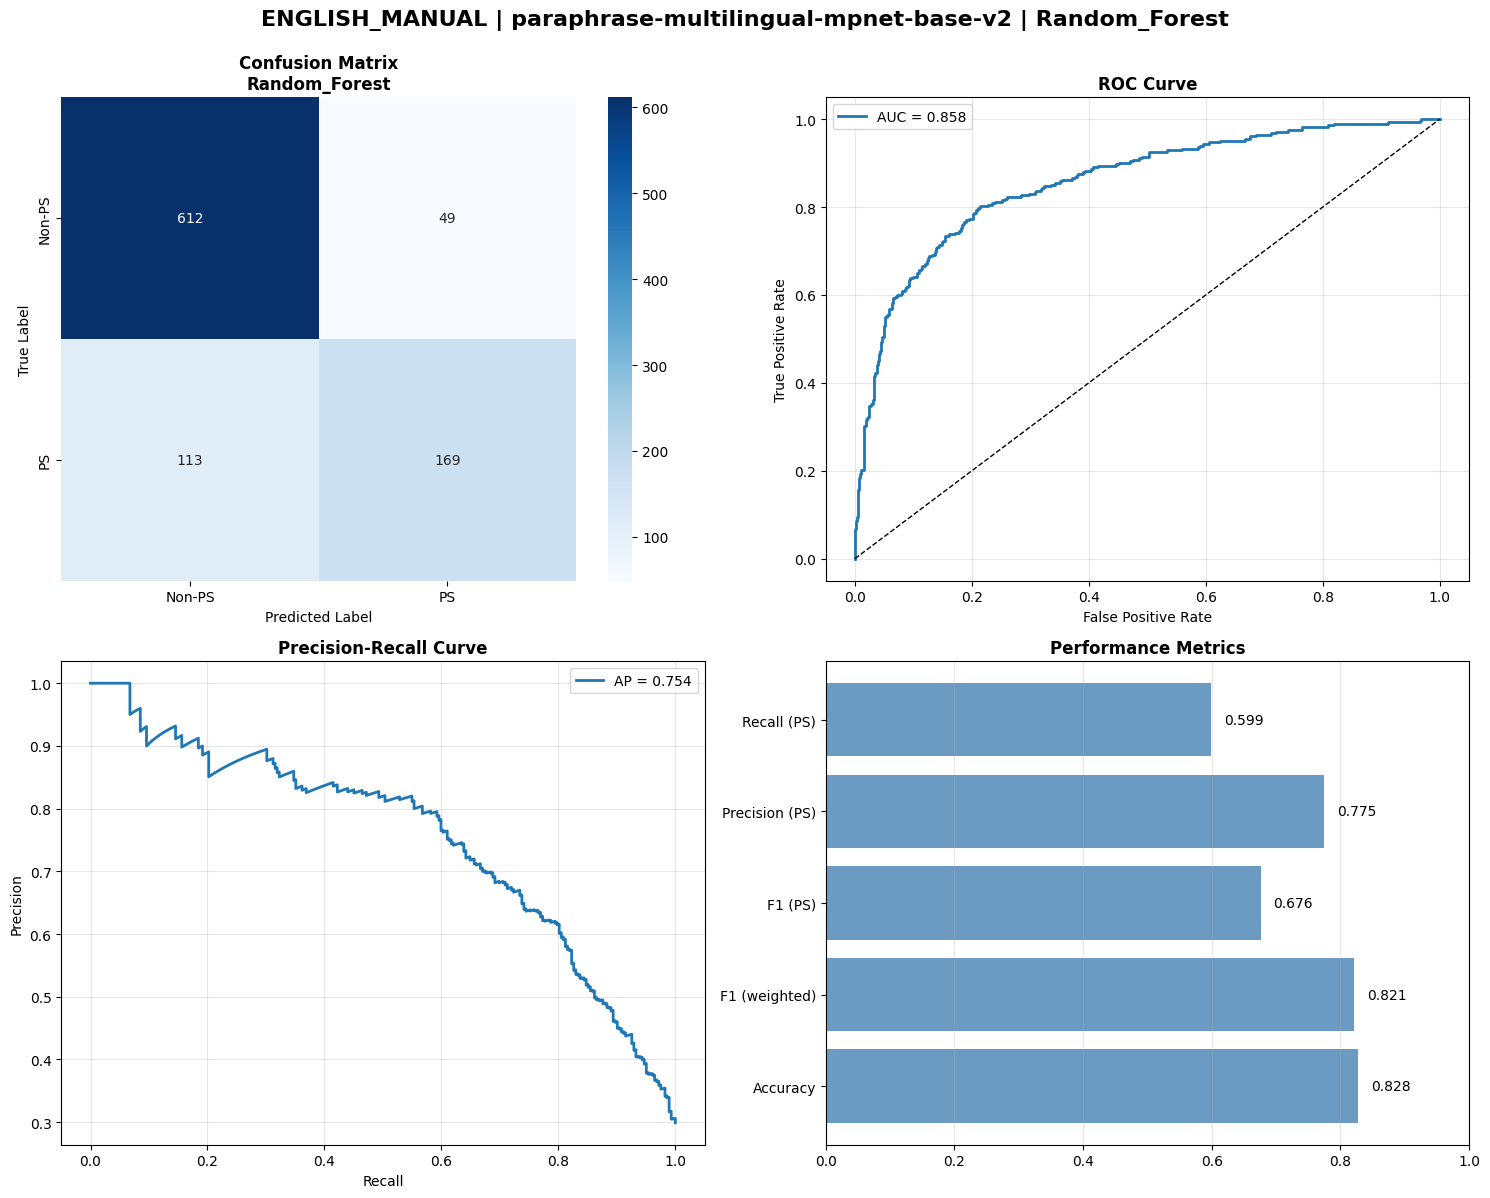


Detailed Report: ENGLISH_MANUAL | paraphrase-multilingual-mpnet-base-v2 | XGBoost

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.8515    0.8850    0.8680       661
    Process Safety     0.7031    0.6383    0.6691       282

          accuracy                         0.8112       943
         macro avg     0.7773    0.7617    0.7685       943
      weighted avg     0.8071    0.8112    0.8085       943


 Visualization saved to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_4/eval_english_manual_paraphrase-multilingual-mpnet-base-v2_XGBoost.png


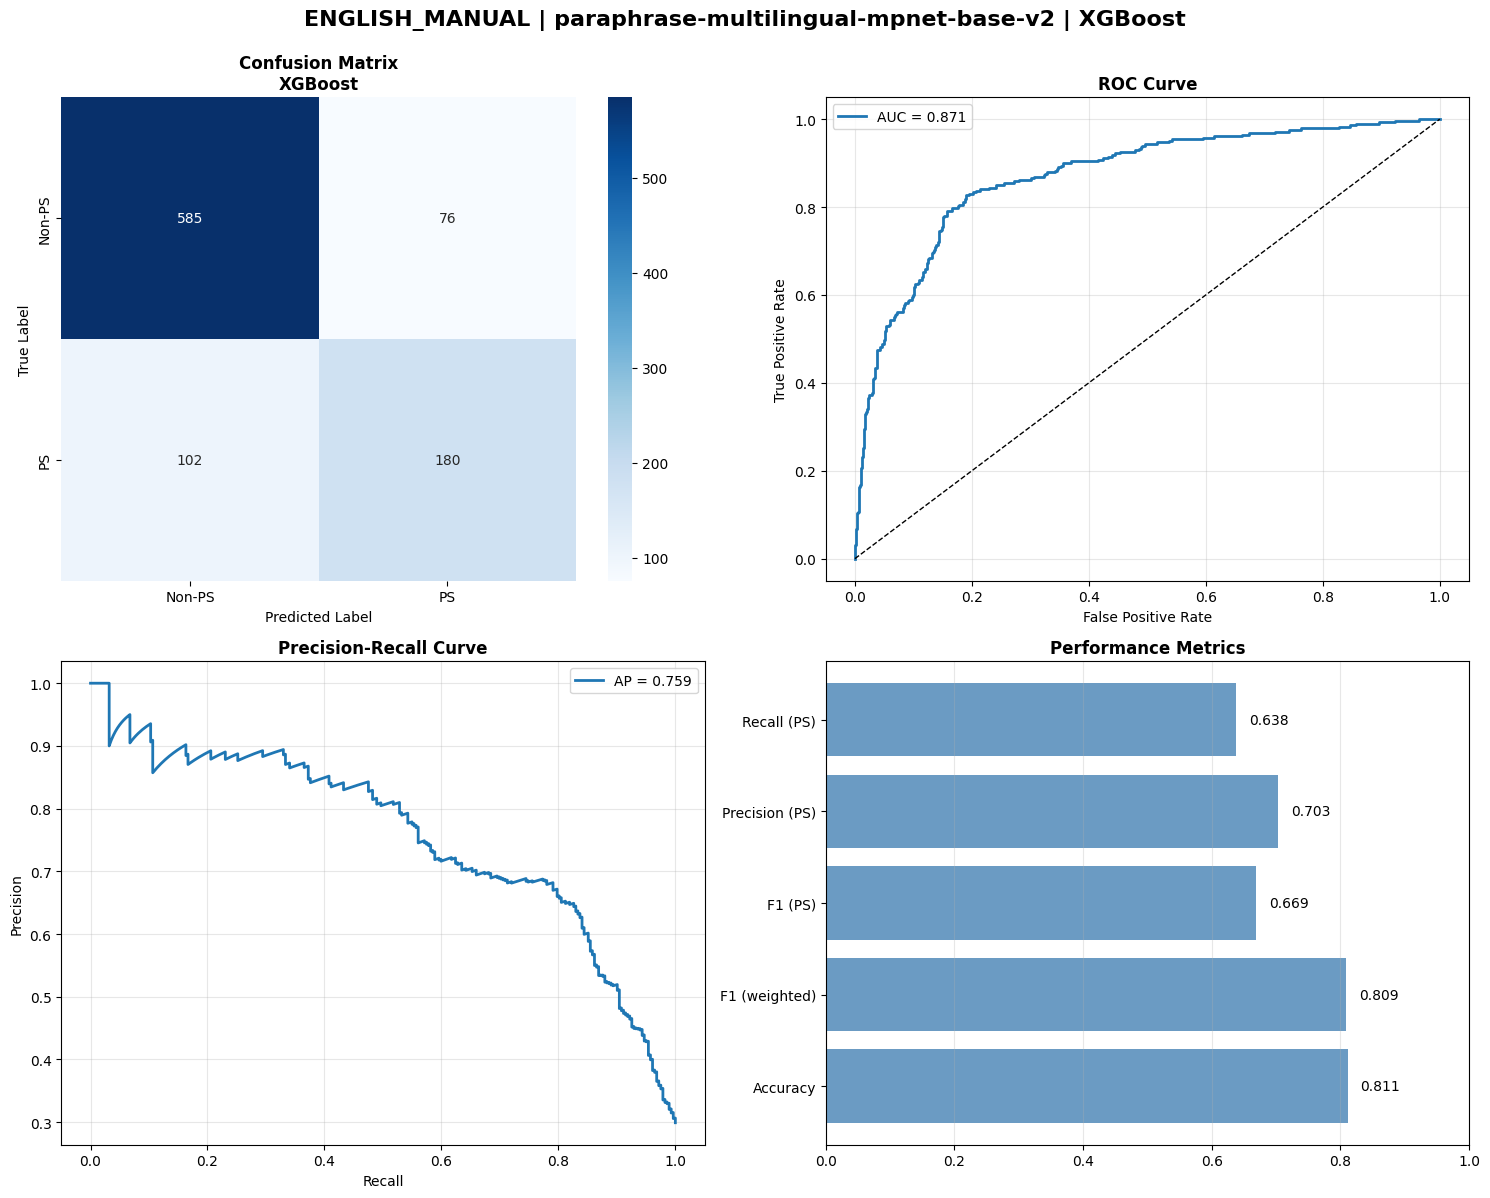


Detailed Report: ENGLISH_MANUAL | paraphrase-multilingual-mpnet-base-v2 | LightGBM

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.8565    0.8941    0.8749       661
    Process Safety     0.7233    0.6489    0.6841       282

          accuracy                         0.8208       943
         macro avg     0.7899    0.7715    0.7795       943
      weighted avg     0.8167    0.8208    0.8179       943


 Visualization saved to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_4/eval_english_manual_paraphrase-multilingual-mpnet-base-v2_LightGBM.png


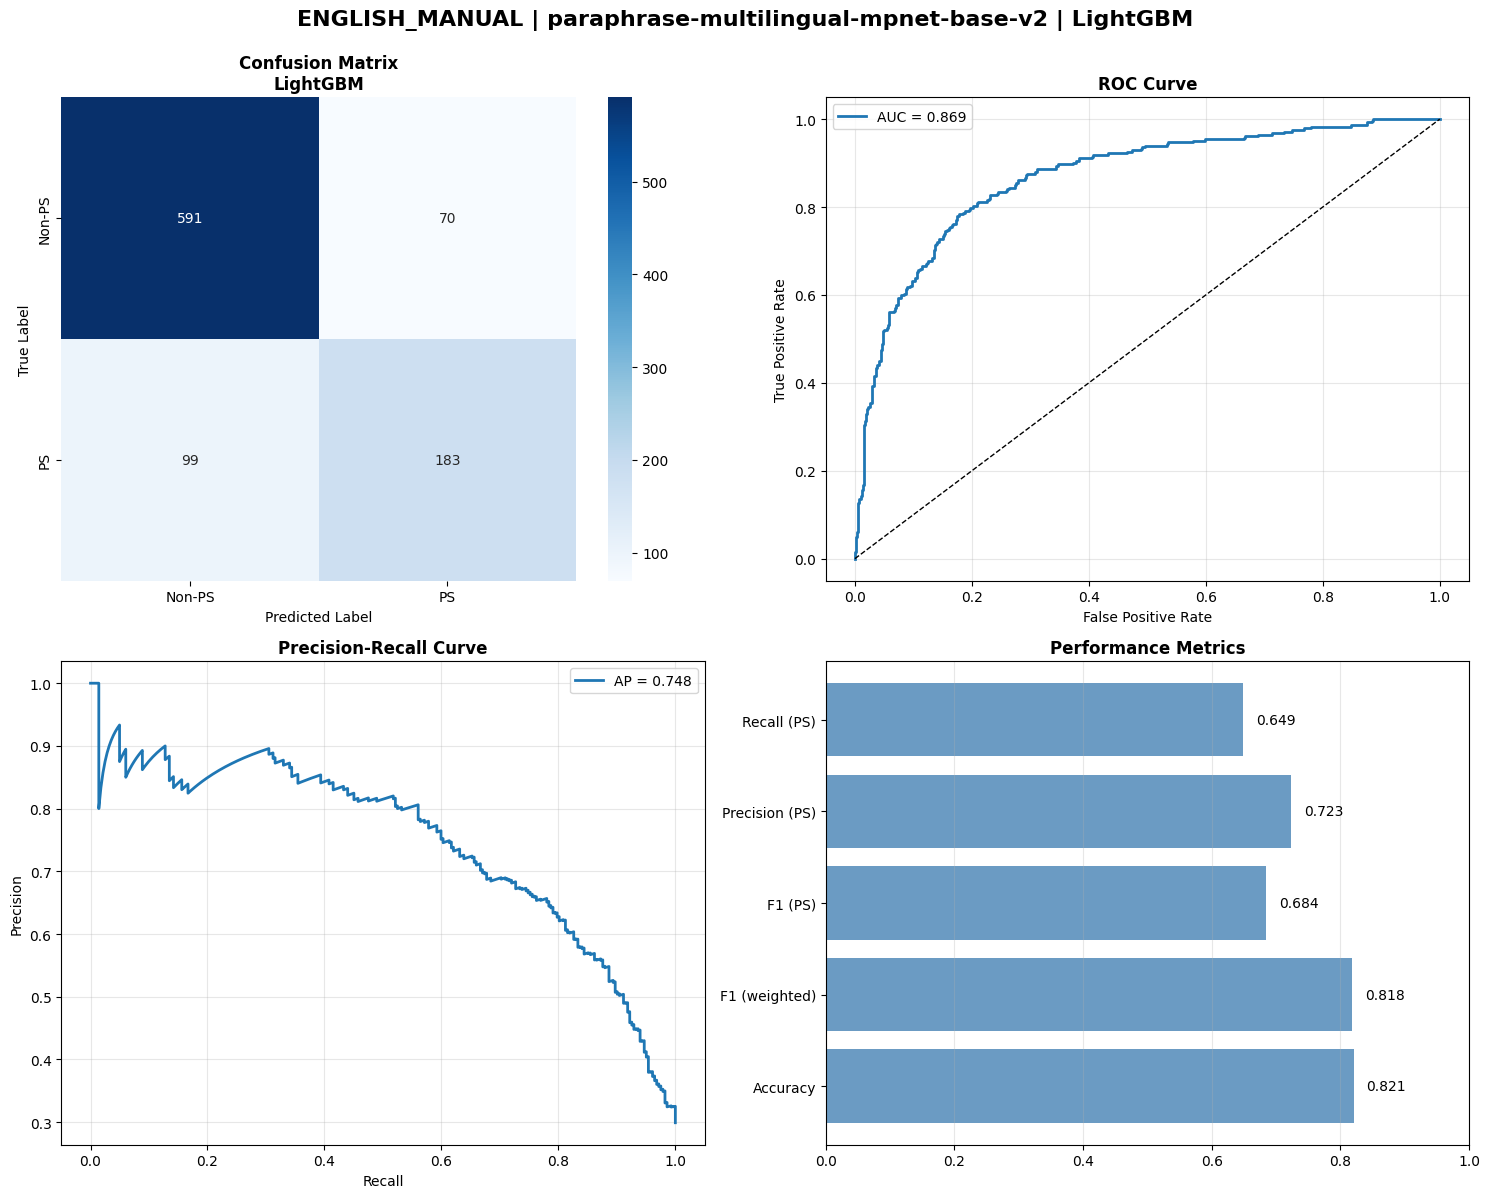


Detailed Report: ENGLISH_MANUAL | paraphrase-multilingual-mpnet-base-v2 | Voting_Ensemble

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.8606    0.9062    0.8828       661
    Process Safety     0.7490    0.6560    0.6994       282

          accuracy                         0.8314       943
         macro avg     0.8048    0.7811    0.7911       943
      weighted avg     0.8272    0.8314    0.8280       943


 Visualization saved to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_4/eval_english_manual_paraphrase-multilingual-mpnet-base-v2_Voting_Ensemble.png


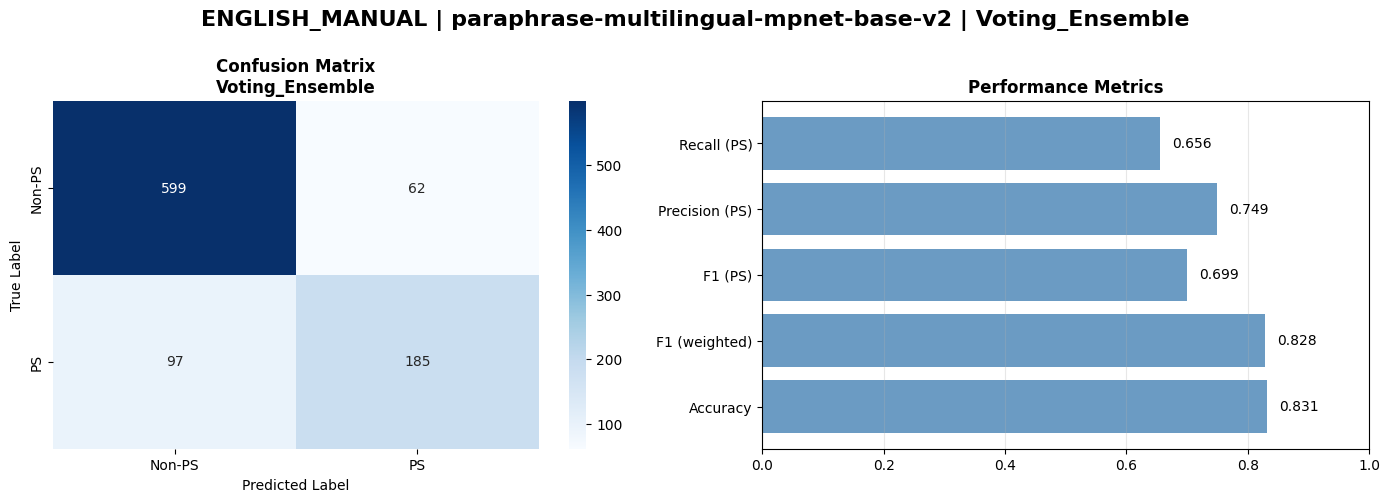


################################################################################
 Training Pipeline: GERMAN_MANUAL
################################################################################
Model: paraphrase-multilingual-mpnet-base-v2
Pooling: mean
SMOTE used: True
Feature scaling: True

Training Multiple Classifiers: GERMAN_MANUAL
Training samples: 6000
Test samples: 2991
Features: 768

 Training SVM with hyperparameter tuning...

 Training Random Forest...

 Training XGBoost...

 Training LightGBM...

────────────────────────────────────────────────────────────
 SVM
────────────────────────────────────────────────────────────
   Best parameters: {'C': 1, 'class_weight': 'balanced', 'max_iter': 10000}
   Best CV score: 0.8327
   Accuracy: 0.7656
   F1 (weighted): 0.8025
   F1 (Process Safety): 0.3769
   ROC AUC: 0.7784
   Training time: 146.49s

────────────────────────────────────────────────────────────
 Random_Forest
──────────────────────────────────────────────────────────

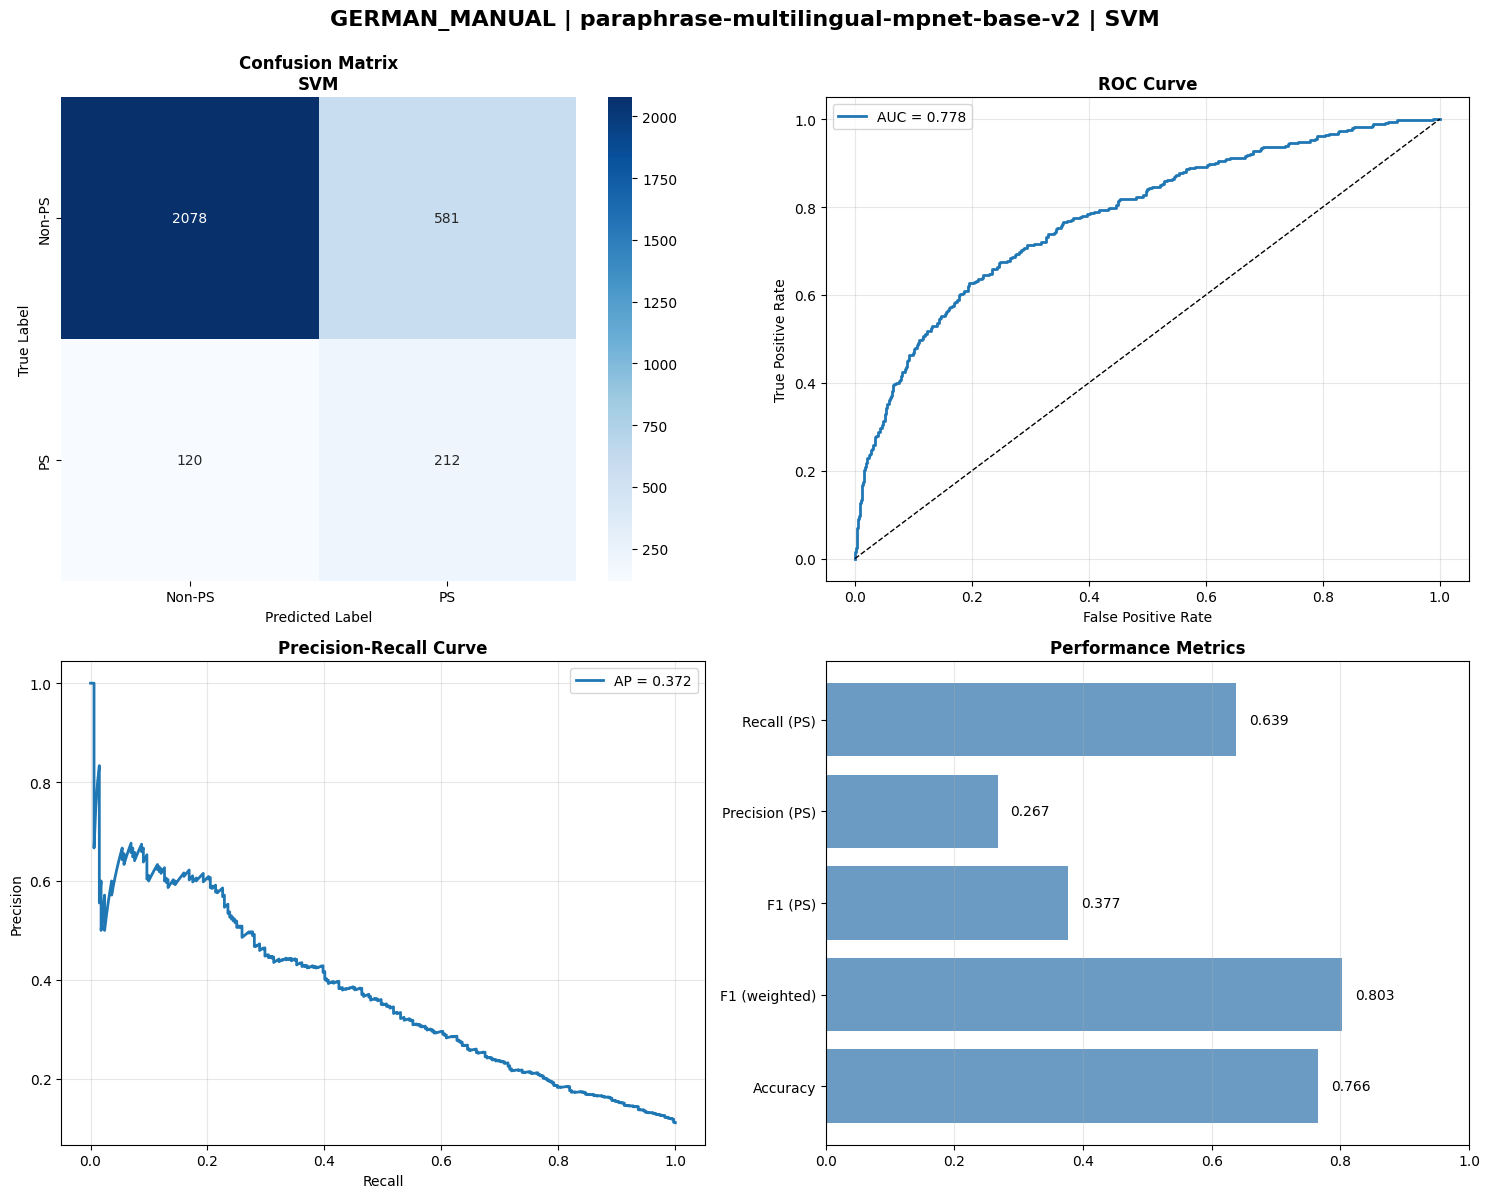


Detailed Report: GERMAN_MANUAL | paraphrase-multilingual-mpnet-base-v2 | Random_Forest

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.9243    0.9549    0.9393      2659
    Process Safety     0.5082    0.3735    0.4306       332

          accuracy                         0.8903      2991
         macro avg     0.7162    0.6642    0.6849      2991
      weighted avg     0.8781    0.8903    0.8829      2991


 Visualization saved to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_4/eval_german_manual_paraphrase-multilingual-mpnet-base-v2_Random_Forest.png


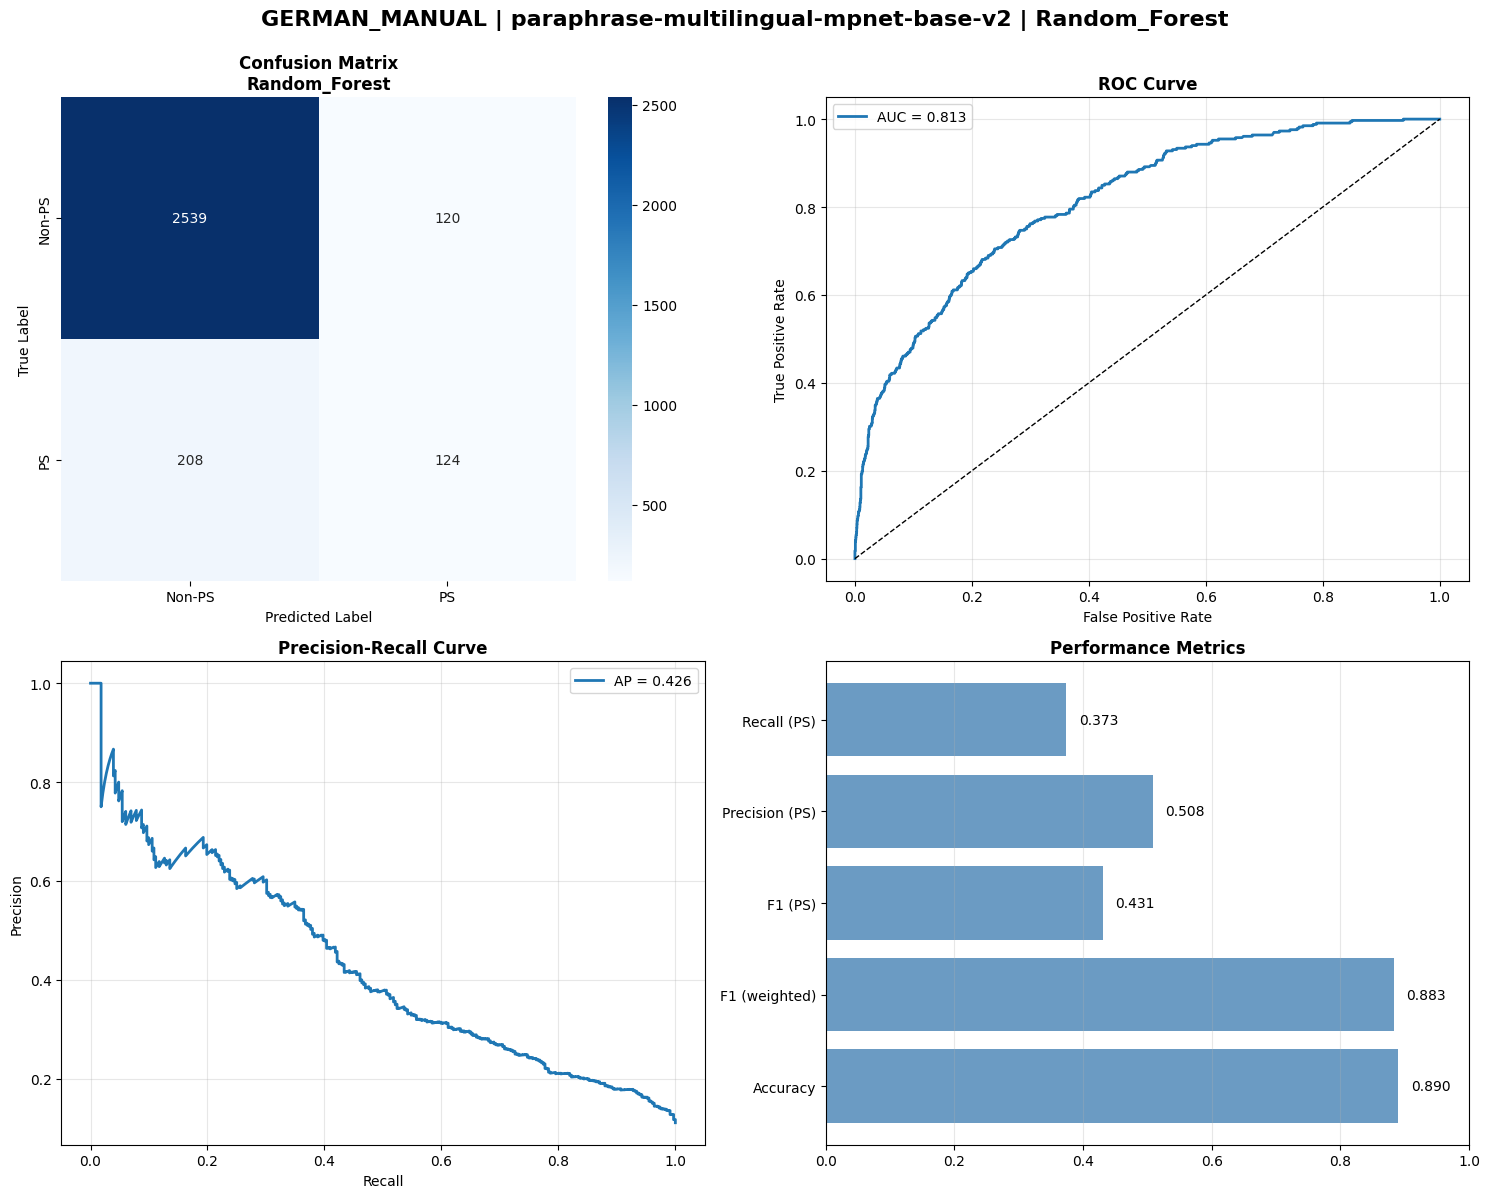


Detailed Report: GERMAN_MANUAL | paraphrase-multilingual-mpnet-base-v2 | XGBoost

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.9342    0.9240    0.9291      2659
    Process Safety     0.4404    0.4789    0.4589       332

          accuracy                         0.8746      2991
         macro avg     0.6873    0.7015    0.6940      2991
      weighted avg     0.8794    0.8746    0.8769      2991


 Visualization saved to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_4/eval_german_manual_paraphrase-multilingual-mpnet-base-v2_XGBoost.png


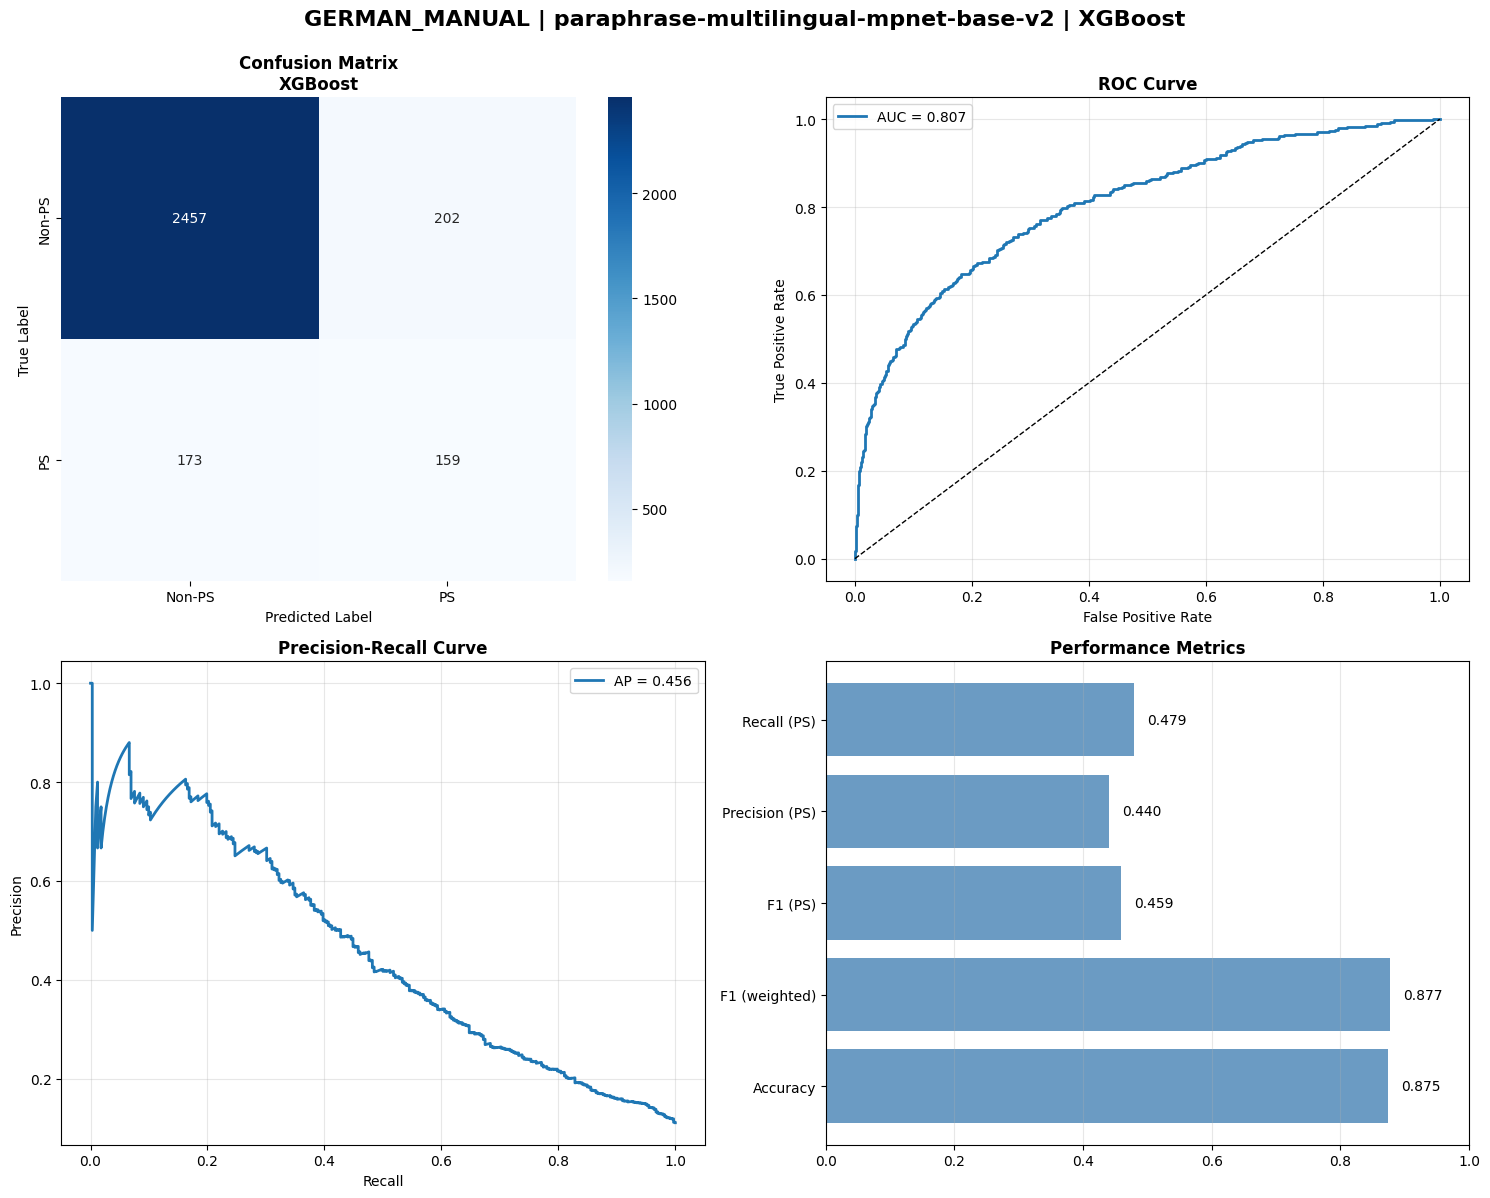


Detailed Report: GERMAN_MANUAL | paraphrase-multilingual-mpnet-base-v2 | LightGBM

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.9357    0.9146    0.9251      2659
    Process Safety     0.4209    0.4970    0.4558       332

          accuracy                         0.8683      2991
         macro avg     0.6783    0.7058    0.6904      2991
      weighted avg     0.8786    0.8683    0.8730      2991


 Visualization saved to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_4/eval_german_manual_paraphrase-multilingual-mpnet-base-v2_LightGBM.png


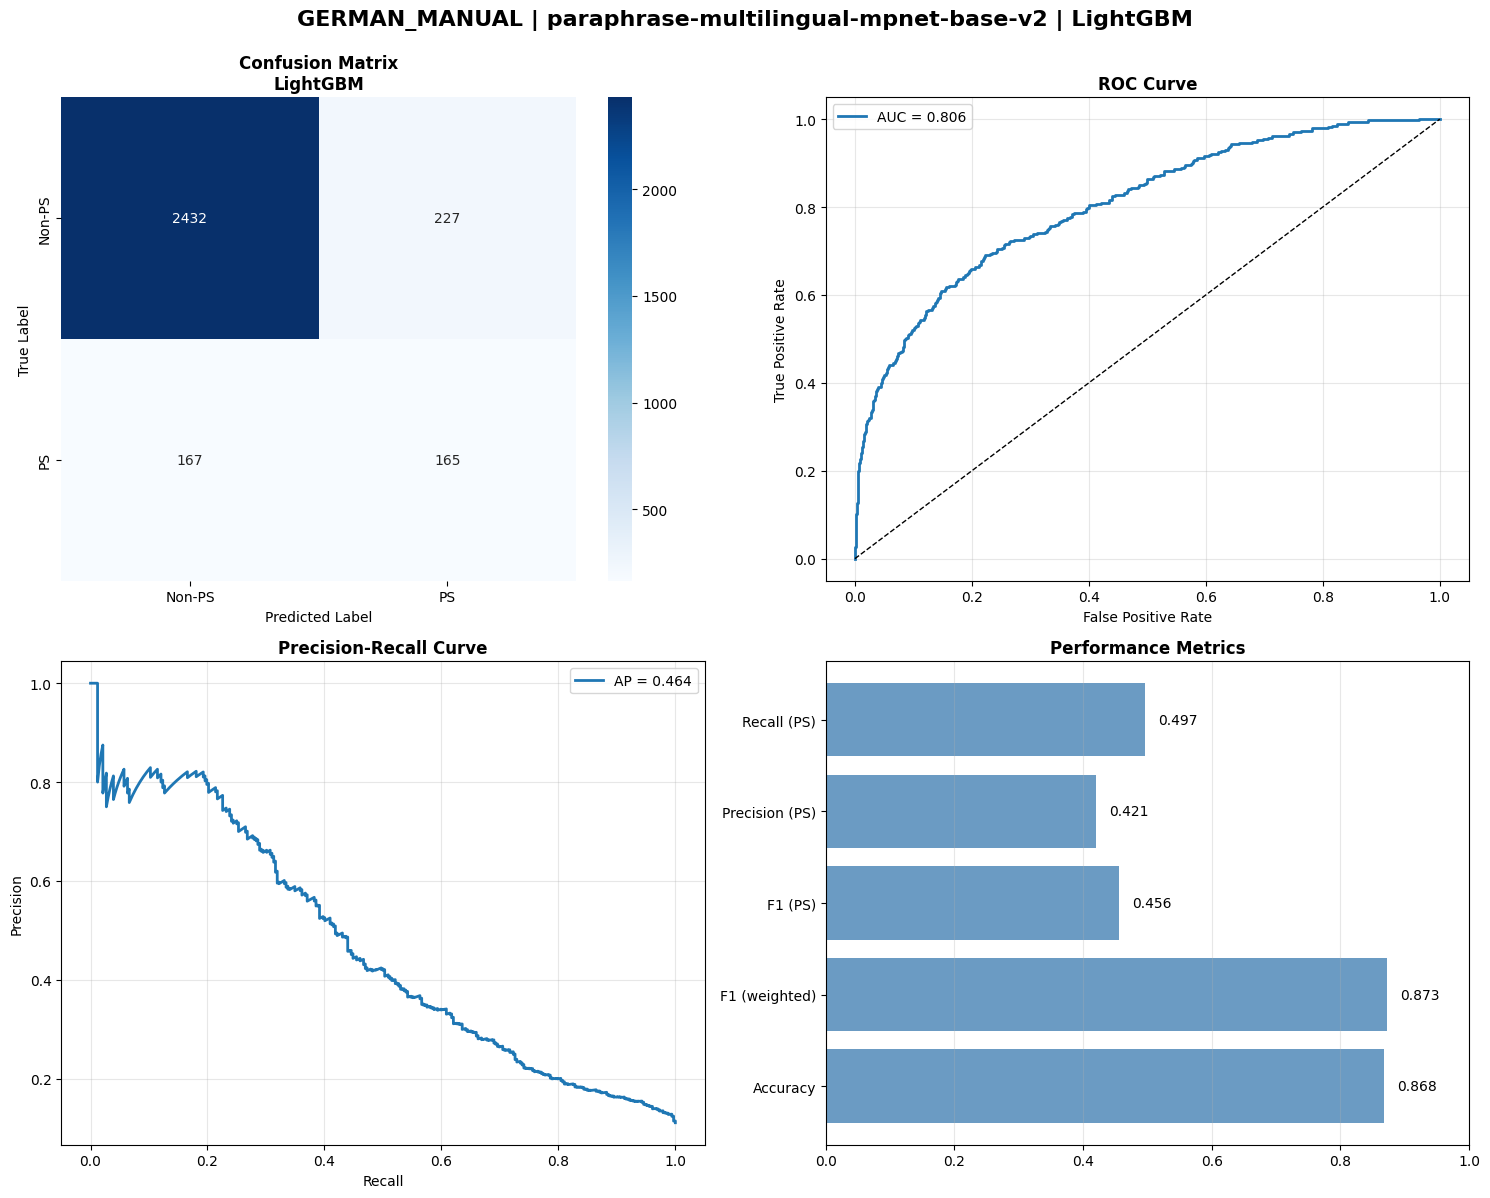


Detailed Report: GERMAN_MANUAL | paraphrase-multilingual-mpnet-base-v2 | Voting_Ensemble

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.9317    0.9334    0.9326      2659
    Process Safety     0.4587    0.4518    0.4552       332

          accuracy                         0.8800      2991
         macro avg     0.6952    0.6926    0.6939      2991
      weighted avg     0.8792    0.8800    0.8796      2991


 Visualization saved to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_4/eval_german_manual_paraphrase-multilingual-mpnet-base-v2_Voting_Ensemble.png


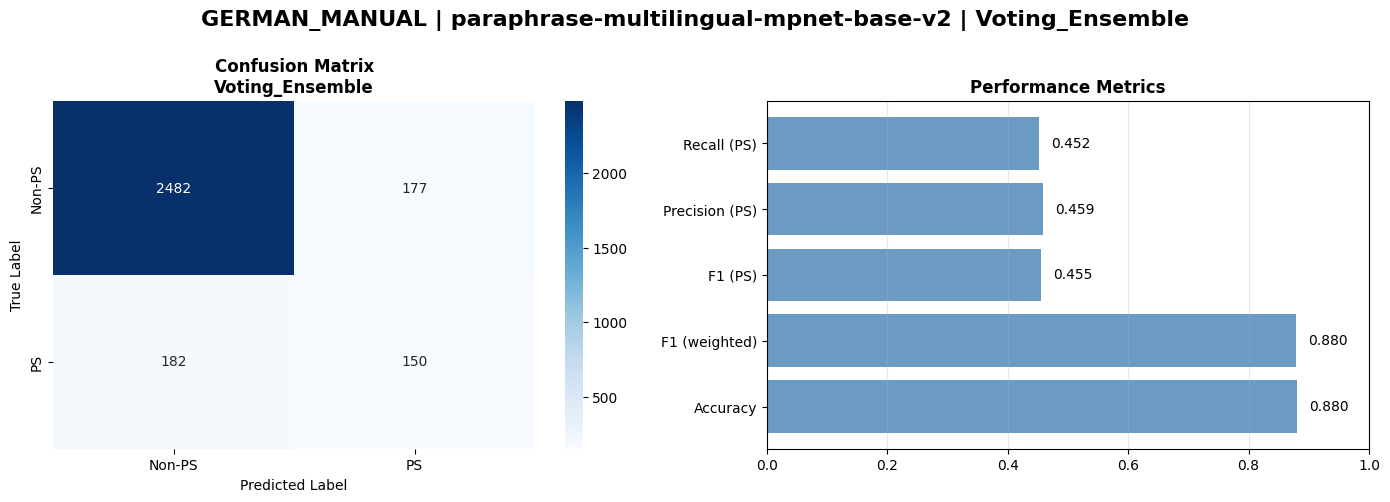


################################################################################
 Training Pipeline: SWEDISH_MANUAL
################################################################################
Model: paraphrase-multilingual-mpnet-base-v2
Pooling: mean
SMOTE used: True
Feature scaling: True

Training Multiple Classifiers: SWEDISH_MANUAL
Training samples: 6000
Test samples: 2445
Features: 768

 Training SVM with hyperparameter tuning...

 Training Random Forest...

 Training XGBoost...

 Training LightGBM...

────────────────────────────────────────────────────────────
 SVM
────────────────────────────────────────────────────────────


In [ ]:
import pandas as pd
import numpy as np
import os
import re
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score, 
    f1_score, precision_recall_fscore_support,
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
)
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModel
import torch
from tqdm import tqdm
import pickle
import glob
import gc
import json
import time
import warnings
warnings.filterwarnings('ignore')

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    print("XGBoost not available. Install with: pip install xgboost")
    XGBOOST_AVAILABLE = False

try:
    from lightgbm import LGBMClassifier
    LIGHTGBM_AVAILABLE = True
except ImportError:
    print("LightGBM not available. Install with: pip install lightgbm")
    LIGHTGBM_AVAILABLE = False

try:
    from imblearn.over_sampling import SMOTE
    from imblearn.under_sampling import RandomUnderSampler
    from imblearn.pipeline import Pipeline as ImbPipeline
    IMBLEARN_AVAILABLE = True
except ImportError:
    print("imbalanced-learn not available. Install with: pip install imbalanced-learn")
    IMBLEARN_AVAILABLE = False

# ============================================================
# ITERATION 4 - ENHANCED CONFIGURATION
# ============================================================

print("\n" + "#"*80)
print("ITERATION 4: ENHANCED MULTI-MODEL PIPELINE")
print("Advanced Techniques: SMOTE, Mean Pooling, Ensemble Methods, Hyperparameter Tuning")
print("#"*80)

# All paths are defined in Cell 2 via find_project_root_with_datasets().
# DATA_DIR, EMBEDDINGS_BASE_DIR, RESULTS_DIR, CHECKPOINT_FILE, LANGUAGE_CODE_MAP
# are set there — no hardcoded paths needed here.
print(f"\nUsing paths from Cell 2 (standardized):")
print(f"   DATA_DIR:            {DATA_DIR}")
print(f"   EMBEDDINGS_BASE_DIR: {EMBEDDINGS_BASE_DIR}")
print(f"   RESULTS_DIR:         {RESULTS_DIR}")
print(f"   CHECKPOINT_FILE:     {CHECKPOINT_FILE}")

# Create directories
os.makedirs(EMBEDDINGS_BASE_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(os.path.dirname(CHECKPOINT_FILE), exist_ok=True)

# Enhanced configuration
CONFIG = {
    'pooling_strategy': 'mean',  # 'cls', 'mean', or 'max'
    'use_smote': True,
    'smote_strategy': 0.7,  # Oversample minority to 70% of majority. Can anything else be done to automate the class imbalance issue. 
    'use_feature_scaling': True,
    'hyperparameter_tuning': True,
    'use_ensemble': True,
    'classifiers': ['svm', 'xgboost', 'lightgbm', 'random_forest', 'ensemble'],
    'cv_folds': 5,
    'text_preprocessing': True,
}

# Model configurations - Best performing models with FIXED paths
MODELS = {
    'bert-base-multilingual-uncased': 'google-bert/bert-base-multilingual-uncased',
    'xlm-roberta-base': 'xlm-roberta-base', 
    'paraphrase-multilingual-mpnet-base-v2': 'sentence-transformers/paraphrase-multilingual-mpnet-base-v2',
    'paraphrase-multilingual-MiniLM-L12-v2': 'sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2',
    'snowflake-arctic-embed-l-v2.0': 'snowflake/snowflake-arctic-embed-l-v2.0',
    'labse-gguf': 'ChristianAzinn/labse-gguf',
    'upskyy/bge-m3-korean': 'upskyy/bge-m3-korean',
    'Alibaba-NLP/gte-multilingual-base': 'Alibaba-NLP/gte-multilingual-base',
    'intfloat/multilingual-e5-large-instruct': 'intfloat/multilingual-e5-large-instruct',
    'efederici/e5-base-multilingual-4096': 'efederici/e5-base-multilingual-4096',
}


# Datasets to skip
SKIP_DATASETS = [
    'master_df_Hungary_manual.json',
    'master_df_International_manual.json',
    'master_df_Russia_manual.json',
    'master_df_UAE_manual.json',
    'master_df_Poland_manual.json',
    'master_df_Unknown_manual.json',
]

# Processing settings
BATCH_SIZE = 12
MAX_SAMPLES_SVM = 6000

print(f"\n Configuration:")
print(f"   Pooling Strategy: {CONFIG['pooling_strategy']}")
print(f"   Use SMOTE: {CONFIG['use_smote']}")
print(f"   Hyperparameter Tuning: {CONFIG['hyperparameter_tuning']}")
print(f"   Ensemble Methods: {CONFIG['use_ensemble']}")
print(f"   Models: {list(MODELS.keys())}")
print(f"   Batch Size: {BATCH_SIZE}")
print(f"   Max SVM Training Samples: {MAX_SAMPLES_SVM}")

# ============================================================
# TEXT PREPROCESSING FUNCTIONS
# ============================================================

def advanced_text_preprocessing(text):
    """Enhanced text preprocessing"""
    if pd.isna(text):
        return ""
    
    # Convert to lowercase
    text = str(text).lower()
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    # Remove email addresses
    text = re.sub(r'\S+@\S+', '', text)
    
    # Remove special characters but keep sentence structure
    text = re.sub(r'[^a-zA-Z0-9\s\.]', ' ', text)
    
    # Remove extra whitespace
    text = ' '.join(text.split())
    
    return text

# ============================================================
# CHECKPOINT FUNCTIONS
# ============================================================

def save_checkpoint(processed_items):
    """Save checkpoint with processed model-dataset combinations"""
    with open(CHECKPOINT_FILE, 'w') as f:
        json.dump({'processed': list(processed_items)}, f)
    print(f"Checkpoint saved: {len(processed_items)} combinations processed")

def load_checkpoint():
    """Load checkpoint"""
    if os.path.exists(CHECKPOINT_FILE):
        with open(CHECKPOINT_FILE, 'r') as f:
            return set(tuple(item) for item in json.load(f)['processed'])
    return set()

def reset_checkpoint():
    """Delete checkpoint to restart"""
    if os.path.exists(CHECKPOINT_FILE):
        os.remove(CHECKPOINT_FILE)
        print("Checkpoint cleared")
    else:
        print("No checkpoint found")

# ============================================================
# ENHANCED EMBEDDING GENERATION
# ============================================================

def get_enhanced_embeddings(texts, tokenizer, model, pooling='mean', max_length=512, batch_size=12):
    """
    Generate embeddings with advanced pooling strategies
    
    Args:
        pooling: 'cls' (first token), 'mean' (mean pooling), or 'max' (max pooling)
    """
    embeddings = []
    device = 'mps' if torch.backends.mps.is_available() else 'cpu'
    model = model.to(device)
    model.eval()
    
    print(f"Using device: {device}")
    print(f"Pooling strategy: {pooling}")
    
    for i in tqdm(range(0, len(texts), batch_size), desc="Generating embeddings"):
        batch_texts = texts[i:i + batch_size]
        
        inputs = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt"
        ).to(device)
        
        with torch.no_grad():
            outputs = model(**inputs)
            
            if pooling == 'cls':
                # [CLS] token (first token)
                batch_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
                
            elif pooling == 'mean':
                # Mean pooling with attention mask
                attention_mask = inputs['attention_mask']
                token_embeddings = outputs.last_hidden_state
                input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
                sum_embeddings = torch.sum(token_embeddings * input_mask_expanded, 1)
                sum_mask = torch.clamp(input_mask_expanded.sum(1), min=1e-9)
                batch_embeddings = (sum_embeddings / sum_mask).cpu().numpy()
                
            elif pooling == 'max':
                # Max pooling
                token_embeddings = outputs.last_hidden_state
                batch_embeddings = torch.max(token_embeddings, dim=1)[0].cpu().numpy()
                
            else:
                raise ValueError(f"Unknown pooling strategy: {pooling}")
            
            embeddings.extend(batch_embeddings)
        
        # Clear GPU memory after each batch
        if device == 'mps':
            torch.mps.empty_cache()
        
        # Clear CPU memory periodically
        if i % 50 == 0 and i > 0:
            gc.collect()
    
    return np.array(embeddings)

# ============================================================
# DATASET PROCESSING WITH ENHANCEMENTS
# ============================================================

def process_dataset_enhanced(json_file, model_key, model_name, tokenizer, model, dataset_name=None):
    """Process dataset with enhanced preprocessing and embeddings"""
    
    # dataset_name comes from the json_files dict key (e.g. 'english_lingua')
    if dataset_name is None:
        dataset_name = os.path.basename(json_file).replace('master_df_', '').replace('.json', '').lower()
    
    print(f"\n{'='*80}")
    print(f"Processing: {dataset_name.upper()}")
    print(f"Model: {model_key}")
    print(f"{'='*80}")
    
    # Load dataset from Iteration 0 pre-processed JSON (no re-preprocessing needed)
    df = pd.read_json(json_file)
    if 'LANGUAGE' in df.columns:
        df['LANGUAGE_CODE'] = df['LANGUAGE'].map(LANGUAGE_CODE_MAP).fillna('UN')
    print(f"Dataset shape: {df.shape}")
    
    # Create binary labels
    df['binary_label'] = df['CASE_TYPE'].apply(lambda x: 1 if x == 'Process Safety' else 0)
    
    print(f"\nCase type distribution:")
    print(df['CASE_TYPE'].value_counts())
    print(f"\nClass balance:")
    print(df['binary_label'].value_counts(normalize=True))
    
    # Enhanced text preprocessing
    if CONFIG['text_preprocessing']:
        print(f"\nApplying advanced text preprocessing...")
        df['text_features'] = df.apply(
            lambda x: advanced_text_preprocessing(str(x['TITLE']) + '. ' + str(x['CASE_DESCRIPTION'])),
            axis=1
        )
    else:
        df['text_features'] = df['TITLE'] + '. ' + df['CASE_DESCRIPTION']
    
    # Generate embeddings with selected pooling strategy
    print(f"\nGenerating {model_name} embeddings...")
    X = get_enhanced_embeddings(
        df['text_features'].tolist(),
        tokenizer,
        model,
        pooling=CONFIG['pooling_strategy'],
        batch_size=BATCH_SIZE
    )
    y = df['binary_label'].values
    
    # Split dataset
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    print(f"\nTraining set: {X_train.shape}")
    print(f"Test set: {X_test.shape}")
    
    # Apply SMOTE if enabled
    if CONFIG['use_smote'] and IMBLEARN_AVAILABLE:
        print(f"\n Applying SMOTE for class balancing...")
        print(f"   Strategy: Oversample minority to {CONFIG['smote_strategy']*100}% of majority")
        
        try:
            smote = SMOTE(
                sampling_strategy=CONFIG['smote_strategy'],
                random_state=42,
                k_neighbors=min(5, sum(y_train == 1) - 1)
            )
            X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)
            
            print(f"   Original training size: {X_train.shape[0]}")
            print(f"   Balanced training size: {X_train_balanced.shape[0]}")
            print(f"   Original class distribution: {np.bincount(y_train)}")
            print(f"   Balanced class distribution: {np.bincount(y_train_balanced)}")
            
            X_train_final = X_train_balanced
            y_train_final = y_train_balanced
            used_smote = True
            
        except Exception as e:
            print(f"   SMOTE failed: {e}")
            print(f"   Using original training data")
            X_train_final = X_train
            y_train_final = y_train
            used_smote = False
    else:
        X_train_final = X_train
        y_train_final = y_train
        used_smote = False
    
    # Subsample if still too large for SVM
    if X_train_final.shape[0] > MAX_SAMPLES_SVM:
        print(f"\n Training set too large ({X_train_final.shape[0]} samples)")
        print(f"   Subsampling to {MAX_SAMPLES_SVM} for SVM efficiency...")
        from sklearn.utils import resample
        X_train_subset, y_train_subset = resample(
            X_train_final, y_train_final,
            n_samples=MAX_SAMPLES_SVM,
            stratify=y_train_final,
            random_state=42
        )
        print(f"   Subsampled training set: {X_train_subset.shape}")
        subsampled = True
    else:
        X_train_subset = X_train_final
        y_train_subset = y_train_final
        subsampled = False
    
    # Feature scaling
    if CONFIG['use_feature_scaling']:
        print(f"\n Applying feature scaling...")
        scaler = StandardScaler()
        X_train_subset_scaled = scaler.fit_transform(X_train_subset)
        X_test_scaled = scaler.transform(X_test)
    else:
        X_train_subset_scaled = X_train_subset
        X_test_scaled = X_test
        scaler = None
    
    # Create model-specific directory
    model_dir = os.path.join(EMBEDDINGS_BASE_DIR, model_key.replace('/', '_'))
    os.makedirs(model_dir, exist_ok=True)
    
    # Save embeddings and preprocessing artifacts
    embeddings_data = {
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test,
        'X_train_balanced': X_train_final,
        'y_train_balanced': y_train_final,
        'X_train_subset': X_train_subset_scaled,
        'y_train_subset': y_train_subset,
        'X_test_scaled': X_test_scaled,
        'scaler': scaler,
        'feature_names': df['text_features'].tolist(),
        'metadata': {
            'model': model_name,
            'model_key': model_key,
            'dataset': dataset_name,
            'embedding_dim': X_train.shape[1],
            'train_size_original': X_train.shape[0],
            'train_size_balanced': X_train_final.shape[0],
            'train_size_final': X_train_subset.shape[0],
            'test_size': X_test.shape[0],
            'random_state': 42,
            'pooling_strategy': CONFIG['pooling_strategy'],
            'used_smote': used_smote,
            'smote_strategy': CONFIG['smote_strategy'] if used_smote else None,
            'subsampled': subsampled,
            'feature_scaling': CONFIG['use_feature_scaling'],
            'text_preprocessing': CONFIG['text_preprocessing'],
        }
    }
    
    pkl_file = os.path.join(model_dir, f'{dataset_name}_{model_key.replace("/", "_")}_embeddings.pkl')
    
    with open(pkl_file, 'wb') as f:
        pickle.dump(embeddings_data, f)
    
    print(f"\n{'='*60}")
    print(f"Embeddings saved!")
    print(f"Location: {pkl_file}")
    print(f"Size: {os.path.getsize(pkl_file) / 1024**2:.2f} MB")
    print(f"{'='*60}\n")
    
    # Clear memory
    del df, X, y, X_train, X_test, y_train, y_test
    if used_smote:
        del X_train_balanced, y_train_balanced
    del X_train_final, y_train_final, X_train_subset, y_train_subset
    del X_train_subset_scaled, X_test_scaled, embeddings_data
    gc.collect()
    if torch.backends.mps.is_available():
        torch.mps.empty_cache()
    
    return pkl_file

# ============================================================
# ENHANCED CLASSIFIER TRAINING
# ============================================================

def train_multiple_classifiers(X_train, y_train, X_test, y_test, dataset_name, model_key):
    """Train and evaluate multiple classifiers"""
    
    results = {}
    
    print(f"\n{'='*80}")
    print(f"Training Multiple Classifiers: {dataset_name.upper()}")
    print(f"{'='*80}")
    print(f"Training samples: {X_train.shape[0]}")
    print(f"Test samples: {X_test.shape[0]}")
    print(f"Features: {X_train.shape[1]}")
    
    # Define classifiers
    classifiers = {}
    
    # SVM with hyperparameter tuning
    if 'svm' in CONFIG['classifiers']:
        if CONFIG['hyperparameter_tuning']:
            print(f"\n Training SVM with hyperparameter tuning...")
            param_grid_svm = {
                'C': [0.1, 1, 10, 100],
                'class_weight': ['balanced', {0: 1, 1: 2}, {0: 1, 1: 3}],
                'max_iter': [10000],
            }
            svm_base = LinearSVC(dual=False, random_state=42)
            svm_model = GridSearchCV(
                svm_base, param_grid_svm, cv=3, scoring='f1_weighted',
                n_jobs=-1, verbose=0
            )
        else:
            svm_model = LinearSVC(class_weight='balanced', max_iter=10000, dual=False, random_state=42)
        
        classifiers['SVM'] = svm_model
    
    # Random Forest
    if 'random_forest' in CONFIG['classifiers']:
        print(f"\n Training Random Forest...")
        classifiers['Random_Forest'] = RandomForestClassifier(
            n_estimators=200,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1,
            max_depth=20
        )
    
    # XGBoost
    if 'xgboost' in CONFIG['classifiers'] and XGBOOST_AVAILABLE:
        print(f"\n Training XGBoost...")
        pos_weight = sum(y_train == 0) / sum(y_train == 1)
        classifiers['XGBoost'] = XGBClassifier(
            n_estimators=200,
            scale_pos_weight=pos_weight,
            random_state=42,
            n_jobs=-1,
            max_depth=6,
            learning_rate=0.1
        )
    
    # LightGBM
    if 'lightgbm' in CONFIG['classifiers'] and LIGHTGBM_AVAILABLE:
        print(f"\n Training LightGBM...")
        classifiers['LightGBM'] = LGBMClassifier(
            n_estimators=200,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1,
            max_depth=6,
            learning_rate=0.1,
            verbose=-1
        )
    
    # Train each classifier
    for name, clf in classifiers.items():
        print(f"\n{'─'*60}")
        print(f" {name}")
        print(f"{'─'*60}")
        
        start_time = time.time()
        clf.fit(X_train, y_train)
        training_time = time.time() - start_time
        
        y_pred = clf.predict(X_test)
        
        # Calculate metrics
        accuracy = accuracy_score(y_test, y_pred)
        f1_weighted = f1_score(y_test, y_pred, average='weighted')
        f1_macro = f1_score(y_test, y_pred, average='macro')
        
        precision, recall, f1, support = precision_recall_fscore_support(
            y_test, y_pred, average=None, labels=[0, 1]
        )
        
        # Try to get probability predictions for AUC
        try:
            if hasattr(clf, 'predict_proba'):
                y_proba = clf.predict_proba(X_test)[:, 1]
            elif hasattr(clf, 'decision_function'):
                y_proba = clf.decision_function(X_test)
            else:
                y_proba = None
                
            if y_proba is not None:
                roc_auc = roc_auc_score(y_test, y_proba)
                avg_precision = average_precision_score(y_test, y_proba)
            else:
                roc_auc = None
                avg_precision = None
        except:
            y_proba = None
            roc_auc = None
            avg_precision = None
        
        # Store results
        results[name] = {
            'model': clf,
            'y_pred': y_pred,
            'y_proba': y_proba,
            'accuracy': accuracy,
            'f1_weighted': f1_weighted,
            'f1_macro': f1_macro,
            'precision_non_ps': precision[0],
            'recall_non_ps': recall[0],
            'f1_non_ps': f1[0],
            'support_non_ps': support[0],
            'precision_ps': precision[1],
            'recall_ps': recall[1],
            'f1_ps': f1[1],
            'support_ps': support[1],
            'training_time': training_time,
            'roc_auc': roc_auc,
            'avg_precision': avg_precision,
        }
        
        # Print best parameters if GridSearchCV was used
        if hasattr(clf, 'best_params_'):
            print(f"   Best parameters: {clf.best_params_}")
            print(f"   Best CV score: {clf.best_score_:.4f}")
        
        print(f"   Accuracy: {accuracy:.4f}")
        print(f"   F1 (weighted): {f1_weighted:.4f}")
        print(f"   F1 (Process Safety): {f1[1]:.4f}")
        if roc_auc:
            print(f"   ROC AUC: {roc_auc:.4f}")
        print(f"   Training time: {training_time:.2f}s")
    
    # Create ensemble if enabled
    if CONFIG['use_ensemble'] and len(classifiers) >= 2:
        print(f"\n{'─'*60}")
        print(f" Creating Voting Ensemble")
        print(f"{'─'*60}")
        
        try:
            # Select top 3 classifiers for ensemble
            ensemble_classifiers = []
            for name, clf in list(classifiers.items())[:3]:
                ensemble_classifiers.append((name, clf))
            
            voting_clf = VotingClassifier(
                estimators=ensemble_classifiers,
                voting='hard'
            )
            
            start_time = time.time()
            voting_clf.fit(X_train, y_train)
            training_time = time.time() - start_time
            
            y_pred = voting_clf.predict(X_test)
            
            accuracy = accuracy_score(y_test, y_pred)
            f1_weighted = f1_score(y_test, y_pred, average='weighted')
            f1_macro = f1_score(y_test, y_pred, average='macro')
            
            precision, recall, f1, support = precision_recall_fscore_support(
                y_test, y_pred, average=None, labels=[0, 1]
            )
            
            results['Voting_Ensemble'] = {
                'model': voting_clf,
                'y_pred': y_pred,
                'y_proba': None,
                'accuracy': accuracy,
                'f1_weighted': f1_weighted,
                'f1_macro': f1_macro,
                'precision_non_ps': precision[0],
                'recall_non_ps': recall[0],
                'f1_non_ps': f1[0],
                'support_non_ps': support[0],
                'precision_ps': precision[1],
                'recall_ps': recall[1],
                'f1_ps': f1[1],
                'support_ps': support[1],
                'training_time': training_time,
                'roc_auc': None,
                'avg_precision': None,
            }
            
            print(f"   Accuracy: {accuracy:.4f}")
            print(f"   F1 (weighted): {f1_weighted:.4f}")
            print(f"   F1 (Process Safety): {f1[1]:.4f}")
            print(f"   Training time: {training_time:.2f}s")
            
        except Exception as e:
            print(f"   Ensemble creation failed: {e}")
    
    # Find best classifier
    best_classifier_name = max(results, key=lambda x: results[x]['f1_ps'])
    print(f"\n{'='*80}")
    print(f"Best Classifier: {best_classifier_name}")
    print(f"   Process Safety F1: {results[best_classifier_name]['f1_ps']:.4f}")
    print(f"{'='*80}")
    
    return results, best_classifier_name

# ============================================================
# COMPREHENSIVE EVALUATION
# ============================================================

def comprehensive_evaluation(results, X_test, y_test, dataset_name, model_key):
    """Comprehensive evaluation with visualizations"""
    
    all_results = []
    
    for clf_name, result in results.items():
        y_pred = result['y_pred']
        y_proba = result['y_proba']
        
        print(f"\n{'='*80}")
        print(f"Detailed Report: {dataset_name.upper()} | {model_key} | {clf_name}")
        print(f"{'='*80}")
        
        # Classification report
        print("\nClassification Report:")
        print(classification_report(
            y_test, y_pred,
            target_names=['Non-Process Safety', 'Process Safety'],
            digits=4
        ))
        
        # Confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        
        # Create comprehensive visualization
        if y_proba is not None:
            fig, axes = plt.subplots(2, 2, figsize=(15, 12))
            
            # Confusion Matrix
            sns.heatmap(
                cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Non-PS', 'PS'],
                yticklabels=['Non-PS', 'PS'],
                ax=axes[0, 0]
            )
            axes[0, 0].set_title(f'Confusion Matrix\n{clf_name}', fontweight='bold')
            axes[0, 0].set_ylabel('True Label')
            axes[0, 0].set_xlabel('Predicted Label')
            
            # ROC Curve
            fpr, tpr, _ = roc_curve(y_test, y_proba)
            axes[0, 1].plot(fpr, tpr, label=f'AUC = {result["roc_auc"]:.3f}', linewidth=2)
            axes[0, 1].plot([0, 1], [0, 1], 'k--', linewidth=1)
            axes[0, 1].set_xlabel('False Positive Rate')
            axes[0, 1].set_ylabel('True Positive Rate')
            axes[0, 1].set_title('ROC Curve', fontweight='bold')
            axes[0, 1].legend()
            axes[0, 1].grid(alpha=0.3)
            
            # Precision-Recall Curve
            precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_proba)
            axes[1, 0].plot(recall_curve, precision_curve, 
                          label=f'AP = {result["avg_precision"]:.3f}', linewidth=2)
            axes[1, 0].set_xlabel('Recall')
            axes[1, 0].set_ylabel('Precision')
            axes[1, 0].set_title('Precision-Recall Curve', fontweight='bold')
            axes[1, 0].legend()
            axes[1, 0].grid(alpha=0.3)
            
            # Metrics Bar Chart
            metrics_data = {
                'Accuracy': result['accuracy'],
                'F1 (weighted)': result['f1_weighted'],
                'F1 (PS)': result['f1_ps'],
                'Precision (PS)': result['precision_ps'],
                'Recall (PS)': result['recall_ps'],
            }
            axes[1, 1].barh(list(metrics_data.keys()), list(metrics_data.values()), 
                          color='steelblue', alpha=0.8)
            axes[1, 1].set_xlim([0, 1])
            axes[1, 1].set_title('Performance Metrics', fontweight='bold')
            axes[1, 1].grid(axis='x', alpha=0.3)
            for i, (k, v) in enumerate(metrics_data.items()):
                axes[1, 1].text(v + 0.02, i, f'{v:.3f}', va='center')
            
        else:
            fig, axes = plt.subplots(1, 2, figsize=(14, 5))
            
            # Confusion Matrix
            sns.heatmap(
                cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Non-PS', 'PS'],
                yticklabels=['Non-PS', 'PS'],
                ax=axes[0]
            )
            axes[0].set_title(f'Confusion Matrix\n{clf_name}', fontweight='bold')
            axes[0].set_ylabel('True Label')
            axes[0].set_xlabel('Predicted Label')
            
            # Metrics Bar Chart
            metrics_data = {
                'Accuracy': result['accuracy'],
                'F1 (weighted)': result['f1_weighted'],
                'F1 (PS)': result['f1_ps'],
                'Precision (PS)': result['precision_ps'],
                'Recall (PS)': result['recall_ps'],
            }
            axes[1].barh(list(metrics_data.keys()), list(metrics_data.values()), 
                        color='steelblue', alpha=0.8)
            axes[1].set_xlim([0, 1])
            axes[1].set_title('Performance Metrics', fontweight='bold')
            axes[1].grid(axis='x', alpha=0.3)
            for i, (k, v) in enumerate(metrics_data.items()):
                axes[1].text(v + 0.02, i, f'{v:.3f}', va='center')
        
        plt.suptitle(f'{dataset_name.upper()} | {model_key} | {clf_name}', 
                    fontsize=16, fontweight='bold', y=0.995)
        plt.tight_layout()
        
        # Save plot
        plot_filename = f'eval_{dataset_name}_{model_key.replace("/", "_")}_{clf_name}.png'
        plot_path = os.path.join(RESULTS_DIR, plot_filename)
        plt.savefig(plot_path, dpi=300, bbox_inches='tight')
        print(f"\n Visualization saved to: {plot_path}")
        plt.show()
        plt.close()
        
        # Compile results
        result_dict = {
            'dataset': dataset_name,
            'model': model_key,
            'classifier': clf_name,
            'accuracy': result['accuracy'],
            'f1_weighted': result['f1_weighted'],
            'f1_macro': result['f1_macro'],
            'precision_non_ps': result['precision_non_ps'],
            'recall_non_ps': result['recall_non_ps'],
            'f1_non_ps': result['f1_non_ps'],
            'support_non_ps': result['support_non_ps'],
            'precision_ps': result['precision_ps'],
            'recall_ps': result['recall_ps'],
            'f1_ps': result['f1_ps'],
            'support_ps': result['support_ps'],
            'training_time': result['training_time'],
            'roc_auc': result['roc_auc'],
            'avg_precision': result['avg_precision'],
            'confusion_matrix': cm.tolist(),
        }
        
        all_results.append(result_dict)
    
    return all_results

# ============================================================
# MAIN TRAINING PIPELINE
# ============================================================

def train_and_evaluate_embeddings(embeddings_file):
    """Load embeddings and train multiple classifiers"""
    
    # Load embeddings
    with open(embeddings_file, 'rb') as f:
        embeddings_data = pickle.load(f)
    
    X_train = embeddings_data['X_train_subset']
    y_train = embeddings_data['y_train_subset']
    X_test = embeddings_data['X_test_scaled']
    y_test = embeddings_data['y_test']
    metadata = embeddings_data['metadata']
    
    dataset_name = metadata['dataset']
    model_key = metadata['model_key']
    
    print(f"\n{'#'*80}")
    print(f" Training Pipeline: {dataset_name.upper()}")
    print(f"{'#'*80}")
    print(f"Model: {model_key}")
    print(f"Pooling: {metadata['pooling_strategy']}")
    print(f"SMOTE used: {metadata['used_smote']}")
    print(f"Feature scaling: {metadata['feature_scaling']}")
    
    # Train multiple classifiers
    results, best_classifier = train_multiple_classifiers(
        X_train, y_train, X_test, y_test, dataset_name, model_key
    )
    
    # Comprehensive evaluation
    all_results = comprehensive_evaluation(
        results, X_test, y_test, dataset_name, model_key
    )
    
    # Clear memory
    del embeddings_data, X_train, X_test, y_train, y_test
    gc.collect()
    
    return all_results

# ============================================================
# MAIN EXECUTION
# ============================================================

print("\n" + "#"*80)
print(" STARTING ITERATION 4 PIPELINE")
print("#"*80)

# =============================================================================
# Load datasets from Iteration 0 pre-processed outputs (no re-preprocessing)
# =============================================================================
from pathlib import Path as _Path
_MASTER_DS = _Path(DATA_DIR)

DATASET_FILES = {
    'english_manual':     str(PATHS['master_dataset'] / 'By_SL_Country' / 'master_df_English_manual.json'),
    'german_manual':      str(PATHS['master_dataset'] / 'By_SL_Country' / 'master_df_Germany_manual.json'),
    'swedish_manual':     str(PATHS['master_dataset'] / 'By_SL_Country' / 'master_df_Sweden_manual.json'),
    'dutch_manual':       str(PATHS['master_dataset'] / 'By_SL_Country' / 'master_df_Netherlands_manual.json'),
}

# Only include files that actually exist
json_files = {name: path for name, path in DATASET_FILES.items() if os.path.exists(path)}
missing = [name for name, path in DATASET_FILES.items() if not os.path.exists(path)]

print(f"\n Found {len(json_files)} datasets to process")
if missing:
    print(f" Skipping missing: {missing}")
print(f" Total combinations: {len(json_files) * len(MODELS)}")

# Load checkpoint
processed_items = load_checkpoint()
print(f"\n Already processed: {len(processed_items)} combinations")

# Track results
all_results = []
start_time = time.time()

# Process each model
for model_key, model_name in MODELS.items():
    print(f"\n{'#'*80}")
    print(f" MODEL: {model_key}")
    print(f"{'#'*80}")
    
    try:
        # Initialize model
        print(f"\n Initializing {model_key}...")
        tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
        model = AutoModel.from_pretrained(model_name, trust_remote_code=True)
        
        # Add padding token if missing
        if tokenizer.pad_token is None:
            tokenizer.pad_token = tokenizer.eos_token
            if hasattr(model.config, 'eos_token_id'):
                model.config.pad_token_id = model.config.eos_token_id
        
        print(f" Model loaded successfully!")
        
        # Phase 1: Generate embeddings
        print(f"\n{'='*80}")
        print(f" PHASE 1: GENERATING EMBEDDINGS - {model_key}")
        print(f"{'='*80}")
        
        pkl_files = []
        
        for dataset_name, json_file in json_files.items():
            # dataset_name is already the dict key (e.g. 'english_lingua')
            item_key = (model_key, dataset_name)
            
            # Check if already processed
            if item_key in processed_items:
                print(f"\n Skipping already processed: {dataset_name} with {model_key}")
                pkl_file = os.path.join(
                    EMBEDDINGS_BASE_DIR,
                    model_key.replace('/', '_'),
                    f'{dataset_name}_{model_key.replace("/", "_")}_embeddings.pkl'
                )
                if os.path.exists(pkl_file):
                    pkl_files.append(pkl_file)
                continue
            
            try:
                pkl_file = process_dataset_enhanced(json_file, model_key, model_name, tokenizer, model, dataset_name=dataset_name)
                pkl_files.append(pkl_file)
                
                # Save checkpoint
                processed_items.add(item_key)
                save_checkpoint(processed_items)
                
                print(f" Progress: {len(processed_items)}/{len(json_files) * len(MODELS)}")
               
            except Exception as e:
                print(f" ERROR processing {dataset_name} with {model_key}: {str(e)}\n")
                import traceback
                traceback.print_exc()
                continue
        
        # Phase 2: Train classifiers
        print(f"\n{'='*80}")
        print(f" PHASE 2: TRAINING CLASSIFIERS - {model_key}")
        print(f"{'='*80}")
        
        for pkl_file in pkl_files:
            try:
                results = train_and_evaluate_embeddings(pkl_file)
                all_results.extend(results)
                
            except Exception as e:
                dataset_name = os.path.basename(pkl_file).split('_')[0]
                print(f" ERROR training classifiers for {dataset_name} with {model_key}: {str(e)}\n")
                import traceback
                traceback.print_exc()
                continue
        
        # Clear model from memory
        del tokenizer, model
        gc.collect()
        if torch.backends.mps.is_available():
            torch.mps.empty_cache()
        
        print(f"\n Completed processing {model_key}")
        
    except Exception as e:
        print(f"\n ERROR loading model {model_key}: {str(e)}")
        import traceback
        traceback.print_exc()
        print(f" Skipping this model and continuing...\n")
        continue

# ============================================================
# FINAL COMPREHENSIVE SUMMARY
# ============================================================

print("\n" + "#"*80)
print(" FINAL COMPREHENSIVE SUMMARY - ITERATION 4")
print("#"*80 + "\n")

if all_results:
    results_df = pd.DataFrame(all_results)
    
    # Display results table
    print("="*100)
    print(" DETAILED RESULTS TABLE")
    print("="*100)
    
    detailed_cols = [
        'dataset', 'model', 'classifier', 'accuracy', 'f1_weighted', 'f1_macro',
        'precision_ps', 'recall_ps', 'f1_ps', 'support_ps',
        'roc_auc', 'avg_precision', 'training_time'
    ]
    
    display_cols = [col for col in detailed_cols if col in results_df.columns]
    display_df = results_df[display_cols].copy()
    
    # Round numeric columns
    numeric_cols = ['accuracy', 'f1_weighted', 'f1_macro', 
                    'precision_ps', 'recall_ps', 'f1_ps',
                    'roc_auc', 'avg_precision']
    
    for col in numeric_cols:
        if col in display_df.columns:
            display_df[col] = display_df[col].round(4)
    
    if 'training_time' in display_df.columns:
        display_df['training_time'] = display_df['training_time'].round(2)
    
    print(display_df.to_string(index=False))
    
    # Save results to JSON
    summary_file = os.path.join(RESULTS_DIR, 'iteration_4_comprehensive_results.json')
    results_df.to_json(summary_file, orient='records', lines=True)
    print(f"\n Results saved to: {summary_file}")
    
    # Aggregate statistics
    print(f"\n{'='*80}")
    print(" AGGREGATE STATISTICS")
    print(f"{'='*80}")
    print(f"Total model-dataset-classifier combinations: {len(results_df)}")
    print(f"Datasets processed: {results_df['dataset'].nunique()}")
    print(f"Models used: {results_df['model'].nunique()}")
    print(f"Classifiers tested: {results_df['classifier'].nunique()}")
    
    if results_df['accuracy'].notna().any():
        print(f"\n Overall Performance Statistics:")
        print(f"{'─'*60}")
        
        metrics_summary = {
            'Accuracy': results_df['accuracy'],
            'F1 (weighted)': results_df['f1_weighted'],
            'F1 (macro)': results_df['f1_macro'],
            'F1 (Process Safety)': results_df['f1_ps'],
            'Precision (PS)': results_df['precision_ps'],
            'Recall (PS)': results_df['recall_ps'],
        }
        
        for metric_name, metric_values in metrics_summary.items():
            print(f"\n{metric_name}:")
            print(f"  Min:  {metric_values.min():.4f}")
            print(f"  Max:  {metric_values.max():.4f}")
            print(f"  Mean: {metric_values.mean():.4f}")
            print(f"  Std:  {metric_values.std():.4f}")
        
        if 'roc_auc' in results_df.columns:
            roc_auc_valid = results_df['roc_auc'].dropna()
            if len(roc_auc_valid) > 0:
                print(f"\nROC AUC:")
                print(f"  Min:  {roc_auc_valid.min():.4f}")
                print(f"  Max:  {roc_auc_valid.max():.4f}")
                print(f"  Mean: {roc_auc_valid.mean():.4f}")
        
        if 'training_time' in results_df.columns:
            print(f"\n Training Time Statistics:")
            print(f"  Min:   {results_df['training_time'].min():.2f}s")
            print(f"  Max:   {results_df['training_time'].max():.2f}s")
            print(f"  Mean:  {results_df['training_time'].mean():.2f}s")
            print(f"  Total: {results_df['training_time'].sum():.2f}s")
        
        # Best performing combination
        best_idx = results_df['f1_ps'].idxmax()
        print(f"\n{'='*80}")
        print(" BEST PERFORMING COMBINATION (by Process Safety F1)")
        print(f"{'='*80}")
        print(f"Dataset:    {results_df.loc[best_idx, 'dataset']}")
        print(f"Model:      {results_df.loc[best_idx, 'model']}")
        print(f"Classifier: {results_df.loc[best_idx, 'classifier']}")
        print(f"\n Metrics:")
        print(f"  Accuracy:           {results_df.loc[best_idx, 'accuracy']:.4f}")
        print(f"  F1 (weighted):      {results_df.loc[best_idx, 'f1_weighted']:.4f}")
        print(f"  F1 (PS):            {results_df.loc[best_idx, 'f1_ps']:.4f}")
        print(f"  Precision (PS):     {results_df.loc[best_idx, 'precision_ps']:.4f}")
        print(f"  Recall (PS):        {results_df.loc[best_idx, 'recall_ps']:.4f}")
        if pd.notna(results_df.loc[best_idx, 'roc_auc']):
            print(f"  ROC AUC:            {results_df.loc[best_idx, 'roc_auc']:.4f}")
        
        # Average performance by model
        print(f"\n{'='*80}")
        print(" AVERAGE PERFORMANCE BY MODEL")
        print(f"{'='*80}")
        model_stats = results_df.groupby('model')[
            ['accuracy', 'f1_weighted', 'f1_ps', 'precision_ps', 'recall_ps']
        ].agg(['mean', 'std'])
        print(model_stats.to_string())
        
        # Average performance by classifier
        print(f"\n{'='*80}")
        print(" AVERAGE PERFORMANCE BY CLASSIFIER")
        print(f"{'='*80}")
        classifier_stats = results_df.groupby('classifier')[
            ['accuracy', 'f1_weighted', 'f1_ps', 'precision_ps', 'recall_ps']
        ].agg(['mean', 'std'])
        print(classifier_stats.to_string())
        
        # Create comparison visualization
        print(f"\n Creating performance comparison charts...")
        
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        
        # F1 Process Safety by Classifier
        classifier_f1 = results_df.groupby('classifier')['f1_ps'].mean().sort_values(ascending=False)
        axes[0, 0].barh(classifier_f1.index, classifier_f1.values, color='steelblue', alpha=0.8)
        axes[0, 0].set_xlabel('F1 Score (Process Safety)')
        axes[0, 0].set_title('Average F1 Score by Classifier', fontweight='bold')
        axes[0, 0].grid(axis='x', alpha=0.3)
        for i, v in enumerate(classifier_f1.values):
            axes[0, 0].text(v + 0.01, i, f'{v:.3f}', va='center')
        
        # F1 Process Safety by Model
        model_f1 = results_df.groupby('model')['f1_ps'].mean().sort_values(ascending=False)
        axes[0, 1].barh(model_f1.index, model_f1.values, color='coral', alpha=0.8)
        axes[0, 1].set_xlabel('F1 Score (Process Safety)')
        axes[0, 1].set_title('Average F1 Score by Model', fontweight='bold')
        axes[0, 1].grid(axis='x', alpha=0.3)
        for i, v in enumerate(model_f1.values):
            axes[0, 1].text(v + 0.01, i, f'{v:.3f}', va='center')
        
        # Accuracy vs F1 PS scatter
        for classifier in results_df['classifier'].unique():
            subset = results_df[results_df['classifier'] == classifier]
            axes[1, 0].scatter(subset['accuracy'], subset['f1_ps'], 
                             label=classifier, alpha=0.6, s=100)
        axes[1, 0].set_xlabel('Accuracy')
        axes[1, 0].set_ylabel('F1 Score (Process Safety)')
        axes[1, 0].set_title('Accuracy vs F1 (PS) by Classifier', fontweight='bold')
        axes[1, 0].legend()
        axes[1, 0].grid(alpha=0.3)
        
        # Precision vs Recall for PS
        for classifier in results_df['classifier'].unique():
            subset = results_df[results_df['classifier'] == classifier]
            axes[1, 1].scatter(subset['recall_ps'], subset['precision_ps'], 
                             label=classifier, alpha=0.6, s=100)
        axes[1, 1].set_xlabel('Recall (Process Safety)')
        axes[1, 1].set_ylabel('Precision (Process Safety)')
        axes[1, 1].set_title('Precision vs Recall (PS) by Classifier', fontweight='bold')
        axes[1, 1].legend()
        axes[1, 1].grid(alpha=0.3)
        
        plt.suptitle('Iteration 4: Performance Comparison', fontsize=16, fontweight='bold', y=0.995)
        plt.tight_layout()
        
        comparison_plot = os.path.join(RESULTS_DIR, 'iteration_4_performance_comparison.png')
        plt.savefig(comparison_plot, dpi=300, bbox_inches='tight')
        print(f" Comparison chart saved to: {comparison_plot}")
        plt.show()
        plt.close()

else:
    print(" No results to display.")

# Clear checkpoint if all completed
total_combinations = len(json_files) * len(MODELS)
if len(processed_items) == total_combinations:
    print(f"\n{'='*80}")
    print(" ALL COMBINATIONS PROCESSED!")
    print(f"{'='*80}")
    if os.path.exists(CHECKPOINT_FILE):
        os.remove(CHECKPOINT_FILE)
        print("  Checkpoint file cleared.")

total_time = (time.time() - start_time) / 60
print(f"\n Total execution time: {total_time:.2f} minutes")

print("\n" + "#"*80)
print(" ITERATION 4 PIPELINE COMPLETE")
print("#"*80)
print("\n Key Improvements Implemented:")
print("    Mean pooling for better embeddings")
print("    SMOTE for class balancing")
print("    Multiple classifier comparison")
print("    Hyperparameter tuning")
print("    Ensemble methods")
print("    Feature scaling")
print("    Enhanced text preprocessing")
print("    Comprehensive visualizations")
print("    ROC AUC and Precision-Recall curves")
print("\n" + "#"*80)

## Results Generation and Evaluation
This cell loads saved embeddings, trains and evaluates classifiers, generates confusion matrices and performance metrics, and saves comprehensive results. Run this cell after the main pipeline to analyze and visualize model performance.

In [ ]:
# ============================================================
# RESULTS OF ITERATION 4
# ============================================================

import pandas as pd
import numpy as np
import os
import pickle
import glob
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score, 
    f1_score, precision_recall_fscore_support,
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
)
import matplotlib.pyplot as plt
import seaborn as sns
import time

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False

try:
    from lightgbm import LGBMClassifier
    LIGHTGBM_AVAILABLE = True
except ImportError:
    LIGHTGBM_AVAILABLE = False


print(f"Using paths from Cell 2:")
print(f"  EMBEDDINGS_BASE_DIR: {EMBEDDINGS_BASE_DIR}")
print(f"  RESULTS_DIR: {RESULTS_DIR}")
os.makedirs(RESULTS_DIR, exist_ok=True)

def calculate_detailed_metrics(y_test, y_pred):
    """Calculate comprehensive evaluation metrics"""
    cm = confusion_matrix(y_test, y_pred)
    TN, FP, FN, TP = cm[0, 0], cm[0, 1], cm[1, 0], cm[1, 1]
    total = TN + FP + FN + TP
    
    accuracy = (TP + TN) / total
    precision_ps = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall_ps = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1_ps = 2 * (precision_ps * recall_ps) / (precision_ps + recall_ps) if (precision_ps + recall_ps) > 0 else 0
    
    precision_nps = TN / (TN + FN) if (TN + FN) > 0 else 0
    recall_nps = TN / (TN + FP) if (TN + FP) > 0 else 0
    f1_nps = 2 * (precision_nps * recall_nps) / (precision_nps + recall_nps) if (precision_nps + recall_nps) > 0 else 0
    
    macro_f1 = (f1_ps + f1_nps) / 2
    fpr = FP / (FP + TN) if (FP + TN) > 0 else 0
    fnr = FN / (FN + TP) if (FN + TP) > 0 else 0
    
    return {
        'confusion_matrix': cm,
        'TN': TN, 'FP': FP, 'FN': FN, 'TP': TP,
        'total': total, 'accuracy': accuracy,
        'precision_ps': precision_ps, 'recall_ps': recall_ps, 'f1_ps': f1_ps,
        'precision_nps': precision_nps, 'recall_nps': recall_nps, 'f1_nps': f1_nps,
        'macro_f1': macro_f1, 'fpr': fpr, 'fnr': fnr
    }

def print_detailed_results(dataset_name, model_key, classifier_name, metrics, cm):
    """Print formatted evaluation results with confusion matrix"""
    print(f"\n{'='*80}")
    print(f"RESULTS: {dataset_name.upper()} | {model_key} | {classifier_name}")
    print(f"{'='*80}")
    
    # Confusion Matrix Text
    print(f"\n{'CONFUSION MATRIX':^60}")
    print(f"{'-'*60}")
    print(f"{'':20} {'Pred: Non-PS':>18} {'Pred: PS':>18}")
    print(f"{'Actual: Non-PS':<20} {metrics['TN']:>18,} {metrics['FP']:>18,}")
    print(f"{'Actual: PS':<20} {metrics['FN']:>18,} {metrics['TP']:>18,}")
    print(f"{'-'*60}")
    
    # Performance Metrics
    print(f"\n{'PERFORMANCE METRICS':^60}")
    print(f"{'-'*60}")
    print(f"{'Metric':<20} {'Non-PS':>12} {'Process Safety':>15} {'Macro Avg':>12}")
    print(f"{'-'*60}")
    print(f"{'Precision':<20} {metrics['precision_nps']:>12.4f} {metrics['precision_ps']:>15.4f} {(metrics['precision_nps']+metrics['precision_ps'])/2:>12.4f}")
    print(f"{'Recall':<20} {metrics['recall_nps']:>12.4f} {metrics['recall_ps']:>15.4f} {(metrics['recall_nps']+metrics['recall_ps'])/2:>12.4f}")
    print(f"{'F1-Score':<20} {metrics['f1_nps']:>12.4f} {metrics['f1_ps']:>15.4f} {metrics['macro_f1']:>12.4f}")
    print(f"{'-'*60}")
    print(f"{'Accuracy':<20} {'':<27} {metrics['accuracy']:>12.4f}")
    print(f"{'FPR':<20} {'':<27} {metrics['fpr']:>12.4f}")
    print(f"{'FNR':<20} {'':<27} {metrics['fnr']:>12.4f}")
    print(f"{'='*60}\n")

def generate_results_from_embeddings(pkl_file, show_plots=True, save_plots=True):
    """Load embeddings and generate results with confusion matrices"""
    
    print(f"\n{'#'*80}")
    print(f"Loading: {os.path.basename(pkl_file)}")
    print(f"{'#'*80}")
    
    # Load embeddings
    with open(pkl_file, 'rb') as f:
        embeddings_data = pickle.load(f)
    
    X_train = embeddings_data['X_train_subset']
    y_train = embeddings_data['y_train_subset']
    X_test = embeddings_data['X_test_scaled']
    y_test = embeddings_data['y_test']
    metadata = embeddings_data['metadata']
    
    dataset_name = metadata['dataset']
    model_key = metadata['model_key']
    
    print(f"Dataset: {dataset_name.upper()}")
    print(f"Model: {model_key}")
    print(f"Training samples: {X_train.shape[0]}")
    print(f"Test samples: {X_test.shape[0]}")
    print(f"Embedding dim: {X_train.shape[1]}")
    
    all_results = []
    
    # Define classifiers
    classifiers = {
        'SVM': LinearSVC(class_weight='balanced', max_iter=10000, dual=False, random_state=42),
        'Random_Forest': RandomForestClassifier(n_estimators=200, class_weight='balanced', 
                                                 random_state=42, n_jobs=-1, max_depth=20),
    }
    
    if XGBOOST_AVAILABLE:
        pos_weight = sum(y_train == 0) / sum(y_train == 1) if sum(y_train == 1) > 0 else 1
        classifiers['XGBoost'] = XGBClassifier(n_estimators=200, scale_pos_weight=pos_weight,
                                                random_state=42, n_jobs=-1, max_depth=6, learning_rate=0.1)
    
    if LIGHTGBM_AVAILABLE:
        classifiers['LightGBM'] = LGBMClassifier(n_estimators=200, class_weight='balanced',
                                                  random_state=42, n_jobs=-1, max_depth=6, 
                                                  learning_rate=0.1, verbose=-1)
    
    # Train and evaluate each classifier
    for clf_name, clf in classifiers.items():
        print(f"\n{'─'*60}")
        print(f"Training {clf_name}...")
        
        start_time = time.time()
        clf.fit(X_train, y_train)
        training_time = time.time() - start_time
        
        y_pred = clf.predict(X_test)
        
        # Calculate metrics
        metrics = calculate_detailed_metrics(y_test, y_pred)
        cm = metrics['confusion_matrix']
        
        # Print detailed results
        print_detailed_results(dataset_name, model_key, clf_name, metrics, cm)
        
        # Print sklearn classification report
        print("Classification Report:")
        print(classification_report(y_test, y_pred, 
                                   target_names=['Non-Process Safety', 'Process Safety'],
                                   digits=4))
        
        # Create confusion matrix visualization
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # Confusion Matrix Heatmap
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                   xticklabels=['Non-PS', 'PS'],
                   yticklabels=['Non-PS', 'PS'],
                   ax=axes[0],
                   annot_kws={'size': 14, 'fontweight': 'bold'})
        axes[0].set_title(f'Confusion Matrix\n{clf_name}', fontsize=12, fontweight='bold')
        axes[0].set_ylabel('True Label', fontsize=11)
        axes[0].set_xlabel('Predicted Label', fontsize=11)
        
        # Metrics bar chart
        metrics_data = {
            'Accuracy': metrics['accuracy'],
            'F1 (PS)': metrics['f1_ps'],
            'Precision (PS)': metrics['precision_ps'],
            'Recall (PS)': metrics['recall_ps'],
            'Macro F1': metrics['macro_f1'],
        }
        bars = axes[1].barh(list(metrics_data.keys()), list(metrics_data.values()), 
                           color='steelblue', alpha=0.8)
        axes[1].set_xlim([0, 1])
        axes[1].set_title('Performance Metrics', fontsize=12, fontweight='bold')
        axes[1].grid(axis='x', alpha=0.3)
        for i, (k, v) in enumerate(metrics_data.items()):
            axes[1].text(v + 0.02, i, f'{v:.4f}', va='center', fontsize=10)
        
        plt.suptitle(f'{dataset_name.upper()} | {model_key} | {clf_name}', 
                    fontsize=14, fontweight='bold')
        plt.tight_layout()
        
        if save_plots:
            plot_filename = f'cm_{dataset_name}_{model_key.replace("/", "_")}_{clf_name}.png'
            plot_path = os.path.join(RESULTS_DIR, plot_filename)
            plt.savefig(plot_path, dpi=300, bbox_inches='tight')
            print(f" Plot saved: {plot_path}")
        
        if show_plots:
            plt.show()
        plt.close()
        
        # Get probability scores if available
        try:
            if hasattr(clf, 'predict_proba'):
                y_proba = clf.predict_proba(X_test)[:, 1]
                roc_auc = roc_auc_score(y_test, y_proba)
            elif hasattr(clf, 'decision_function'):
                y_proba = clf.decision_function(X_test)
                roc_auc = roc_auc_score(y_test, y_proba)
            else:
                roc_auc = None
        except:
            roc_auc = None
        
        # Store results
        all_results.append({
            'dataset': dataset_name,
            'model': model_key,
            'classifier': clf_name,
            'accuracy': metrics['accuracy'],
            'f1_ps': metrics['f1_ps'],
            'f1_nps': metrics['f1_nps'],
            'macro_f1': metrics['macro_f1'],
            'precision_ps': metrics['precision_ps'],
            'recall_ps': metrics['recall_ps'],
            'precision_nps': metrics['precision_nps'],
            'recall_nps': metrics['recall_nps'],
            'TN': metrics['TN'],
            'FP': metrics['FP'],
            'FN': metrics['FN'],
            'TP': metrics['TP'],
            'fpr': metrics['fpr'],
            'fnr': metrics['fnr'],
            'roc_auc': roc_auc,
            'training_time': training_time,
        })
    
    return all_results

def generate_all_results(show_plots=True, save_plots=True):
    """Generate results for all saved embeddings"""
    
    # Find all embedding files
    pkl_files = glob.glob(os.path.join(EMBEDDINGS_BASE_DIR, '**', '*.pkl'), recursive=True)
    
    print(f"\n{'#'*80}")
    print(f"GENERATING RESULTS FROM SAVED EMBEDDINGS")
    print(f"{'#'*80}")
    print(f"Found {len(pkl_files)} embedding files")
    
    if len(pkl_files) == 0:
        print(" No embedding files found! Run the main pipeline first.")
        return None
    
    all_results = []
    
    for pkl_file in pkl_files:
        try:
            results = generate_results_from_embeddings(pkl_file, show_plots, save_plots)
            all_results.extend(results)
        except Exception as e:
            print(f" Error processing {pkl_file}: {str(e)}")
            import traceback
            traceback.print_exc()
            continue
    
    if all_results:
        # Create summary DataFrame
        results_df = pd.DataFrame(all_results)
        
        # Save to CSV
        summary_file = os.path.join(RESULTS_DIR, 'iteration_4_comprehensive_results.json')
        results_df.to_json(summary_file, orient='records', indent=2)
        print(f"\n Results saved to: {summary_file}")
        
        # Print summary tables
        print(f"\n\n{'#'*100}")
        print(f"{'ITERATION 4 - COMPREHENSIVE SUMMARY':^100}")
        print(f"{'#'*100}\n")
        
        # Confusion Matrix Summary
        print(f"{'='*100}")
        print(f"CONFUSION MATRIX SUMMARY BY MODEL-DATASET-CLASSIFIER")
        print(f"{'='*100}")
        print(f"{'Dataset':<12} {'Model':<35} {'Classifier':<15} {'TN':>8} {'FP':>8} {'FN':>8} {'TP':>8} {'Acc':>8} {'F1_PS':>8}")
        print(f"{'-'*100}")
        for _, row in results_df.iterrows():
            print(f"{row['dataset']:<12} {row['model'][:33]:<35} {row['classifier']:<15} {int(row['TN']):>8} {int(row['FP']):>8} {int(row['FN']):>8} {int(row['TP']):>8} {row['accuracy']:>8.4f} {row['f1_ps']:>8.4f}")
        print(f"{'='*100}\n")
        
        # Best performers
        print(f"\n{'='*80}")
        print(f"TOP 5 BEST PERFORMERS (by Process Safety F1)")
        print(f"{'='*80}")
        top5 = results_df.nlargest(5, 'f1_ps')
        for i, (_, row) in enumerate(top5.iterrows(), 1):
            print(f"\n{i}. {row['dataset'].upper()} | {row['model']} | {row['classifier']}")
            print(f"   F1 (PS): {row['f1_ps']:.4f} | Precision: {row['precision_ps']:.4f} | Recall: {row['recall_ps']:.4f}")
            print(f"   Accuracy: {row['accuracy']:.4f} | FNR: {row['fnr']:.4f}")
        
        # By classifier
        print(f"\n\n{'='*80}")
        print(f"AVERAGE PERFORMANCE BY CLASSIFIER")
        print(f"{'='*80}")
        clf_stats = results_df.groupby('classifier')[['accuracy', 'f1_ps', 'precision_ps', 'recall_ps', 'fnr']].mean()
        print(clf_stats.round(4).to_string())
        
        # By model
        print(f"\n\n{'='*80}")
        print(f"AVERAGE PERFORMANCE BY MODEL")
        print(f"{'='*80}")
        model_stats = results_df.groupby('model')[['accuracy', 'f1_ps', 'precision_ps', 'recall_ps', 'fnr']].mean()
        print(model_stats.round(4).to_string())
        
        return results_df
    
    return None

# ============================================================
# RUN THE RESULTS GENERATOR
# ============================================================

# Generate results for all saved embeddings
results_df = generate_all_results(show_plots=True, save_plots=True)

if results_df is not None:
    print(f"\n Successfully generated results for {len(results_df)} model-dataset-classifier combinations")
else:
    print("\n No results generated - check that embeddings exist")

## Iteration 4 Summary and Export
This cell summarizes the results of Iteration 4, saves a summary JSON file, and highlights the best performing model, dataset, and classifier. Run this cell after generating results to produce a concise summary for reporting and documentation.

In [ ]:
# =============================================================================
# ITERATION 4 SUMMARY — Save iteration_4_summary.json
# =============================================================================
# Consistent with Iteration 0's summary output format.

import json as _json
import pandas as pd
import os

_results_json = os.path.join(RESULTS_DIR, 'iteration_4_comprehensive_results.json')

if os.path.exists(_results_json):
    _results_df = pd.read_json(_results_json)
    _best = _results_df.loc[_results_df['f1_ps'].idxmax()]
    _RQ1_TARGET = 0.85

    _summary = {
        'iteration': 4,
        'model': '10+ advanced embedding models + 7 classifiers (GridSearchCV, ensemble) + SMOTE',
        'best_dataset':  str(_best['dataset']),
        'best_model':    str(_best['model']),
        'best_classifier': str(_best['classifier']),
        'datasets': {},
        'gap_analysis': {}
    }

    for _, row in _results_df.iterrows():
        key = f"{row['dataset']}__{row['model']}__{row['classifier']}"
        _summary['datasets'][key] = {
            'total_samples': int(row.get('total_samples', 0)),
            'results': {
                'accuracy':     round(float(row['accuracy']), 4),
                'f1_ps':        round(float(row['f1_ps']), 4),
                'precision_ps': round(float(row['precision_ps']), 4),
                'recall_ps':    round(float(row['recall_ps']), 4),
            },
            'confusion_matrix': {
                'tn': int(row['TN']), 'fp': int(row['FP']),
                'fn': int(row['FN']), 'tp': int(row['TP']),
            }
        }
        _summary['gap_analysis'][key] = {
            'current_f1_ps': round(float(row['f1_ps']), 4),
            'rq1_target': _RQ1_TARGET,
            'gap': round(float(_RQ1_TARGET - row['f1_ps']), 4)
        }

    _out_path = os.path.join(RESULTS_DIR, 'iteration_4_summary.json')
    with open(_out_path, 'w', encoding='utf-8') as _f:
        _json.dump(_summary, _f, indent=2, ensure_ascii=False)
    print(f"[OK] Saved: {_out_path}")
    print(f"Best: {_best['dataset']} | {_best['model']} | {_best['classifier']} | F1_PS={_best['f1_ps']:.4f}")
else:
    print(f"[INFO] Results JSON not found yet: {_results_json}")
    print("       Run the pipeline first, then re-run this cell.")